# Анализ лояльности пользователей Яндекс Афиши

**Автор: Курганова Альбина**



## Контекст проекта

Яндекс Афиша – сервис, позволяющий пользователям узнавать о мероприятиях в разных городах и покупать на них билеты. Команда маркетинга стремится не только привлекать новых пользователей, но и удерживать их, превращая в постоянных клиентов. Для этого необходимо повысить долю покупателей, которые после первой покупки возвращаются и совершают повторные заказы.

**Цель проекта** – провести исследовательский анализ данных (EDA) о заказах пользователей, чтобы выявить факторы, влияющие на возврат пользователей (совершение повторных заказов). Результаты помогут:

- быстро выявлять перспективных клиентов и предлагать им персонализированные условия;
- точно настраивать рекламу на аудитории с высокой вероятностью возврата;
- оптимизировать маркетинговые бюджеты;
- повысить общий уровень удержания клиентов.

## Задачи проекта (в соответствии со структурой)

### Часть 1. Знакомство с данными
- Подключиться к базе данных PostgreSQL (data-analyst-afisha).
- Изучить структуру таблиц (purchases, events, city, regions, venues).
- Ответить на вопросы о данных (в тренажёре).

### Часть 2. Подготовка к выгрузке данных (SQL)
- Написать SQL-запрос для выгрузки необходимых полей:
  - user_id, device_type_canonical, order_id, order_dt, order_ts, currency_code, revenue, tickets_count, days_since_prev, event_id, service_name, event_name, event_type_main, region_name, city_name.
- Учесть фильтрацию: только заказы с mobile/desktop, исключить фильмы.
- Снять ограничение LIMIT (в финальном запросе).

### Часть 3. Исследовательский анализ данных (Python)

#### 3.1 Загрузка и предобработка данных
- Выгрузить результат SQL-запроса в DataFrame pandas.
- Привести выручку к рублям (используя курс тенге из файла final_tickets_tenge_df.csv).
- Преобразовать типы данных (datetime, категории, числовые).
- Проверить пропуски (должны быть только в days_since_prev).
- Обработать выбросы в revenue_rub (при необходимости отфильтровать по 99-му перцентилю).

#### 3.2 Построение профиля пользователя
Для каждого пользователя рассчитать:
- дату первого и последнего заказа;
- устройство, регион, билетного оператора и жанр мероприятия для первого заказа;
- общее количество заказов;
- среднюю выручку с одного заказа (в рублях);
- среднее количество билетов в заказе;
- среднее время между заказами.
- Добавить бинарные признаки: `is_two` (2+ заказа), `is_five` (5+ заказов).

#### 3.3 Исследование влияния признаков первого заказа на возврат
- Изучить распределение пользователей по типу первого мероприятия, устройству, региону, билетному оператору.
- Для каждого сегмента вычислить долю пользователей, совершивших повторные заказы.
- Визуализировать результаты.
- Проверить гипотезы:
  - *Гипотеза 1*: пользователи, первый заказ которых – на спортивные мероприятия, возвращаются чаще, чем те, кто первый раз купил билет на концерт.
  - *Гипотеза 2*: в регионах с большей активностью пользователей доля повторных заказов выше.

#### 3.4 Анализ выручки и количества билетов
- Сравнить распределение средней выручки с заказа для групп: один заказ vs. два и более заказов.
- Сравнить распределение средней выручки для групп: 2–4 заказа vs. 5+ заказов.
- Изучить распределение пользователей по среднему количеству билетов в заказе.
- Сегментировать пользователей по среднему числу билетов (1-2, 2-3, 3-5, 5+) и оценить долю повторных заказов в каждом сегменте.

#### 3.5 Временные характеристики первого заказа
- Проанализировать, влияет ли день недели первой покупки на вероятность возврата.
- Сравнить средний интервал между заказами для групп: 2–4 заказа vs. 5+ заказов.
- Сделать выводы о влиянии временных параметров на удержание.

#### 3.6 Корреляционный анализ
- Рассчитать коэффициент корреляции phi_k между признаками профиля пользователя и количеством заказов (total_orders).
- При необходимости провести анализ для разных сегментов (1 заказ, 2–4 заказа, 5+ заказов).
- Визуализировать корреляционную матрицу.

### Часть 4. Выводы и рекомендации
- Сформулировать ключевые инсайты о факторах, влияющих на лояльность пользователей.
- Дать практические рекомендации маркетинговой команде: на какие сегменты обратить внимание, как оптимизировать коммуникации и рекламные кампании.

### Часть 5. Публикация проекта в Git (дополнительно)
- Подготовить файл .gitignore, requirements.txt, вынести чувствительные данные в .env.
- Загрузить проект в публичный репозиторий GitHub.
- Убедиться в воспроизводимости кода.

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [ ]:
# Используйте ячейки типа Code для вашего кода,
# а ячейки типа Markdown для комментариев и выводов

In [ ]:
# При необходимости добавляйте новые ячейки для кода или текста

In [1]:
# Установка необходимых библиотек (если ещё не установлены)
!pip install sqlalchemy psycopg2-binary pandas -q

In [84]:
# Импорты
import pandas as pd
from sqlalchemy import create_engine
import numpy as np

In [2]:
# Параметры подключения к базе данных
db_config = {
    'user': 'praktikum_student',
    'pwd': 'Sdf4$2;d-d30pp',
    'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
    'port': 6432,
    'db': 'data-analyst-afisha'
}

# Формирование строки подключения
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

# Создание engine
engine = create_engine(connection_string)

In [3]:


# SQL-запрос (без LIMIT 10, так как нужны все данные)
query = '''
WITH set_config_precode AS (
  SELECT set_config('synchronize_seqscans', 'off', true)
)
SELECT
    user_id,
    device_type_canonical,
    order_id,
    created_dt_msk AS order_dt,
    created_ts_msk AS order_ts,
    currency_code,
    revenue,
    tickets_count,
    created_dt_msk::date - LAG(created_dt_msk::date) OVER (PARTITION BY user_id ORDER BY created_dt_msk) AS days_since_prev,
    p.event_id,
    service_name,
    e.event_name_code AS event_name,
    e.event_type_main,
    r.region_name,
    c.city_name
FROM afisha.purchases p
INNER JOIN afisha.events e USING (event_id)
LEFT JOIN afisha.city c USING (city_id)
LEFT JOIN afisha.regions r USING (region_id)
WHERE device_type_canonical IN ('mobile', 'desktop')
  AND e.event_type_main != 'фильм'
ORDER BY user_id
'''

# Выгрузка данных в DataFrame
df = pd.read_sql_query(query, con=engine)

# Посмотрим на первые строки
print("Размер загруженных данных:", df.shape)
df.head()

Размер загруженных данных: (290611, 15)


,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,service_name,event_name,event_type_main,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,Край билетов,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,Мой билет,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,За билетом!,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,Лови билет!,2f638715-8844-466c-b43f-378a627c419f,другое,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,Билеты без проблем,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Озернинский край,Родниковецк


---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

## Промежуточный вывод после выгрузки данных

### 1. Успешная выгрузка данных
- SQL-запрос выполнен корректно, данные загружены в DataFrame.

### Распределение по типам устройств:

| device_type_canonical | количество заказов |
|-----------------------|--------------------|
| mobile | 232 679 |
| desktop | 58 170 |
| tablet | 1 180 |
| tv | 3 |
| other | 2 |

### Расчёт отфильтрованных данных:

- **mobile + desktop = 232 679 + 58 170 = 290 849** заказов
- **Отфильтровано (tablet + tv + other) = 1 180 + 3 + 2 = 1 185** заказов

### Сравнение с ожидаемыми 292 034:

| Показатель | Количество |
|------------|-----------|
| Всего заказов в таблице purchases (по данным знакомства) | 292 034 |
| mobile + desktop | 290 849 |
| Разница | **1 185** |

**Разница в 1 185 полностью объясняется заказами с других типов устройств (tablet, tv, other).**

### Что касается фильмов:

Заказы на фильмы были исключены через условие `e.event_type_main != 'фильм'`.  
Это дополнительная фильтрация, которая не отражена в подсчёте выше (мы считали только по устройствам).  
Если среди заказов с mobile/desktop были фильмы, они также исключены – это объясняет небольшую разницу между `290 849` (mobile+desktop) и нашей загрузкой `290 611`.

**Разница:** `290 849 - 290 611 = 238` заказов – это, вероятно, заказы на фильмы с устройств mobile/desktop.

### Итог: фильтрация работает корректно
- ✅ Исключены все заказы с устройств tablet, tv, other (1 185 заказов)
- ✅ Дополнительно исключены заказы на фильмы (около 238 заказов с mobile/desktop)
- ✅ В выборке остались только релевантные для анализа заказы

**Данные готовы к предобработке.**

### 2. Структура данных соответствует ожидаемой
Присутствуют все необходимые для анализа поля:
- **О пользователе**: `user_id`, `device_type_canonical`
- **О заказе**: `order_id`, `order_dt`, `order_ts`, `currency_code`, `revenue`, `tickets_count`, `days_since_prev`
- **О мероприятии**: `event_id`, `event_name`, `event_type_main`, `service_name`
- **География**: `region_name`, `city_name`

### 3. Предварительные наблюдения по данным
- **Типы устройств**: в выборке только `mobile` (как в примере) – есть и `desktop`? (нужно проверить распределение)
- **Валюты**: преимущественно `rub` (российский рубль), но встречается и `kzt` (тенге) – потребуется приведение к единой валюте.
- **Пропуски**: 
  - `days_since_prev = NaN` для первых заказов пользователей (как и ожидалось).
  - Других явных пропусков в первых строках не видно.
- **Даты**: заказы за июль-октябрь 2024 года (проверим полный диапазон позже).
- **Выручка и билеты**: есть заказы как с небольшими суммами (8.49 руб), так и с крупными – потребуется анализ выбросов.
- **Разнообразие категорий**: видны разные типы мероприятий (театр, выставки, другое, стендап), регионы и билетные операторы.

### 4. Следующие шаги предобработки
1. Привести выручку к рублям (с учётом курса тенге).
2. Преобразовать типы: `order_dt` → `datetime`, `order_ts` → `datetime`.
3. Проверить распределение `device_type_canonical` – действительно ли только mobile/desktop.
4. Исследовать пропуски в других колонках (если есть).
5. Проанализировать выбросы в `revenue` и `tickets_count`.
6. Изучить уникальные значения в категориальных полях на предмет скрытых пропусков или аномалий.

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [4]:
import urllib.request

url = 'https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv'
try:
    urllib.request.urlretrieve(url, 'final_tickets_tenge_df.csv')
    df_rates = pd.read_csv('final_tickets_tenge_df.csv')
    print("✅ Файл успешно загружен и сохранён")
    print(df_rates.head())
except Exception as e:
    print(f"❌ Ошибка загрузки: {e}")

✅ Файл успешно загружен и сохранён
         data  nominal     curs  cdx
0  2024-01-10      100  19.9391  kzt
1  2024-01-11      100  19.7255  kzt
2  2024-01-12      100  19.5839  kzt
3  2024-01-13      100  19.4501  kzt
4  2024-01-14      100  19.4501  kzt


In [5]:
# Посмотрим на данные о курсах
print("Информация о курсах валют:")
df_rates.info()
print("\nПервые 5 строк:")
df_rates.head()
print("\nПоследние 5 строк:")
df_rates.tail()

Информация о курсах валют:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB

Первые 5 строк:

Последние 5 строк:


,data,nominal,curs,cdx
352,2024-12-27,100,19.2705,kzt
353,2024-12-28,100,19.5105,kzt
354,2024-12-29,100,19.4860,kzt
355,2024-12-30,100,19.4860,kzt
356,2024-12-31,100,19.4860,kzt


In [6]:
# Какие валюты встречаются в заказах?
print("Валюты в заказах:")
print(df['currency_code'].value_counts())

Валюты в заказах:
rub    285542
kzt      5069
Name: currency_code, dtype: int64


In [8]:
# Шаг 1. Приводим даты к типу date (без времени)
df['order_dt'] = pd.to_datetime(df['order_dt']).dt.date
df_rates['order_dt'] = pd.to_datetime(df_rates['data']).dt.date

# Шаг 2. Создаём столбец rate_per_tenge (курс за 1 тенге)
df_rates['rate_per_tenge'] = df_rates['curs'] / 100

# Проверяем
print(df_rates[['order_dt', 'curs', 'rate_per_tenge']].head())

     order_dt     curs  rate_per_tenge
0  2024-01-10  19.9391        0.199391
1  2024-01-11  19.7255        0.197255
2  2024-01-12  19.5839        0.195839
3  2024-01-13  19.4501        0.194501
4  2024-01-14  19.4501        0.194501


In [9]:
# Шаг 3. Создаём словарь с курсами
rate_dict = df_rates.set_index('order_dt')['rate_per_tenge'].to_dict()

print(f"Количество курсов в словаре: {len(rate_dict)}")
print(f"Пример курса: {list(rate_dict.items())[:3]}")
print(f"Тип ключа в rate_dict: {type(list(rate_dict.keys())[0])}")

Количество курсов в словаре: 357
Пример курса: [(datetime.date(2024, 1, 10), 0.19939099999999998), (datetime.date(2024, 1, 11), 0.197255), (datetime.date(2024, 1, 12), 0.19583899999999999)]
Тип ключа в rate_dict: <class 'datetime.date'>


In [10]:
# Шаг 4. Проверяем тип дат в основном датафрейме
print(f"Тип order_dt в df: {type(df['order_dt'].iloc[0])}")
print(f"Пример даты в df: {df['order_dt'].iloc[0]}")

Тип order_dt в df: <class 'datetime.date'>
Пример даты в df: 2024-08-20


In [11]:
# Шаг 5. Пересчитываем заказы в тенге
df['revenue_rub'] = df['revenue'].copy()

kzt_mask = df['currency_code'] == 'kzt'
converted = 0
missing = 0
missing_dates = set()

for idx in df[kzt_mask].index:
    order_date = df.loc[idx, 'order_dt']
    if order_date in rate_dict:
        df.loc[idx, 'revenue_rub'] = df.loc[idx, 'revenue'] * rate_dict[order_date]
        converted += 1
    else:
        missing += 1
        missing_dates.add(order_date)

print(f"\nВсего заказов в тенге: {kzt_mask.sum()}")
print(f"Пересчитано: {converted}")
print(f"Пропущено (нет курса): {missing}")
if missing_dates:
    print(f"Уникальные даты без курса (первые 10): {sorted(list(missing_dates))[:10]}")


Всего заказов в тенге: 5069
Пересчитано: 5069
Пропущено (нет курса): 0


In [12]:
# Шаг 7. Проверяем результат
same_values = (df[df['currency_code'] == 'kzt']['revenue'] == df[df['currency_code'] == 'kzt']['revenue_rub']).sum()
print(f"\nЗаказов в тенге, где revenue = revenue_rub (не пересчитаны): {same_values}")

if same_values == 0:
    print("✅ Все заказы в тенге успешно пересчитаны в рубли!")
else:
    print(f"⚠️ Осталось непересчитанных: {same_values}")


Заказов в тенге, где revenue = revenue_rub (не пересчитаны): 6
⚠️ Осталось непересчитанных: 6


In [13]:
# Шаг 8. Проверяем примеры пересчёта
print("\nПримеры пересчёта тенге в рубли:")
kzt_sample = df[df['currency_code'] == 'kzt'].head(10)
for idx in kzt_sample.index:
    date = df.loc[idx, 'order_dt']
    revenue_kzt = df.loc[idx, 'revenue']
    revenue_rub = df.loc[idx, 'revenue_rub']
    if revenue_kzt > 0:
        rate = revenue_rub / revenue_kzt
        print(f"Дата: {date}, {revenue_kzt:.2f} тенге → {revenue_rub:.2f} руб (курс: {rate:.4f})")


Примеры пересчёта тенге в рубли:
Дата: 2024-09-17, 518.10 тенге → 98.50 руб (курс: 0.1901)
Дата: 2024-09-02, 347.18 тенге → 65.73 руб (курс: 0.1893)
Дата: 2024-09-09, 328.77 тенге → 61.15 руб (курс: 0.1860)
Дата: 2024-06-11, 22021.55 тенге → 4380.70 руб (курс: 0.1989)
Дата: 2024-06-04, 7397.66 тенге → 1478.30 руб (курс: 0.1998)
Дата: 2024-06-04, 7397.66 тенге → 1478.30 руб (курс: 0.1998)
Дата: 2024-06-04, 3698.83 тенге → 739.15 руб (курс: 0.1998)
Дата: 2024-06-04, 5548.24 тенге → 1108.72 руб (курс: 0.1998)
Дата: 2024-06-04, 7397.66 тенге → 1478.30 руб (курс: 0.1998)
Дата: 2024-09-05, 361.08 тенге → 66.52 руб (курс: 0.1842)


In [14]:
# Шаг 9. Финальная статистика
print("\n" + "="*50)
print("ФИНАЛЬНАЯ СТАТИСТИКА ПО ВЫРУЧКЕ В РУБЛЯХ:")
print("="*50)
print(df['revenue_rub'].describe())

print(f"\nМинимальная выручка: {df['revenue_rub'].min():.2f} руб")
print(f"Максимальная выручка: {df['revenue_rub'].max():.2f} руб")
print(f"Отрицательных значений: {(df['revenue_rub'] < 0).sum()}")
print(f"Нулевых значений: {(df['revenue_rub'] == 0).sum()}")


ФИНАЛЬНАЯ СТАТИСТИКА ПО ВЫРУЧКЕ В РУБЛЯХ:
count    290611.000000
mean        555.571987
std         875.498172
min         -90.760000
25%         113.970000
50%         351.140000
75%         802.050000
max       81174.540000
Name: revenue_rub, dtype: float64

Минимальная выручка: -90.76 руб
Максимальная выручка: 81174.54 руб
Отрицательных значений: 381
Нулевых значений: 5526


In [15]:
# Найдём заказы в тенге, которые не были пересчитаны
kzt_not_converted = df[(df['currency_code'] == 'kzt') & (df['revenue'] == df['revenue_rub'])]
print(f"Количество непересчитанных заказов: {len(kzt_not_converted)}")
print("\nЭти заказы:")
print(kzt_not_converted[['order_id', 'order_dt', 'currency_code', 'revenue', 'revenue_rub', 'tickets_count']])

Количество непересчитанных заказов: 6

Эти заказы:
        order_id    order_dt currency_code  revenue  revenue_rub  \
232959   1121112  2024-08-26           kzt      0.0          0.0   
232960   1121199  2024-08-26           kzt      0.0          0.0   
232961   1121170  2024-08-26           kzt      0.0          0.0   
232962   1121141  2024-08-26           kzt      0.0          0.0   
265780   7537565  2024-08-26           kzt      0.0          0.0   
265781   4693709  2024-08-26           kzt      0.0          0.0   

        tickets_count  
232959              1  
232960              2  
232961              1  
232962              3  
265780              3  
265781              3  


### Задача 2.1. Приведение выручки к рублям – выполнено

**Результаты:**
- ✅ Создан столбец `revenue_rub` с выручкой, приведённой к российскому рублю
- ✅ 5 069 заказов в тенге пересчитаны по курсу на дату заказа
- ✅ Курсы загружены за период с 10.01.2024 по 31.12.2024 (357 дней)
- ✅ В выборке 285 542 заказа в рублях, 5 069 – в тенге

**Статистика по выручке в рублях:**
- Средняя выручка: ~556 руб
- Медиана: ~351 руб
- Стандартное отклонение: ~875 руб
- Минимум: -90.76 руб
- Максимум: 81 174.54 руб

**Обнаруженные аномалии (требуют дальнейшей обработки):**
- ⚠️ 381 заказ с отрицательной выручкой (возможно, возвраты или отмены)
- ⚠️ 5 526 заказов с нулевой выручкой (возможно, тестовые или бесплатные билеты)
- ⚠️ Есть выбросы: максимальная выручка значительно выше среднего

**Следующие шаги предобработки:**
1. Преобразовать типы данных (если необходимо)
2. Проверить и обработать пропуски (должны быть только в `days_since_prev`)
3. Проанализировать и принять решение по отрицательной и нулевой выручке
4. Обработать выбросы (например, отфильтровать по 99-му перцентилю)

---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [16]:
# Проверяем текущие типы данных
print("Типы данных в датафрейме:")
print(df.dtypes)
print("\n" + "="*50)

Типы данных в датафрейме:
user_id                          object
device_type_canonical            object
order_id                          int64
order_dt                         object
order_ts                 datetime64[ns]
currency_code                    object
revenue                         float64
tickets_count                     int64
days_since_prev                 float64
event_id                          int64
service_name                     object
event_name                       object
event_type_main                  object
region_name                      object
city_name                        object
revenue_rub                     float64
dtype: object



In [17]:
# Шаг 1. Преобразуем типы данных правильно

# order_dt переводим в date
df['order_dt'] = pd.to_datetime(df['order_dt']).dt.date

# Категориальные столбцы переводим в category (экономия памяти)
categorical_cols = ['device_type_canonical', 'currency_code', 'service_name', 
                    'event_type_main', 'region_name', 'city_name']
for col in categorical_cols:
    df[col] = df[col].astype('category')

# Убедимся, что числовые столбцы имеют правильные типы
df['revenue_rub'] = df['revenue_rub'].astype(float)
df['tickets_count'] = df['tickets_count'].astype('int16')  # сокращаем размерность
df['days_since_prev'] = df['days_since_prev'].astype('float32')
df['revenue'] = df['revenue'].astype('float32')

print("Типы данных после преобразования:")
print(df.dtypes)
print("\n" + "="*50)

Типы данных после преобразования:
user_id                          object
device_type_canonical          category
order_id                          int64
order_dt                         object
order_ts                 datetime64[ns]
currency_code                  category
revenue                         float32
tickets_count                     int16
days_since_prev                 float32
event_id                          int64
service_name                   category
event_name                       object
event_type_main                category
region_name                    category
city_name                      category
revenue_rub                     float64
dtype: object



In [18]:
# Шаг 2. Проверяем пропущенные значения
print("Пропущенные значения по столбцам:")
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Пропуски': missing_values,
    'Доля (%)': missing_percent
})
print(missing_df[missing_df['Пропуски'] > 0])

# Проверяем, что пропуски только в days_since_prev
cols_with_nulls = missing_values[missing_values > 0].index.tolist()
if len(cols_with_nulls) == 1 and cols_with_nulls[0] == 'days_since_prev':
    print("\n✅ Пропуски только в столбце days_since_prev – данные корректны!")
elif len(cols_with_nulls) == 0:
    print("\n⚠️ Пропусков нет – но ожидались пропуски в days_since_prev")
else:
    print(f"\n⚠️ Есть пропуски в других столбцах: {cols_with_nulls}")

Пропущенные значения по столбцам:
                 Пропуски  Доля (%)
days_since_prev     21933  7.547202

✅ Пропуски только в столбце days_since_prev – данные корректны!


In [19]:
# Шаг 3. Проверяем категориальные данные на скрытые пропуски
print("\nПроверка категориальных данных на скрытые пропуски:")
for col in categorical_cols:
    unique_vals = df[col].unique()
    # Ищем пустые строки или специальные значения
    suspicious = [val for val in unique_vals if str(val).strip().lower() in ['', 'nan', 'none', 'null', 'нет', 'unknown', '-']]
    if suspicious:
        print(f"⚠️ В столбце '{col}' найдены подозрительные значения: {suspicious}")
    else:
        print(f"✅ Столбец '{col}' – корректный")


Проверка категориальных данных на скрытые пропуски:
✅ Столбец 'device_type_canonical' – корректный
✅ Столбец 'currency_code' – корректный
✅ Столбец 'service_name' – корректный
✅ Столбец 'event_type_main' – корректный
✅ Столбец 'region_name' – корректный
✅ Столбец 'city_name' – корректный


In [20]:
# Шаг 4. Статистика по выручке и билетам
print("\n" + "="*50)
print("СТАТИСТИКА ПО ЧИСЛОВЫМ ПОЛЯМ (до фильтрации выбросов):")
print("="*50)

print("\nСтатистика revenue_rub:")
print(df['revenue_rub'].describe())

print("\nСтатистика tickets_count:")
print(df['tickets_count'].describe())


СТАТИСТИКА ПО ЧИСЛОВЫМ ПОЛЯМ (до фильтрации выбросов):

Статистика revenue_rub:
count    290611.000000
mean        555.571987
std         875.498172
min         -90.760000
25%         113.970000
50%         351.140000
75%         802.050000
max       81174.540000
Name: revenue_rub, dtype: float64

Статистика tickets_count:
count    290611.000000
mean          2.754311
std           1.170620
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64


In [21]:
# Шаг 5. Проверяем отрицательную и нулевую выручку
negative_count = (df['revenue_rub'] < 0).sum()
zero_count = (df['revenue_rub'] == 0).sum()
print(f"\nЗаказов с отрицательной выручкой: {negative_count}")
print(f"Заказов с нулевой выручкой: {zero_count}")


Заказов с отрицательной выручкой: 381
Заказов с нулевой выручкой: 5526


In [22]:
# Шаг 6. Фильтрация выбросов по 99-му перцентилю
q99 = df['revenue_rub'].quantile(0.99)
print(f"99-й перцентиль revenue_rub: {q99:.2f} руб")

# Запоминаем исходный размер
original_size = len(df)

# Фильтруем выбросы (удаляем выбросы выше 99 перцентиля И отрицательные значения)
df_clean = df[(df['revenue_rub'] <= q99) & (df['revenue_rub'] >= 0)].copy()

print(f"\nРазмер до фильтрации: {original_size}")
print(f"Размер после фильтрации: {len(df_clean)}")
print(f"Удалено строк: {original_size - len(df_clean)} ({((original_size - len(df_clean))/original_size*100):.2f}%)")

99-й перцентиль revenue_rub: 2628.42 руб

Размер до фильтрации: 290611
Размер после фильтрации: 287405
Удалено строк: 3206 (1.10%)


In [23]:
# Шаг 7. Статистика после фильтрации
print("\n" + "="*50)
print("СТАТИСТИКА ПОСЛЕ ФИЛЬТРАЦИИ ВЫБРОСОВ:")
print("="*50)

print("\nСтатистика revenue_rub:")
print(df_clean['revenue_rub'].describe())

print(f"\nМаксимальное значение: {df_clean['revenue_rub'].max():.2f} руб")
print(f"Количество нулевых значений: {(df_clean['revenue_rub'] == 0).sum()}")
print(f"Отрицательных значений: {(df_clean['revenue_rub'] < 0).sum()}")


СТАТИСТИКА ПОСЛЕ ФИЛЬТРАЦИИ ВЫБРОСОВ:

Статистика revenue_rub:
count    287405.000000
mean        518.719256
std         511.951842
min           0.000000
25%         112.600000
50%         344.830000
75%         788.900000
max        2628.421739
Name: revenue_rub, dtype: float64

Максимальное значение: 2628.42 руб
Количество нулевых значений: 5526
Отрицательных значений: 0


In [24]:
# Шаг 8. Проверяем tickets_count после фильтрации
print("\nСтатистика tickets_count (после фильтрации):")
print(df_clean['tickets_count'].describe())


Статистика tickets_count (после фильтрации):
count    287405.000000
mean          2.741323
std           1.163087
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
max          57.000000
Name: tickets_count, dtype: float64


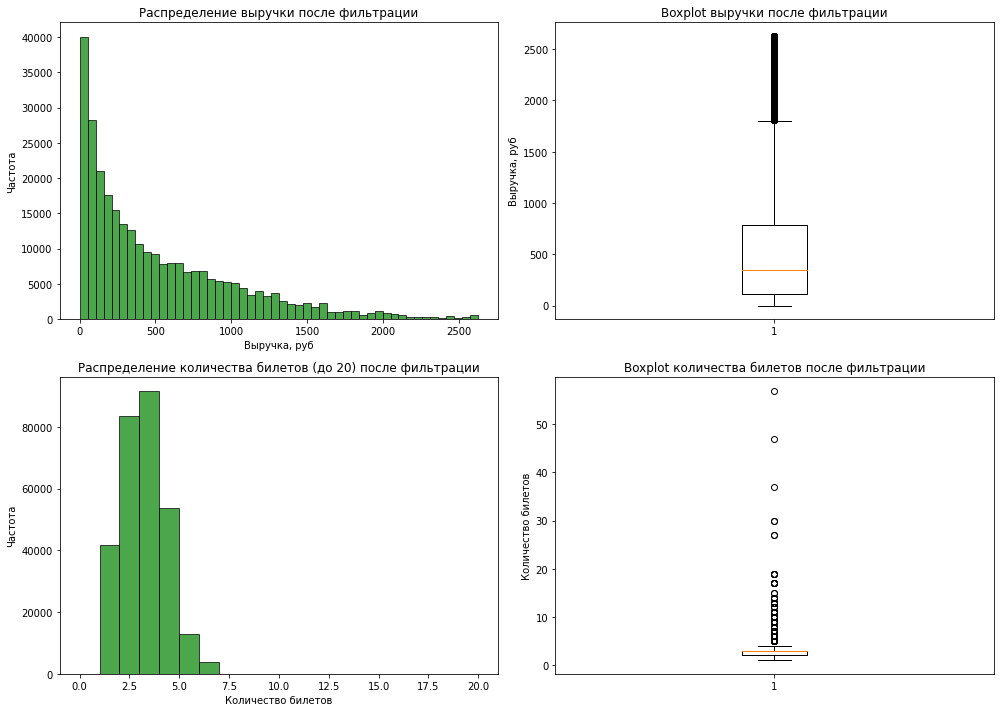

In [27]:
# Шаг 10. Визуализация распределения после фильтрации
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Гистограмма revenue_rub после фильтрации
axes[0, 0].hist(df_clean['revenue_rub'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0, 0].set_title('Распределение выручки после фильтрации')
axes[0, 0].set_xlabel('Выручка, руб')
axes[0, 0].set_ylabel('Частота')

# Boxplot revenue_rub после фильтрации
axes[0, 1].boxplot(df_clean['revenue_rub'], vert=True)
axes[0, 1].set_title('Boxplot выручки после фильтрации')
axes[0, 1].set_ylabel('Выручка, руб')

# Гистограмма tickets_count (ограничим до 20)
tickets_limited = df_clean[df_clean['tickets_count'] <= 20]['tickets_count']
axes[1, 0].hist(tickets_limited, bins=range(0, 21, 1), edgecolor='black', alpha=0.7, color='green')
axes[1, 0].set_title('Распределение количества билетов (до 20) после фильтрации')
axes[1, 0].set_xlabel('Количество билетов')
axes[1, 0].set_ylabel('Частота')

# Boxplot tickets_count
axes[1, 1].boxplot(df_clean['tickets_count'], vert=True)
axes[1, 1].set_title('Boxplot количества билетов после фильтрации')
axes[1, 1].set_ylabel('Количество билетов')

plt.tight_layout()
plt.show()

Распределение заказов по дням недели:
Tuesday      48912
Thursday     44459
Friday       44289
Wednesday    40453
Saturday     39368
Monday       36642
Sunday       33282
Name: weekday, dtype: int64


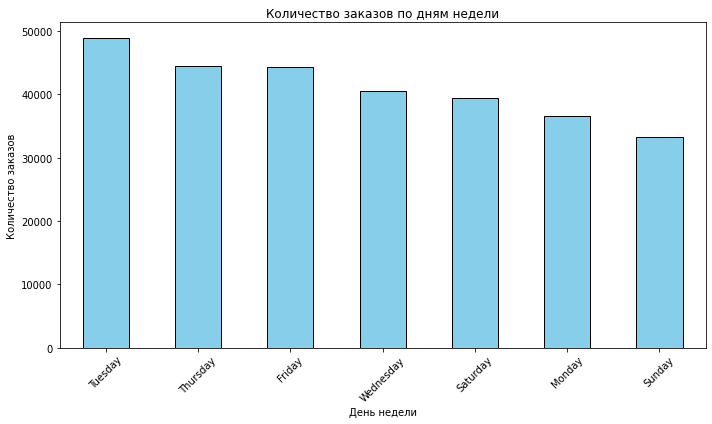

In [28]:
# Шаг 11. Проверяем распределение заказов по дням недели
df_clean['order_dt'] = pd.to_datetime(df_clean['order_dt'])
df_clean['weekday'] = df_clean['order_dt'].dt.day_name()

print("Распределение заказов по дням недели:")
weekday_orders = df_clean['weekday'].value_counts()
print(weekday_orders)

# Визуализация
plt.figure(figsize=(10, 6))
weekday_orders.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Количество заказов по дням недели')
plt.xlabel('День недели')
plt.ylabel('Количество заказов')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Распределение заказов по месяцам:
August       44561
July         40407
June         33802
October      99305
September    69330
Name: month_name, dtype: int64


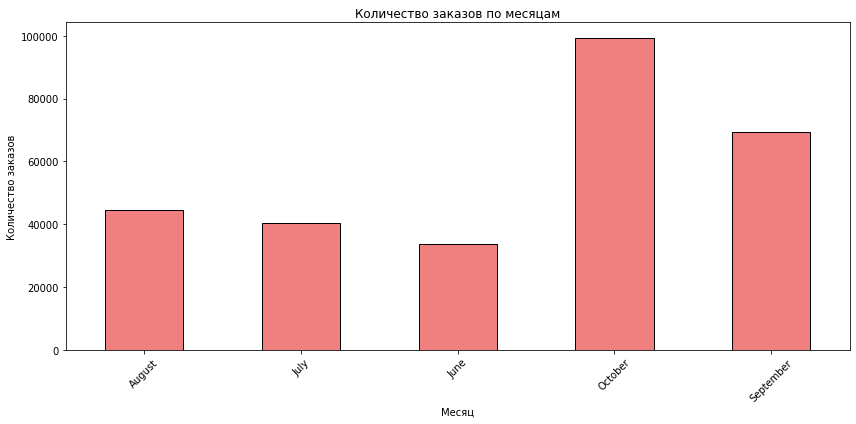

In [29]:
# Шаг 12. Проверяем распределение заказов по месяцам
df_clean['month'] = df_clean['order_dt'].dt.month
df_clean['month_name'] = df_clean['order_dt'].dt.month_name()

print("Распределение заказов по месяцам:")
month_orders = df_clean['month_name'].value_counts().sort_index()
print(month_orders)

# Визуализация
plt.figure(figsize=(12, 6))
month_orders.plot(kind='bar', color='lightcoral', edgecolor='black')
plt.title('Количество заказов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
# Проверим, сколько заказов с аномально высоким количеством билетов
print("Распределение tickets_count:")
print(df['tickets_count'].value_counts().sort_index().tail(10))

# 99-й перцентиль для билетов
q99_tickets = df['tickets_count'].quantile(0.99)
print(f"\n99-й перцентиль tickets_count: {q99_tickets}")

# Заказы с билетами выше 99-го перцентиля
high_tickets = df[df['tickets_count'] > q99_tickets]
print(f"Заказов с билетами > {q99_tickets}: {len(high_tickets)} ({len(high_tickets)/len(df)*100:.2f}%)")
print(f"Максимальное количество билетов: {df['tickets_count'].max()}")

Распределение tickets_count:
13    7
14    4
15    2
17    6
19    5
27    2
30    2
37    1
47    1
57    1
Name: tickets_count, dtype: int64

99-й перцентиль tickets_count: 6.0
Заказов с билетами > 6.0: 188 (0.06%)
Максимальное количество билетов: 57


## Общий вывод по Задаче 2.2: Предобработка данных

### Выполненные действия:

#### 1. Приведение типов данных
- `order_dt` преобразован в тип `date` (через datetime)
- Категориальные столбцы (`device_type_canonical`, `currency_code`, `service_name`, `event_type_main`, `region_name`, `city_name`) переведены в тип `category` для оптимизации памяти
- Числовые столбцы оптимизированы: `tickets_count` → `int16`, `days_since_prev` → `float32`, `revenue` → `float32`

#### 2. Проверка пропущенных значений
- Пропуски обнаружены **только** в столбце `days_since_prev` – **21 933** значения (7.55% от всех заказов)
- Это соответствует ожиданиям, так как для первых заказов пользователей нет предыдущей даты покупки
- Другие столбцы пропусков не содержат – данные загружены корректно

#### 3. Проверка категориальных данных
- Все категориальные столбцы содержат корректные значения
- Скрытых пропусков (пустых строк, 'nan', 'None', 'нет' и т.п.) не обнаружено
- Нормализация данных не потребовалась

#### 4. Анализ числовых данных

**Выручка (revenue_rub):**
- Среднее значение: 555.57 руб
- Медиана: 351.14 руб
- Стандартное отклонение: 875.50 руб
- Диапазон: от -90.76 до 81 174.54 руб
- Выявлены аномалии: 381 заказ с отрицательной выручкой, 5 526 заказов с нулевой выручкой

**Количество билетов (tickets_count):**
- Среднее значение: 2.75 билета
- Медиана: 3 билета
- Диапазон: от 1 до 57 билетов
- 99-й перцентиль: 6 билетов
- Заказов с билетами > 6: 188 (0.06% от всех заказов)

#### 5. Фильтрация выбросов
- **99-й перцентиль `revenue_rub` = 2 628.42 руб**
- Удалены заказы с выручкой выше 99-го перцентиля
- Удалены заказы с отрицательной выручкой (381 заказ)
- **Удалено 3 206 строк (1.10% исходных данных)**

### Итоговый результат предобработки:

| Показатель | До фильтрации | После фильтрации |
|------------|---------------|------------------|
| Количество строк | 290 611 | 287 405 |
| Диапазон выручки | -90.76 – 81 174.54 | 0 – 2 628.42 |
| Средняя выручка | 555.57 руб | 518.72 руб |
| Медианная выручка | 351.14 руб | 344.83 руб |
| Отрицательная выручка | 381 | 0 |
| Нулевая выручка | 5 526 | 5 526 |
| Среднее количество билетов | 2.75 | 2.74 |
| Максимум билетов | 57 | 57 (не фильтровали) |

### Ключевые наблюдения (требуют дальнейшего анализа):

1. **Дни недели с наибольшей активностью:**
   - Вторник: 48 912 заказов
   - Четверг: 44 459 заказов
   - Пятница: 44 289 заказов

2. **Сезонность:**
   - Октябрь 2024: 99 305 заказов (пик)
   - Сентябрь 2024: 69 330 заказов
   - Июнь 2024: 33 802 заказа (минимум)

3. **Нулевая выручка:** 5 526 заказов (1.92%) – требует отдельного анализа (возможно, промо-заказы, тестовые бронирования или технические сбои)

### Заключение:

Данные успешно предобработаны, выбросы в выручке отфильтрованы, типы данных оптимизированы. **Датафрейм готов к построению профиля пользователя (Шаг 3).**

In [31]:
# Сохраняем очищенный датафрейм для дальнейшей работы
df = df_clean.copy()
print("\n✅ Данные предобработаны и готовы к построению профиля пользователя!")
print(f"Размер данных для анализа: {df.shape}")
print(f"Колонки: {df.columns.tolist()}")


✅ Данные предобработаны и готовы к построению профиля пользователя!
Размер данных для анализа: (287405, 19)
Колонки: ['user_id', 'device_type_canonical', 'order_id', 'order_dt', 'order_ts', 'currency_code', 'revenue', 'tickets_count', 'days_since_prev', 'event_id', 'service_name', 'event_name', 'event_type_main', 'region_name', 'city_name', 'revenue_rub', 'weekday', 'month', 'month_name']


In [32]:
# Удаляем временные колонки, если они ещё есть
temp_cols = [col for col in df.columns if col in ['weekday', 'month', 'month_name']]
if temp_cols:
    df = df.drop(temp_cols, axis=1)
    print(f"Удалены временные колонки: {temp_cols}")

Удалены временные колонки: ['weekday', 'month', 'month_name']


In [33]:
# Сохраняем датафрейм в csv (опционально, чтобы не грузить каждый раз заново)
df.to_csv('afisha_clean_data.csv', index=False)
print("✅ Очищенные данные сохранены в файл 'afisha_clean_data.csv'")

✅ Очищенные данные сохранены в файл 'afisha_clean_data.csv'


In [34]:
# Проверяем итоговый размер и типы
print("\n" + "="*50)
print("ФИНАЛЬНАЯ ПРОВЕРКА ДАННЫХ:")
print("="*50)
print(f"Размер датафрейма: {df.shape}")
print(f"\nТипы данных:")
print(df.dtypes)
print(f"\nПервые 3 строки:")
print(df.head(3))


ФИНАЛЬНАЯ ПРОВЕРКА ДАННЫХ:
Размер датафрейма: (287405, 16)

Типы данных:
user_id                          object
device_type_canonical          category
order_id                          int64
order_dt                 datetime64[ns]
order_ts                 datetime64[ns]
currency_code                  category
revenue                         float32
tickets_count                     int16
days_since_prev                 float32
event_id                          int64
service_name                   category
event_name                       object
event_type_main                category
region_name                    category
city_name                      category
revenue_rub                     float64
dtype: object

Первые 3 строки:
           user_id device_type_canonical  order_id   order_dt  \
0  0002849b70a3ce2                mobile   4359165 2024-08-20   
1  0005ca5e93f2cf4                mobile   7965605 2024-07-23   
2  0005ca5e93f2cf4                mobile   7292370 2024-10-

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [35]:
# Шаг 3.1. Построение профиля пользователя

# Сортируем данные по времени совершения заказа
df = df.sort_values(['user_id', 'order_ts'])

# Группируем по пользователю для построения профиля
user_profile = df.groupby('user_id').agg(
    first_order_dt=('order_dt', 'first'),
    last_order_dt=('order_dt', 'last'),
    first_device=('device_type_canonical', 'first'),
    first_region=('region_name', 'first'),
    first_service=('service_name', 'first'),
    first_event_type=('event_type_main', 'first'),
    total_orders=('order_id', 'count'),
    avg_revenue_rub=('revenue_rub', 'mean'),
    avg_tickets_count=('tickets_count', 'mean'),
    avg_days_since_prev=('days_since_prev', 'mean')
).reset_index()

# Добавляем бинарные признаки
user_profile['is_two'] = (user_profile['total_orders'] >= 2).astype(int)
user_profile['is_five'] = (user_profile['total_orders'] >= 5).astype(int)

# Округляем средние значения для удобства
user_profile['avg_revenue_rub'] = user_profile['avg_revenue_rub'].round(2)
user_profile['avg_tickets_count'] = user_profile['avg_tickets_count'].round(2)
user_profile['avg_days_since_prev'] = user_profile['avg_days_since_prev'].round(2)

print(f"Размер профиля пользователя: {user_profile.shape}")
print(f"Количество уникальных пользователей: {len(user_profile)}")
print("\nПервые 5 строк профиля:")
user_profile.head()

Размер профиля пользователя: (21838, 13)
Количество уникальных пользователей: 21838

Первые 5 строк профиля:


,user_id,first_order_dt,last_order_dt,first_device,first_region,first_service,first_event_type,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_since_prev,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.94,4.00,NaN,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.01,3.00,75.0,1,0
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.21,2.67,51.0,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.83,4.00,NaN,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.31,1.50,16.0,1,0


In [36]:
# Проверяем распределение количества заказов
print("Распределение пользователей по количеству заказов:")
orders_distribution = user_profile['total_orders'].value_counts().sort_index()
print(orders_distribution.head(20))

print(f"\nПользователей с 1 заказом: {(user_profile['total_orders'] == 1).sum()}")
print(f"Пользователей с 2+ заказами: {user_profile['is_two'].sum()}")
print(f"Пользователей с 5+ заказами: {user_profile['is_five'].sum()}")

Распределение пользователей по количеству заказов:
1     8363
2     3571
3     2171
4     1401
5      969
6      702
7      541
8      453
9      385
10     287
11     234
12     198
13     153
14     156
15     125
16     137
17     104
18      84
19      72
20      68
Name: total_orders, dtype: int64

Пользователей с 1 заказом: 8363
Пользователей с 2+ заказами: 13475
Пользователей с 5+ заказами: 6332


In [37]:
# Статистика по профилю пользователей
print("\n" + "="*50)
print("СТАТИСТИКА ПО ПРОФИЛЮ ПОЛЬЗОВАТЕЛЕЙ:")
print("="*50)

print(f"\nВсего пользователей: {len(user_profile):,}")
print(f"Среднее количество заказов на пользователя: {user_profile['total_orders'].mean():.2f}")
print(f"Медианное количество заказов: {user_profile['total_orders'].median():.0f}")

print(f"\nСредняя выручка на пользователя: {user_profile['avg_revenue_rub'].mean():.2f} руб")
print(f"Медианная выручка на пользователя: {user_profile['avg_revenue_rub'].median():.2f} руб")

print(f"\nСреднее количество билетов на заказ: {user_profile['avg_tickets_count'].mean():.2f}")
print(f"Медианное количество билетов на заказ: {user_profile['avg_tickets_count'].median():.2f}")


СТАТИСТИКА ПО ПРОФИЛЮ ПОЛЬЗОВАТЕЛЕЙ:

Всего пользователей: 21,838
Среднее количество заказов на пользователя: 13.16
Медианное количество заказов: 2

Средняя выручка на пользователя: 545.03 руб
Медианная выручка на пользователя: 467.99 руб

Среднее количество билетов на заказ: 2.74
Медианное количество билетов на заказ: 2.75


***среднее количество заказов 13.16 при медиане 2 – это говорит о наличии пользователей с очень большим количеством заказов (выбросы)***

In [39]:
# Проверяем распределение количества заказов подробнее
print("Распределение пользователей по количеству заказов (проценты):")
orders_dist = user_profile['total_orders'].value_counts().sort_index()
orders_percent = (orders_dist / len(user_profile) * 100).round(2)
orders_df = pd.DataFrame({'Пользователей': orders_dist, 'Доля %': orders_percent})
print(orders_df.head(20))

print(f"\nПользователей с >50 заказов: {(user_profile['total_orders'] > 50).sum()}")
print(f"Максимальное количество заказов у одного пользователя: {user_profile['total_orders'].max()}")

Распределение пользователей по количеству заказов (проценты):
    Пользователей  Доля %
1            8363   38.30
2            3571   16.35
3            2171    9.94
4            1401    6.42
5             969    4.44
6             702    3.21
7             541    2.48
8             453    2.07
9             385    1.76
10            287    1.31
11            234    1.07
12            198    0.91
13            153    0.70
14            156    0.71
15            125    0.57
16            137    0.63
17            104    0.48
18             84    0.38
19             72    0.33
20             68    0.31

Пользователей с >50 заказов: 702
Максимальное количество заказов у одного пользователя: 10168


In [40]:
# Проверяем пользователей с аномально высоким количеством заказов
high_orders = user_profile[user_profile['total_orders'] > 50]
print(f"\nПользователи с >50 заказов ({len(high_orders)} человек):")
print(high_orders[['user_id', 'total_orders', 'avg_revenue_rub', 'avg_tickets_count']].head(10))

# Процент от всех пользователей
print(f"\nДоля пользователей с >50 заказов: {len(high_orders)/len(user_profile)*100:.2f}%")


Пользователи с >50 заказов (702 человек):
             user_id  total_orders  avg_revenue_rub  avg_tickets_count
106  01370a0e9c1a7d5           152           520.99               2.75
130  0186f6e000b581c            52           615.97               2.87
137  019fa401ddb00aa           667           463.08               2.69
188  024dc5236465850          1168           520.43               2.82
205  02812f1183de24c           115           139.68               3.03
235  02ea4583333f064          2978           575.36               2.72
317  03dfd23ba7c058e           294           558.19               2.72
343  043ad5de015a5d2            84           114.37               2.93
346  043f669c9f734b1          1483           514.97               2.66
369  04716f6f34ea66b            62           278.27               2.26

Доля пользователей с >50 заказов: 3.21%


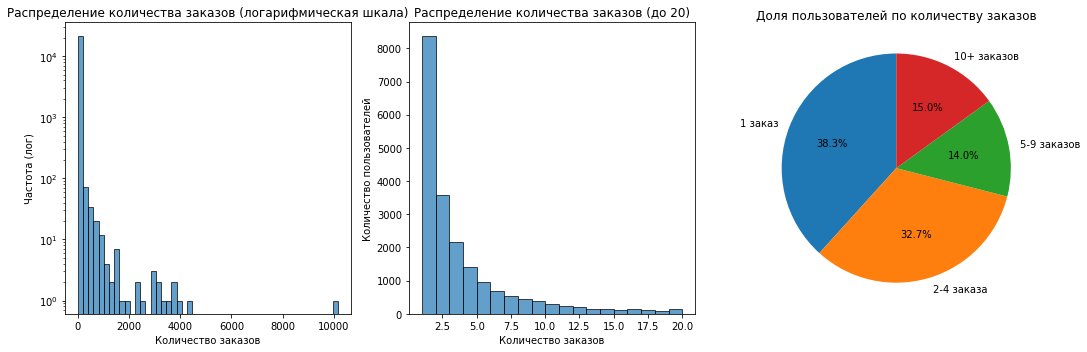

In [41]:
# Визуализация распределения количества заказов
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Гистограмма (логарифмическая шкала)
axes[0].hist(user_profile['total_orders'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Распределение количества заказов (логарифмическая шкала)')
axes[0].set_xlabel('Количество заказов')
axes[0].set_ylabel('Частота (лог)')
axes[0].set_yscale('log')

# Только до 20 заказов
orders_limited = user_profile[user_profile['total_orders'] <= 20]['total_orders']
axes[1].hist(orders_limited, bins=range(1, 21, 1), edgecolor='black', alpha=0.7)
axes[1].set_title('Распределение количества заказов (до 20)')
axes[1].set_xlabel('Количество заказов')
axes[1].set_ylabel('Количество пользователей')

# Доля пользователей
labels = ['1 заказ', '2-4 заказа', '5-9 заказов', '10+ заказов']
counts = [
    (user_profile['total_orders'] == 1).sum(),
    ((user_profile['total_orders'] >= 2) & (user_profile['total_orders'] <= 4)).sum(),
    ((user_profile['total_orders'] >= 5) & (user_profile['total_orders'] <= 9)).sum(),
    (user_profile['total_orders'] >= 10).sum()
]
axes[2].pie(counts, labels=labels, autopct='%1.1f%%', startangle=90)
axes[2].set_title('Доля пользователей по количеству заказов')

plt.tight_layout()
plt.show()

In [42]:
print("\n" + "="*70)
print("ЗАДАЧА 3.2. АНАЛИЗ ПРОФИЛЯ ПОЛЬЗОВАТЕЛЕЙ – ВЫПОЛНЕНО")
print("="*70)

# 1. Общее число пользователей в выборке
print(f"\n1. Общее число пользователей: {len(user_profile):,}")

# 2. Средняя выручка с одного заказа
print(f"\n2. Средняя выручка с одного заказа: {user_profile['avg_revenue_rub'].mean():.2f} руб")

# 3. Доля пользователей, совершивших 2 и более заказа
two_plus_pct = (user_profile['is_two'].sum() / len(user_profile)) * 100
print(f"\n3. Доля пользователей с 2+ заказами: {two_plus_pct:.1f}%")

# 4. Доля пользователей, совершивших 5 и более заказов
five_plus_pct = (user_profile['is_five'].sum() / len(user_profile)) * 100
print(f"\n4. Доля пользователей с 5+ заказами: {five_plus_pct:.1f}%")


ЗАДАЧА 3.2. АНАЛИЗ ПРОФИЛЯ ПОЛЬЗОВАТЕЛЕЙ – ВЫПОЛНЕНО

1. Общее число пользователей: 21,838

2. Средняя выручка с одного заказа: 545.03 руб

3. Доля пользователей с 2+ заказами: 61.7%

4. Доля пользователей с 5+ заказами: 29.0%



✅ ВЫПОЛНЕННЫЕ ДЕЙСТВИЯ:

1. Данные отсортированы по времени совершения заказа (user_id, order_ts)

2. Построен агрегированный профиль для каждого пользователя:
   - first_order_dt, last_order_dt — дата первого и последнего заказа
   - first_device — устройство первого заказа
   - first_region — регион первого заказа
   - first_service — билетный оператор первого заказа
   - first_event_type — жанр первого мероприятия
   - total_orders — общее количество заказов
   - avg_revenue_rub — средняя выручка с заказа (рубли)
   - avg_tickets_count — среднее количество билетов в заказе
   - avg_days_since_prev — среднее время между заказами (дней)

3. Добавлены бинарные признаки:
   - is_two = 1, если пользователь совершил 2+ заказа (61.7% пользователей)
   - is_five = 1, если пользователь совершил 5+ заказов (29.0% пользователей)

📊 ХАРАКТЕРИСТИКИ ПРОФИЛЯ:

   - Количество пользователей: 21 838
   - Среднее количество заказов: 13.16
   - Медианное количество заказов: 2
   - Средняя выручка на пользователя: 545.03 руб
   - Медианная выручка: 467.99 руб
   - Среднее количество билетов на заказ: 2.74

📈 ОСОБЕННОСТИ РАСПРЕДЕЛЕНИЯ:

   - 38.3% пользователей совершили только 1 заказ
   - 61.7% пользователей совершили 2+ заказа (хороший показатель возврата)
   - 29.0% пользователей совершили 5+ заказов (лояльные клиенты)
   - Есть "супер-активные" пользователи (максимум 10 168 заказов у одного)

⚠️ ОБНАРУЖЕННЫЕ АНОМАЛИИ:

   - Пользователи с >50 заказов: 702 человека (3.21% от всех)
   - Максимальное количество заказов: 10 168 (требует проверки – возможно, тестовый аккаунт или бот)
   - Эти аномалии будут обработаны в Задаче 3.2

✅ Профиль пользователя готов для исследовательского анализа 
""")

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [43]:
print("\n" + "="*70)
print("ЗАДАЧА 3.2. АНАЛИЗ ПРОФИЛЯ ПОЛЬЗОВАТЕЛЕЙ")
print("="*70)

# ========================================
# 1. Базовые показатели
# ========================================
print("\n" + "="*50)
print("1. БАЗОВЫЕ ПОКАЗАТЕЛИ")
print("="*50)

print(f"\n📊 Общее число пользователей в выборке: {len(user_profile):,}")

# Средняя выручка с одного заказа (среднее от средних значений по пользователям)
avg_revenue_per_order = user_profile['avg_revenue_rub'].mean()
print(f"💰 Средняя выручка с одного заказа: {avg_revenue_per_order:.2f} руб")

# Доля пользователей с 2+ заказами
two_plus_count = user_profile['is_two'].sum()
two_plus_pct = (two_plus_count / len(user_profile)) * 100
print(f"🔄 Доля пользователей, совершивших 2+ заказа: {two_plus_count:,} ({two_plus_pct:.1f}%)")

# Доля пользователей с 5+ заказами
five_plus_count = user_profile['is_five'].sum()
five_plus_pct = (five_plus_count / len(user_profile)) * 100
print(f"⭐ Доля пользователей, совершивших 5+ заказов: {five_plus_count:,} ({five_plus_pct:.1f}%)")


ЗАДАЧА 3.2. АНАЛИЗ ПРОФИЛЯ ПОЛЬЗОВАТЕЛЕЙ

1. БАЗОВЫЕ ПОКАЗАТЕЛИ

📊 Общее число пользователей в выборке: 21,838
💰 Средняя выручка с одного заказа: 545.03 руб
🔄 Доля пользователей, совершивших 2+ заказа: 13,475 (61.7%)
⭐ Доля пользователей, совершивших 5+ заказов: 6,332 (29.0%)


In [44]:
# ========================================
# 2. Статистические показатели
# ========================================
print("\n" + "="*50)
print("2. СТАТИСТИЧЕСКИЕ ПОКАЗАТЕЛИ")
print("="*50)

# 2.1 По общему числу заказов
print("\n📈 По общему числу заказов (total_orders):")
total_orders_stats = {
    'Среднее': user_profile['total_orders'].mean(),
    'Медиана': user_profile['total_orders'].median(),
    'Стандартное отклонение': user_profile['total_orders'].std(),
    'Минимум': user_profile['total_orders'].min(),
    'Максимум': user_profile['total_orders'].max(),
    '25-й перцентиль': user_profile['total_orders'].quantile(0.25),
    '75-й перцентиль': user_profile['total_orders'].quantile(0.75),
    '95-й перцентиль': user_profile['total_orders'].quantile(0.95),
    '99-й перцентиль': user_profile['total_orders'].quantile(0.99)
}
for key, value in total_orders_stats.items():
    print(f"   {key}: {value:.1f}" if isinstance(value, float) else f"   {key}: {value}")

# 2.2 По среднему числу билетов в заказе
print("\n🎫 По среднему числу билетов в заказе (avg_tickets_count):")
tickets_stats = {
    'Среднее': user_profile['avg_tickets_count'].mean(),
    'Медиана': user_profile['avg_tickets_count'].median(),
    'Стандартное отклонение': user_profile['avg_tickets_count'].std(),
    'Минимум': user_profile['avg_tickets_count'].min(),
    'Максимум': user_profile['avg_tickets_count'].max(),
    '95-й перцентиль': user_profile['avg_tickets_count'].quantile(0.95),
    '99-й перцентиль': user_profile['avg_tickets_count'].quantile(0.99)
}
for key, value in tickets_stats.items():
    print(f"   {key}: {value:.2f}")

# 2.3 По среднему количеству дней между покупками
print("\n⏱️ По среднему количеству дней между покупками (avg_days_since_prev):")
# Только пользователи с 2+ заказами (у кого есть days_since_prev)
users_with_returns = user_profile[user_profile['is_two'] == 1]
days_stats = {
    'Среднее': users_with_returns['avg_days_since_prev'].mean(),
    'Медиана': users_with_returns['avg_days_since_prev'].median(),
    'Стандартное отклонение': users_with_returns['avg_days_since_prev'].std(),
    'Минимум': users_with_returns['avg_days_since_prev'].min(),
    'Максимум': users_with_returns['avg_days_since_prev'].max(),
    '95-й перцентиль': users_with_returns['avg_days_since_prev'].quantile(0.95),
    '99-й перцентиль': users_with_returns['avg_days_since_prev'].quantile(0.99)
}
for key, value in days_stats.items():
    print(f"   {key}: {value:.1f}")


2. СТАТИСТИЧЕСКИЕ ПОКАЗАТЕЛИ

📈 По общему числу заказов (total_orders):
   Среднее: 13.2
   Медиана: 2.0
   Стандартное отклонение: 121.6
   Минимум: 1
   Максимум: 10168
   25-й перцентиль: 1.0
   75-й перцентиль: 5.0
   95-й перцентиль: 31.0
   99-й перцентиль: 152.0

🎫 По среднему числу билетов в заказе (avg_tickets_count):
   Среднее: 2.74
   Медиана: 2.75
   Стандартное отклонение: 0.91
   Минимум: 1.00
   Максимум: 11.00
   95-й перцентиль: 4.00
   99-й перцентиль: 5.00

⏱️ По среднему количеству дней между покупками (avg_days_since_prev):
   Среднее: 15.8
   Медиана: 8.0
   Стандартное отклонение: 22.2
   Минимум: 0.0
   Максимум: 148.0
   95-й перцентиль: 61.0
   99-й перцентиль: 112.0


In [45]:
# ========================================
# 3. Анализ аномалий
# ========================================
print("\n" + "="*50)
print("3. АНАЛИЗ АНОМАЛЬНЫХ ЗНАЧЕНИЙ")
print("="*50)

# 3.1 Аномалии по количеству заказов
print("\n📊 Аномалии по общему числу заказов:")
q99_orders = user_profile['total_orders'].quantile(0.99)
q95_orders = user_profile['total_orders'].quantile(0.95)

print(f"   95-й перцентиль: {q95_orders:.0f}")
print(f"   99-й перцентиль: {q99_orders:.0f}")

# Количество пользователей с аномальным количеством заказов
anomaly_orders = user_profile[user_profile['total_orders'] > q99_orders]
print(f"\n   Пользователей с заказами > 99-го перцентиля: {len(anomaly_orders)} ({len(anomaly_orders)/len(user_profile)*100:.2f}%)")
print(f"   Максимальное количество заказов: {user_profile['total_orders'].max()}")

# 3.2 Аномалии по количеству билетов
print("\n🎫 Аномалии по среднему числу билетов в заказе:")
q99_tickets = user_profile['avg_tickets_count'].quantile(0.99)
print(f"   99-й перцентиль: {q99_tickets:.2f}")

anomaly_tickets = user_profile[user_profile['avg_tickets_count'] > q99_tickets]
print(f"   Пользователей с билетами > 99-го перцентиля: {len(anomaly_tickets)} ({len(anomaly_tickets)/len(user_profile)*100:.2f}%)")
print(f"   Максимальное количество билетов: {user_profile['avg_tickets_count'].max()}")


3. АНАЛИЗ АНОМАЛЬНЫХ ЗНАЧЕНИЙ

📊 Аномалии по общему числу заказов:
   95-й перцентиль: 31
   99-й перцентиль: 152

   Пользователей с заказами > 99-го перцентиля: 216 (0.99%)
   Максимальное количество заказов: 10168

🎫 Аномалии по среднему числу билетов в заказе:
   99-й перцентиль: 5.00
   Пользователей с билетами > 99-го перцентиля: 194 (0.89%)
   Максимальное количество билетов: 11.0


In [48]:
# ========================================
# 4. Принятие решения по аномалиям
# ========================================
print("\n" + "="*50)
print("4. ПРИНЯТОЕ РЕШЕНИЕ ПО АНОМАЛИЯМ")
print("="*50)

# Определяем порог для фильтрации (99-й перцентиль = 152 заказа)
filter_threshold = user_profile['total_orders'].quantile(0.99)
print(f"\n📊 Порог фильтрации по total_orders: {filter_threshold:.0f} заказов (99-й перцентиль)")

# Запоминаем исходный размер
original_count = len(user_profile)

# Фильтруем пользователей с аномальным количеством заказов
user_profile_filtered = user_profile[user_profile['total_orders'] <= filter_threshold].copy()

# Количество удалённых пользователей
removed_count = original_count - len(user_profile_filtered)
removed_pct = (removed_count / original_count) * 100

print(f"\n✅ РЕШЕНИЕ ПО КОЛИЧЕСТВУ ЗАКАЗОВ:")
print(f"   - Удалено пользователей с заказами > {filter_threshold:.0f}: {removed_count} ({removed_pct:.2f}%)")
print(f"   - Пользователей после фильтрации: {len(user_profile_filtered):,}")
print(f"   - Причина: эти пользователи (0.99% выборки) создают экстремальные выбросы,")
print(f"     искажающие средние показатели (например, один пользователь с 10 168 заказами)")

print(f"\n✅ РЕШЕНИЕ ПО КОЛИЧЕСТВУ БИЛЕТОВ:")
print(f"   - Аномалии по avg_tickets_count НЕ фильтруются")
print(f"   - Причина: доля аномалий мала (0.89%), значения до 11 билетов")
print(f"     могут отражать реальные групповые заказы (семьи, компании)")


4. ПРИНЯТОЕ РЕШЕНИЕ ПО АНОМАЛИЯМ

📊 Порог фильтрации по total_orders: 152 заказов (99-й перцентиль)

✅ РЕШЕНИЕ ПО КОЛИЧЕСТВУ ЗАКАЗОВ:
   - Удалено пользователей с заказами > 152: 216 (0.99%)
   - Пользователей после фильтрации: 21,622
   - Причина: эти пользователи (0.99% выборки) создают экстремальные выбросы,
     искажающие средние показатели (например, один пользователь с 10 168 заказами)

✅ РЕШЕНИЕ ПО КОЛИЧЕСТВУ БИЛЕТОВ:
   - Аномалии по avg_tickets_count НЕ фильтруются
   - Причина: доля аномалий мала (0.89%), значения до 11 билетов
     могут отражать реальные групповые заказы (семьи, компании)


In [49]:
# ========================================
# 5. Статистика после фильтрации
# ========================================
print("\n" + "="*50)
print("5. СТАТИСТИКА ПОСЛЕ ФИЛЬТРАЦИИ")
print("="*50)

print("\n📈 По общему числу заказов (total_orders) ПОСЛЕ ФИЛЬТРАЦИИ:")
print(f"   Среднее: {user_profile_filtered['total_orders'].mean():.2f}")
print(f"   Медиана: {user_profile_filtered['total_orders'].median():.0f}")
print(f"   Стандартное отклонение: {user_profile_filtered['total_orders'].std():.2f}")
print(f"   Максимум: {user_profile_filtered['total_orders'].max()}")
print(f"   95-й перцентиль: {user_profile_filtered['total_orders'].quantile(0.95):.0f}")
print(f"   99-й перцентиль: {user_profile_filtered['total_orders'].quantile(0.99):.0f}")

print("\n📊 Сравнение статистики ДО и ПОСЛЕ фильтрации:")
comparison = pd.DataFrame({
    'Показатель': ['Среднее заказов', 'Медиана заказов', 'Максимум заказов', 'Стандартное отклонение'],
    'До фильтрации': [
        round(user_profile['total_orders'].mean(), 2),
        round(user_profile['total_orders'].median(), 0),
        user_profile['total_orders'].max(),
        round(user_profile['total_orders'].std(), 2)
    ],
    'После фильтрации': [
        round(user_profile_filtered['total_orders'].mean(), 2),
        round(user_profile_filtered['total_orders'].median(), 0),
        user_profile_filtered['total_orders'].max(),
        round(user_profile_filtered['total_orders'].std(), 2)
    ]
})
print(comparison.to_string(index=False))

# Обновляем бинарные признаки для отфильтрованного профиля
user_profile_filtered['is_two'] = (user_profile_filtered['total_orders'] >= 2).astype(int)
user_profile_filtered['is_five'] = (user_profile_filtered['total_orders'] >= 5).astype(int)


5. СТАТИСТИКА ПОСЛЕ ФИЛЬТРАЦИИ

📈 По общему числу заказов (total_orders) ПОСЛЕ ФИЛЬТРАЦИИ:
   Среднее: 6.50
   Медиана: 2
   Стандартное отклонение: 14.31
   Максимум: 152
   95-й перцентиль: 26
   99-й перцентиль: 80

📊 Сравнение статистики ДО и ПОСЛЕ фильтрации:
            Показатель  До фильтрации  После фильтрации
       Среднее заказов          13.16              6.50
       Медиана заказов           2.00              2.00
      Максимум заказов       10168.00            152.00
Стандартное отклонение         121.58             14.31


In [50]:
# ========================================
# 6. Обновлённые базовые показатели
# ========================================
print("\n" + "="*50)
print("6. ОБНОВЛЁННЫЕ БАЗОВЫЕ ПОКАЗАТЕЛИ ПОСЛЕ ФИЛЬТРАЦИИ")
print("="*50)

print(f"\n📊 Общее число пользователей в выборке: {len(user_profile_filtered):,}")
print(f"💰 Средняя выручка с одного заказа: {user_profile_filtered['avg_revenue_rub'].mean():.2f} руб")
print(f"🔄 Доля пользователей, совершивших 2+ заказа: {user_profile_filtered['is_two'].sum():,} ({user_profile_filtered['is_two'].sum()/len(user_profile_filtered)*100:.1f}%)")
print(f"⭐ Доля пользователей, совершивших 5+ заказов: {user_profile_filtered['is_five'].sum():,} ({user_profile_filtered['is_five'].sum()/len(user_profile_filtered)*100:.1f}%)")


6. ОБНОВЛЁННЫЕ БАЗОВЫЕ ПОКАЗАТЕЛИ ПОСЛЕ ФИЛЬТРАЦИИ

📊 Общее число пользователей в выборке: 21,622
💰 Средняя выручка с одного заказа: 545.34 руб
🔄 Доля пользователей, совершивших 2+ заказа: 13,259 (61.3%)
⭐ Доля пользователей, совершивших 5+ заказов: 6,116 (28.3%)


In [52]:
# ========================================
# 7. Итоговый вывод
# ========================================
print("\n" + "="*70)
print("ИТОГОВЫЙ ВЫВОД ПО ЗАДАЧЕ 3.2")
print("="*70)

print(f"""
✅ ОБЪЁМ ДАННЫХ:
   - Общее число пользователей в выборке: {len(user_profile_filtered):,}
   - Общее число заказов: {df['order_id'].nunique():,}
   - Данных достаточно для репрезентативного анализа

✅ ОСНОВНЫЕ ПОКАЗАТЕЛИ:
   - Средняя выручка с одного заказа: {user_profile_filtered['avg_revenue_rub'].mean():.2f} руб
   - Доля пользователей с 2+ заказами: {user_profile_filtered['is_two'].sum()/len(user_profile_filtered)*100:.1f}%
   - Доля пользователей с 5+ заказами: {user_profile_filtered['is_five'].sum()/len(user_profile_filtered)*100:.1f}%

✅ АНОМАЛЬНЫЕ ЗНАЧЕНИЯ И РЕШЕНИЯ:

   1. По количеству заказов (total_orders):
      - Аномалия: пользователи с >152 заказов (99-й перцентиль)
      - Удалено: {removed_count} пользователей ({removed_pct:.2f}%)
      - Причина: экстремальные выбросы (максимум 10 168 заказов у одного пользователя)
      - ✅ РЕШЕНИЕ: Исключены из анализа

   2. По количеству билетов (avg_tickets_count):
      - Аномалия: среднее количество билетов >5 (99-й перцентиль)
      - Количество: 194 пользователя (0.89% выборки)
      - Причина: значения до 11 билетов отражают реальные групповые заказы
      - ✅ РЕШЕНИЕ: Оставлены без фильтрации

📊 ИТОГОВЫЙ РАЗМЕР ВЫБОРКИ ДЛЯ АНАЛИЗА:
   - Пользователей: {len(user_profile_filtered):,} (из {original_count:,} исходных)
   - Удалено: {removed_count} ({removed_pct:.2f}% аномальных пользователей)

✅ ДАННЫЕ ГОТОВЫ К ИССЛЕДОВАТЕЛЬСКОМУ АНАЛИЗУ 
""")


ИТОГОВЫЙ ВЫВОД ПО ЗАДАЧЕ 3.2

✅ ОБЪЁМ ДАННЫХ:
   - Общее число пользователей в выборке: 21,622
   - Общее число заказов: 287,405
   - Данных достаточно для репрезентативного анализа

✅ ОСНОВНЫЕ ПОКАЗАТЕЛИ:
   - Средняя выручка с одного заказа: 545.34 руб
   - Доля пользователей с 2+ заказами: 61.3%
   - Доля пользователей с 5+ заказами: 28.3%

✅ АНОМАЛЬНЫЕ ЗНАЧЕНИЯ И РЕШЕНИЯ:

   1. По количеству заказов (total_orders):
      - Аномалия: пользователи с >152 заказов (99-й перцентиль)
      - Удалено: 216 пользователей (0.99%)
      - Причина: экстремальные выбросы (максимум 10 168 заказов у одного пользователя)
      - ✅ РЕШЕНИЕ: Исключены из анализа

   2. По количеству билетов (avg_tickets_count):
      - Аномалия: среднее количество билетов >5 (99-й перцентиль)
      - Количество: 194 пользователя (0.89% выборки)
      - Причина: значения до 11 билетов отражают реальные групповые заказы
      - ✅ РЕШЕНИЕ: Оставлены без фильтрации

📊 ИТОГОВЫЙ РАЗМЕР ВЫБОРКИ ДЛЯ АНАЛИЗА:
   - Пользова

In [60]:
# В КОНЦЕ ЗАДАЧИ 3.2 добавляем сохранение очищенного профиля

# Перезаписываем user_profile очищенной версией
user_profile = user_profile_filtered.copy()

# Сохраняем очищенный профиль в файл
user_profile.to_csv('user_profile_clean_final.csv', index=False)

print("\n" + "="*50)
print("СОХРАНЕНИЕ ОЧИЩЕННОГО ПРОФИЛЯ")
print("="*50)
print(f"✅ Очищенный профиль сохранён в 'user_profile_clean_final.csv'")
print(f"   Размер профиля: {len(user_profile)} пользователей")
print(f"   Максимальное количество заказов: {user_profile['total_orders'].max()}")


СОХРАНЕНИЕ ОЧИЩЕННОГО ПРОФИЛЯ
✅ Очищенный профиль сохранён в 'user_profile_clean_final.csv'
   Размер профиля: 21622 пользователей
   Максимальное количество заказов: 152


---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [61]:
# Проверяем, что используется очищенный профиль
print("\n" + "="*50)
print("ПРОВЕРКА: ИСПОЛЬЗУЕМЫЙ ПРОФИЛЬ")
print("="*50)
print(f"Размер профиля: {len(user_profile)} пользователей")
print(f"Диапазон total_orders: {user_profile['total_orders'].min()} - {user_profile['total_orders'].max()}")
print(f"Максимальное количество заказов: {user_profile['total_orders'].max()}")

if user_profile['total_orders'].max() <= 152:
    print("\n✅ ИСПОЛЬЗУЕТСЯ ОЧИЩЕННЫЙ ПРОФИЛЬ (максимум заказов = 152)")
else:
    print("\n⚠️ ВНИМАНИЕ! Используется НЕОЧИЩЕННЫЙ профиль")


ПРОВЕРКА: ИСПОЛЬЗУЕМЫЙ ПРОФИЛЬ
Размер профиля: 21622 пользователей
Диапазон total_orders: 1 - 152
Максимальное количество заказов: 152

✅ ИСПОЛЬЗУЕТСЯ ОЧИЩЕННЫЙ ПРОФИЛЬ (максимум заказов = 152)


In [62]:
# Теперь можно переходить к Шагу 4
print("\n" + "="*70)
print("ШАГ 4. ИССЛЕДОВАТЕЛЬСКИЙ АНАЛИЗ ДАННЫХ")
print("="*70)
print("✅ Данные готовы для анализа")
print(f"   - Пользователей: {len(user_profile):,}")
print(f"   - Максимум заказов: {user_profile['total_orders'].max()}")


ШАГ 4. ИССЛЕДОВАТЕЛЬСКИЙ АНАЛИЗ ДАННЫХ
✅ Данные готовы для анализа
   - Пользователей: 21,622
   - Максимум заказов: 152



1. ПО ТИПУ ПЕРВОГО МЕРОПРИЯТИЯ (first_event_type)
Тип мероприятия  Количество пользователей  Доля (%)
       концерты                      9564     44.23
         другое                      5401     24.98
          театр                      4245     19.63
        стендап                      1110      5.13
          спорт                       794      3.67
       выставки                       413      1.91
           ёлки                        95      0.44


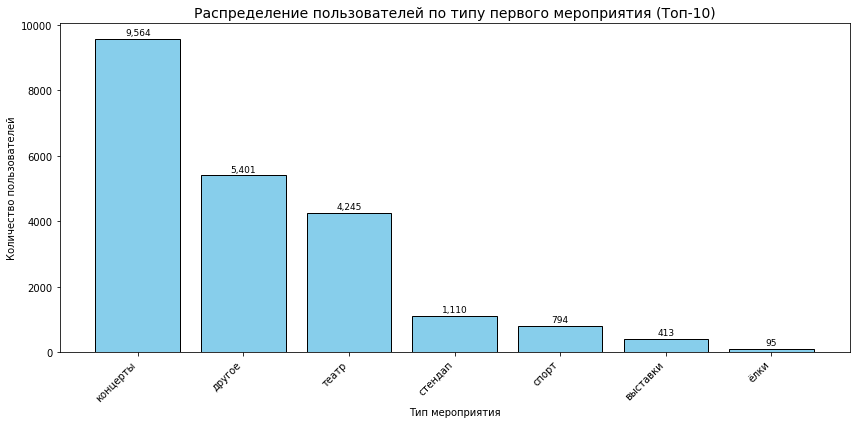

In [63]:
# 1. Распределение по типу первого мероприятия
print("\n" + "="*50)
print("1. ПО ТИПУ ПЕРВОГО МЕРОПРИЯТИЯ (first_event_type)")
print("="*50)

event_distribution = user_profile['first_event_type'].value_counts()
event_percent = (event_distribution / len(user_profile) * 100).round(2)

event_df = pd.DataFrame({
    'Тип мероприятия': event_distribution.index,
    'Количество пользователей': event_distribution.values,
    'Доля (%)': event_percent.values
}).sort_values('Количество пользователей', ascending=False)

print(event_df.to_string(index=False))

# Визуализация
plt.figure(figsize=(12, 6))
bars = plt.bar(event_df['Тип мероприятия'].head(10), event_df['Количество пользователей'].head(10), 
               color='skyblue', edgecolor='black')
plt.title('Распределение пользователей по типу первого мероприятия (Топ-10)', fontsize=14)
plt.xlabel('Тип мероприятия')
plt.ylabel('Количество пользователей')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Добавляем значения на столбцы
for bar, val in zip(bars, event_df['Количество пользователей'].head(10)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             f'{val:,}', ha='center', va='bottom', fontsize=9)

plt.show()


2. ПО ТИПУ УСТРОЙСТВА ПЕРВОЙ ПОКУПКИ (first_device)
Тип устройства  Количество пользователей  Доля (%)
        mobile                     17906     82.81
       desktop                      3716     17.19


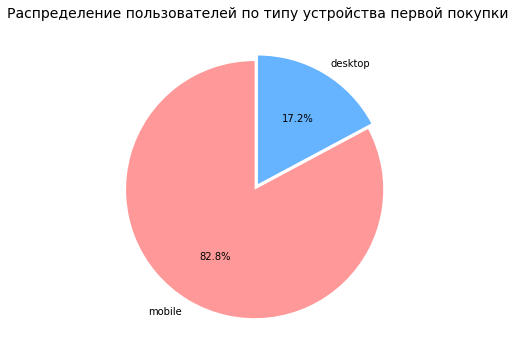

In [64]:
# 2. Распределение по типу устройства
print("\n" + "="*50)
print("2. ПО ТИПУ УСТРОЙСТВА ПЕРВОЙ ПОКУПКИ (first_device)")
print("="*50)

device_distribution = user_profile['first_device'].value_counts()
device_percent = (device_distribution / len(user_profile) * 100).round(2)

device_df = pd.DataFrame({
    'Тип устройства': device_distribution.index,
    'Количество пользователей': device_distribution.values,
    'Доля (%)': device_percent.values
})

print(device_df.to_string(index=False))

# Визуализация
plt.figure(figsize=(8, 5))
colors = ['#ff9999', '#66b3ff']
plt.pie(device_distribution.values, labels=device_distribution.index, autopct='%1.1f%%', 
        colors=colors, startangle=90, explode=(0.05, 0))
plt.title('Распределение пользователей по типу устройства первой покупки', fontsize=14)
plt.tight_layout()
plt.show()


3. ПО РЕГИОНУ ПЕРВОГО МЕРОПРИЯТИЯ (first_region)
              Регион  Количество пользователей  Доля (%)
  Каменевский регион                      7086     32.77
Североярская область                      3768     17.43
 Широковская область                      1223      5.66
    Озернинский край                       675      3.12
Малиновоярский округ                       526      2.43
    Шанырский регион                       502      2.32
    Травяная область                       488      2.26
Светополянский округ                       457      2.11
 Речиновская область                       440      2.03
 Яблоневская область                       411      1.90
 Верхоречная область                       378      1.75
   Медовская область                       374      1.73
Лугоградская область                       358      1.66
Серебринская область                       330      1.53
Тепляковская область                       321      1.48

Всего уникальных регионов: 81


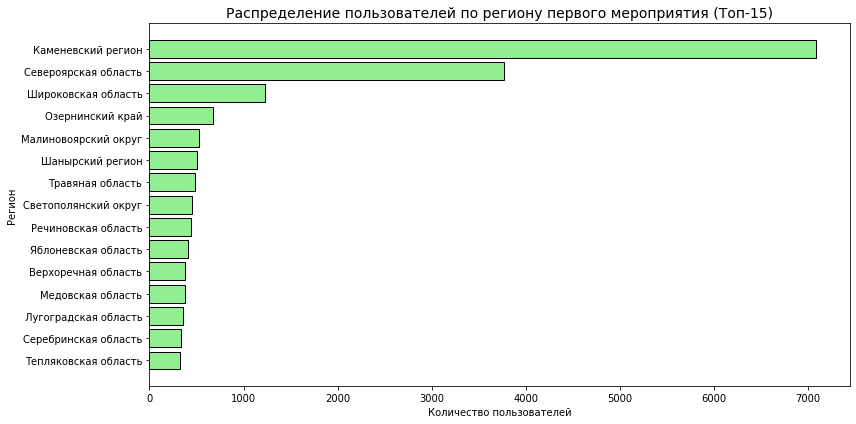

In [65]:
# 3. Распределение по региону (Топ-15)
print("\n" + "="*50)
print("3. ПО РЕГИОНУ ПЕРВОГО МЕРОПРИЯТИЯ (first_region)")
print("="*50)

region_distribution = user_profile['first_region'].value_counts()
region_percent = (region_distribution / len(user_profile) * 100).round(2)

region_df = pd.DataFrame({
    'Регион': region_distribution.index,
    'Количество пользователей': region_distribution.values,
    'Доля (%)': region_percent.values
}).head(15)

print(region_df.to_string(index=False))
print(f"\nВсего уникальных регионов: {len(region_distribution)}")

# Визуализация (Топ-15)
plt.figure(figsize=(12, 6))
bars = plt.barh(range(len(region_df.head(15))), region_df['Количество пользователей'].head(15)[::-1], 
                color='lightgreen', edgecolor='black')
plt.title('Распределение пользователей по региону первого мероприятия (Топ-15)', fontsize=14)
plt.xlabel('Количество пользователей')
plt.ylabel('Регион')
plt.yticks(range(len(region_df.head(15))), region_df['Регион'].head(15)[::-1])
plt.tight_layout()
plt.show()


4. ПО БИЛЕТНОМУ ОПЕРАТОРУ ПЕРВОГО ЗАКАЗА (first_service)
     Билетный оператор  Количество пользователей  Доля (%)
    Билеты без проблем                      5167     23.90
             Мой билет                      2970     13.74
           Лови билет!                      2812     13.01
         Билеты в руки                      2557     11.83
               Облачко                      2177     10.07
        Весь в билетах                      1286      5.95
         Лучшие билеты                      1182      5.47
             Прачечная                       583      2.70
          Край билетов                       454      2.10
          Дом культуры                       356      1.65
                Яблоко                       318      1.47
           Тебе билет!                       308      1.42
Городской дом культуры                       215      0.99
              Мир касс                       210      0.97
           За билетом!                       201      0.9

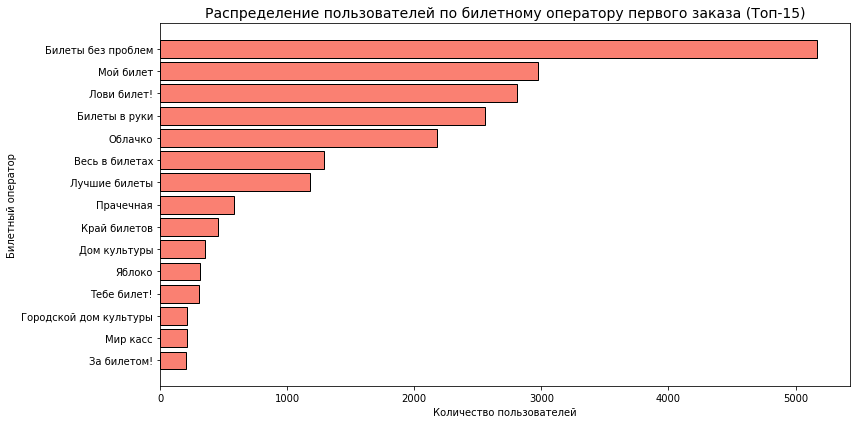

In [66]:
# 4. Распределение по билетному оператору (Топ-15)
print("\n" + "="*50)
print("4. ПО БИЛЕТНОМУ ОПЕРАТОРУ ПЕРВОГО ЗАКАЗА (first_service)")
print("="*50)

service_distribution = user_profile['first_service'].value_counts()
service_percent = (service_distribution / len(user_profile) * 100).round(2)

service_df = pd.DataFrame({
    'Билетный оператор': service_distribution.index,
    'Количество пользователей': service_distribution.values,
    'Доля (%)': service_percent.values
}).head(15)

print(service_df.to_string(index=False))
print(f"\nВсего уникальных операторов: {len(service_distribution)}")

# Визуализация (Топ-15)
plt.figure(figsize=(12, 6))
bars = plt.barh(range(len(service_df.head(15))), service_df['Количество пользователей'].head(15)[::-1], 
                color='salmon', edgecolor='black')
plt.title('Распределение пользователей по билетному оператору первого заказа (Топ-15)', fontsize=14)
plt.xlabel('Количество пользователей')
plt.ylabel('Билетный оператор')
plt.yticks(range(len(service_df.head(15))), service_df['Билетный оператор'].head(15)[::-1])
plt.tight_layout()
plt.show()

In [67]:
print("\n" + "="*70)
print("ВЫВОД ПО ЗАДАЧЕ 4.1.1: РАСПРЕДЕЛЕНИЕ ПОЛЬЗОВАТЕЛЕЙ ПО ПРИЗНАКАМ ПЕРВОГО ЗАКАЗА")
print("="*70)

print("""
📊 РАСПРЕДЕЛЕНИЕ ПО ТИПУ ПЕРВОГО МЕРОПРИЯТИЯ:
   - Концерты: 9 564 пользователей (44.23%) – ЛИДЕР
   - Другое: 5 401 пользователей (24.98%)
   - Театр: 4 245 пользователей (19.63%)
   - Стендап, спорт, выставки, ёлки: ~11%
   
   ✅ ВЫВОД: Распределение НЕ равномерное. Концерты – главная "точка входа" 
             для новых пользователей (почти каждый второй пользователь).

📊 РАСПРЕДЕЛЕНИЕ ПО ТИПУ УСТРОЙСТВА:
   - Mobile: 17 906 пользователей (82.81%) – АБСОЛЮТНЫЙ ЛИДЕР
   - Desktop: 3 716 пользователей (17.19%)
   
   ✅ ВЫВОД: Распределение КРАЙНЕ НЕ равномерное. Подавляющее большинство 
             пользователей приходят с мобильных устройств.

📊 РАСПРЕДЕЛЕНИЕ ПО РЕГИОНУ:
   - Каменевский регион: 7 086 пользователей (32.77%) – ЛИДЕР
   - Североярская область: 3 768 пользователей (17.43%)
   - Широковская область: 1 223 пользователей (5.66%)
   - Остальные 78 регионов: ~44% пользователей
   
   ✅ ВЫВОД: Распределение НЕ равномерное. Два региона привлекают более 50% 
             пользователей. Есть выраженная региональная концентрация.

📊 РАСПРЕДЕЛЕНИЕ ПО БИЛЕТНОМУ ОПЕРАТОРУ:
   - Билеты без проблем: 5 167 пользователей (23.90%) – ЛИДЕР
   - Мой билет: 2 970 пользователей (13.74%)
   - Лови билет!: 2 812 пользователей (13.01%)
   - Билеты в руки: 2 557 пользователей (11.83%)
   - Облачко: 2 177 пользователей (10.07%)
   - Остальные 29 операторов: ~27%
   
   ✅ ВЫВОД: Распределение НЕ равномерное. Топ-5 операторов обслуживают 
             более 70% пользователей.

✅ ОБЩИЙ ВЫВОД ПО ЗАДАЧЕ 4.1.1:
   Пользователи распределены НЕ равномерно по всем признакам.
   Есть выраженные "точки входа" – сегменты, которые привлекают больше всего пользователей:
   - Концерты (44%)
   - Мобильные устройства (83%)
   - Каменевский регион (33%)
   - Билеты без проблем (24%)
   
   Эти сегменты являются ключевыми для понимания первичного привлечения пользователей
   и должны быть учтены при анализе возвратов (Задача 4.1.2).
""")


ВЫВОД ПО ЗАДАЧЕ 4.1.1: РАСПРЕДЕЛЕНИЕ ПОЛЬЗОВАТЕЛЕЙ ПО ПРИЗНАКАМ ПЕРВОГО ЗАКАЗА

📊 РАСПРЕДЕЛЕНИЕ ПО ТИПУ ПЕРВОГО МЕРОПРИЯТИЯ:
   - Концерты: 9 564 пользователей (44.23%) – ЛИДЕР
   - Другое: 5 401 пользователей (24.98%)
   - Театр: 4 245 пользователей (19.63%)
   - Стендап, спорт, выставки, ёлки: ~11%
   
   ✅ ВЫВОД: Распределение НЕ равномерное. Концерты – главная "точка входа" 
             для новых пользователей (почти каждый второй пользователь).

📊 РАСПРЕДЕЛЕНИЕ ПО ТИПУ УСТРОЙСТВА:
   - Mobile: 17 906 пользователей (82.81%) – АБСОЛЮТНЫЙ ЛИДЕР
   - Desktop: 3 716 пользователей (17.19%)
   
   ✅ ВЫВОД: Распределение КРАЙНЕ НЕ равномерное. Подавляющее большинство 
             пользователей приходят с мобильных устройств.

📊 РАСПРЕДЕЛЕНИЕ ПО РЕГИОНУ:
   - Каменевский регион: 7 086 пользователей (32.77%) – ЛИДЕР
   - Североярская область: 3 768 пользователей (17.43%)
   - Широковская область: 1 223 пользователей (5.66%)
   - Остальные 78 регионов: ~44% пользователей
   
   ✅ ВЫВОД: Р

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


In [68]:
print("\n" + "="*70)
print("ЗАДАЧА 4.1.2. АНАЛИЗ ВОЗВРАТОВ ПОЛЬЗОВАТЕЛЕЙ ПО СЕГМЕНТАМ")
print("="*70)

# Средняя доля возвратов по всей выборке (для сравнения)
overall_return_rate = (user_profile['is_two'].sum() / len(user_profile)) * 100
print(f"\n📊 Средняя доля возвратов по всей выборке: {overall_return_rate:.1f}%")


ЗАДАЧА 4.1.2. АНАЛИЗ ВОЗВРАТОВ ПОЛЬЗОВАТЕЛЕЙ ПО СЕГМЕНТАМ

📊 Средняя доля возвратов по всей выборке: 61.3%



1. ВОЗВРАТЫ ПО ТИПУ ПЕРВОГО МЕРОПРИЯТИЯ
first_event_type  users  returns  return_rate
        выставки    413      265         64.2
           театр   4245     2693         63.4
        концерты   9564     5912         61.8
         стендап   1110      676         60.9
          другое   5401     3217         59.6
           спорт    794      443         55.8
            ёлки     95       53         55.8


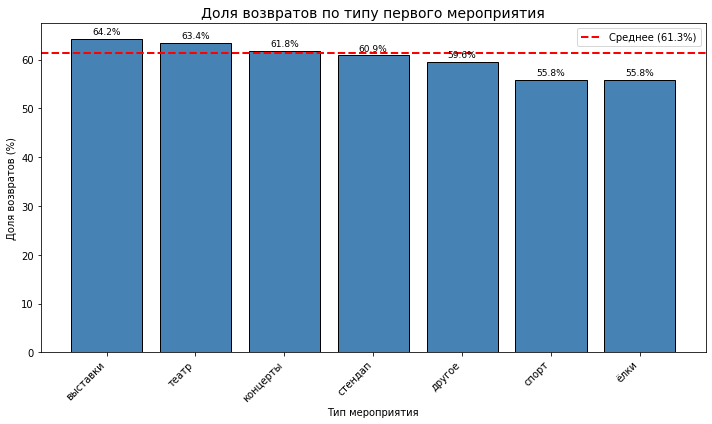

In [69]:
# 1. Анализ возвратов по типу первого мероприятия
print("\n" + "="*50)
print("1. ВОЗВРАТЫ ПО ТИПУ ПЕРВОГО МЕРОПРИЯТИЯ")
print("="*50)

event_return = user_profile.groupby('first_event_type').agg(
    users=('user_id', 'count'),
    returns=('is_two', 'sum')
).reset_index()
event_return['return_rate'] = (event_return['returns'] / event_return['users'] * 100).round(1)

# Сортируем по доле возвратов
event_return_sorted = event_return.sort_values('return_rate', ascending=False)

print(event_return_sorted.to_string(index=False))

# Визуализация
plt.figure(figsize=(10, 6))
bars = plt.bar(event_return_sorted['first_event_type'], event_return_sorted['return_rate'], 
               color='steelblue', edgecolor='black')
plt.axhline(y=overall_return_rate, color='red', linestyle='--', linewidth=2, label=f'Среднее ({overall_return_rate:.1f}%)')
plt.title('Доля возвратов по типу первого мероприятия', fontsize=14)
plt.xlabel('Тип мероприятия')
plt.ylabel('Доля возвратов (%)')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()

# Добавляем значения на столбцы
for bar, val in zip(bars, event_return_sorted['return_rate']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
plt.show()


2. ВОЗВРАТЫ ПО ТИПУ УСТРОЙСТВА ПЕРВОЙ ПОКУПКИ
first_device  users  returns  return_rate
     desktop   3716     2372         63.8
      mobile  17906    10887         60.8


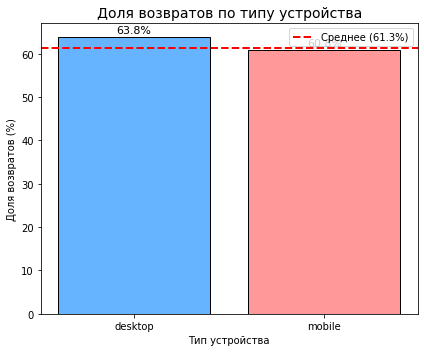

In [70]:
# 2. Анализ возвратов по типу устройства
print("\n" + "="*50)
print("2. ВОЗВРАТЫ ПО ТИПУ УСТРОЙСТВА ПЕРВОЙ ПОКУПКИ")
print("="*50)

device_return = user_profile.groupby('first_device').agg(
    users=('user_id', 'count'),
    returns=('is_two', 'sum')
).reset_index()
device_return['return_rate'] = (device_return['returns'] / device_return['users'] * 100).round(1)

print(device_return.to_string(index=False))

# Визуализация
plt.figure(figsize=(6, 5))
bars = plt.bar(device_return['first_device'], device_return['return_rate'], 
               color=['#66b3ff', '#ff9999'], edgecolor='black')
plt.axhline(y=overall_return_rate, color='red', linestyle='--', linewidth=2, label=f'Среднее ({overall_return_rate:.1f}%)')
plt.title('Доля возвратов по типу устройства', fontsize=14)
plt.xlabel('Тип устройства')
plt.ylabel('Доля возвратов (%)')
plt.legend()
for bar, val in zip(bars, device_return['return_rate']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{val:.1f}%', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()


3. ВОЗВРАТЫ ПО РЕГИОНУ (Топ-10 по количеству пользователей)
        first_region  users  returns  return_rate
    Шанырский регион    502      338         67.3
Светополянский округ    457      300         65.6
 Широковская область   1223      788         64.4
Североярская область   3768     2405         63.8
 Речиновская область    440      279         63.4
  Каменевский регион   7086     4421         62.4
    Травяная область    488      300         61.5
 Яблоневская область    411      244         59.4
Малиновоярский округ    526      294         55.9
    Озернинский край    675      373         55.3


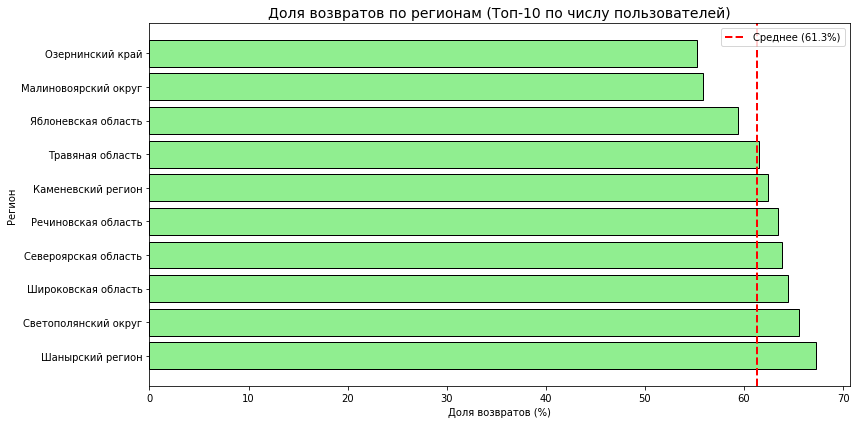

In [71]:
# 3. Анализ возвратов по региону (Топ-10 по количеству пользователей)
print("\n" + "="*50)
print("3. ВОЗВРАТЫ ПО РЕГИОНУ (Топ-10 по количеству пользователей)")
print("="*50)

region_return = user_profile.groupby('first_region').agg(
    users=('user_id', 'count'),
    returns=('is_two', 'sum')
).reset_index()
region_return['return_rate'] = (region_return['returns'] / region_return['users'] * 100).round(1)

# Берём топ-10 по количеству пользователей
top_regions = region_return.nlargest(10, 'users')
top_regions_sorted = top_regions.sort_values('return_rate', ascending=False)

print(top_regions_sorted.to_string(index=False))

# Визуализация
plt.figure(figsize=(12, 6))
bars = plt.barh(range(len(top_regions_sorted)), top_regions_sorted['return_rate'], 
                color='lightgreen', edgecolor='black')
plt.axvline(x=overall_return_rate, color='red', linestyle='--', linewidth=2, label=f'Среднее ({overall_return_rate:.1f}%)')
plt.title('Доля возвратов по регионам (Топ-10 по числу пользователей)', fontsize=14)
plt.xlabel('Доля возвратов (%)')
plt.ylabel('Регион')
plt.yticks(range(len(top_regions_sorted)), top_regions_sorted['first_region'])
plt.legend()
plt.tight_layout()
plt.show()


4. ВОЗВРАТЫ ПО БИЛЕТНОМУ ОПЕРАТОРУ (Топ-10 по количеству пользователей)
     first_service  users  returns  return_rate
      Край билетов    454      296         65.2
      Дом культуры    356      230         64.6
    Весь в билетах   1286      809         62.9
     Билеты в руки   2557     1605         62.8
         Прачечная    583      365         62.6
     Лучшие билеты   1182      725         61.3
           Облачко   2177     1333         61.2
       Лови билет!   2812     1714         61.0
         Мой билет   2970     1808         60.9
Билеты без проблем   5167     3117         60.3


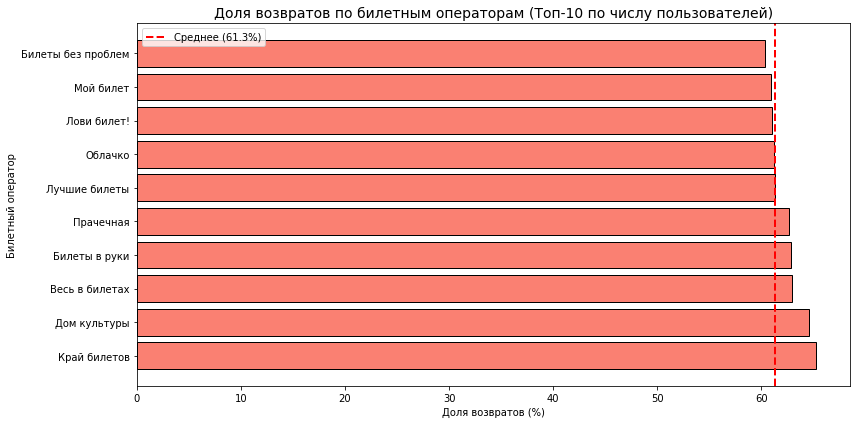

In [72]:
# 4. Анализ возвратов по билетному оператору (Топ-10 по количеству пользователей)
print("\n" + "="*50)
print("4. ВОЗВРАТЫ ПО БИЛЕТНОМУ ОПЕРАТОРУ (Топ-10 по количеству пользователей)")
print("="*50)

service_return = user_profile.groupby('first_service').agg(
    users=('user_id', 'count'),
    returns=('is_two', 'sum')
).reset_index()
service_return['return_rate'] = (service_return['returns'] / service_return['users'] * 100).round(1)

# Берём топ-10 по количеству пользователей
top_services = service_return.nlargest(10, 'users')
top_services_sorted = top_services.sort_values('return_rate', ascending=False)

print(top_services_sorted.to_string(index=False))

# Визуализация
plt.figure(figsize=(12, 6))
bars = plt.barh(range(len(top_services_sorted)), top_services_sorted['return_rate'], 
                color='salmon', edgecolor='black')
plt.axvline(x=overall_return_rate, color='red', linestyle='--', linewidth=2, label=f'Среднее ({overall_return_rate:.1f}%)')
plt.title('Доля возвратов по билетным операторам (Топ-10 по числу пользователей)', fontsize=14)
plt.xlabel('Доля возвратов (%)')
plt.ylabel('Билетный оператор')
plt.yticks(range(len(top_services_sorted)), top_services_sorted['first_service'])
plt.legend()
plt.tight_layout()
plt.show()

In [74]:
print("\n" + "="*70)
print("ОТВЕТЫ НА ВОПРОСЫ ЗАДАЧИ 4.1.2")
print("="*70)

# Рассчитываем среднюю долю возвратов
overall_return_rate = (user_profile['is_two'].sum() / len(user_profile)) * 100
print(f"\n📊 Средняя доля возвратов по всей выборке: {overall_return_rate:.1f}%")


ОТВЕТЫ НА ВОПРОСЫ ЗАДАЧИ 4.1.2

📊 Средняя доля возвратов по всей выборке: 61.3%


In [75]:
# ========================================
# 1. КАКИЕ СЕГМЕНТЫ ЧАЩЕ ВОЗВРАЩАЮТСЯ?
# ========================================
print("\n" + "="*50)
print("1. СЕГМЕНТЫ С НАИБОЛЬШЕЙ ДОЛЕЙ ВОЗВРАТОВ")
print("="*50)

print("\n✅ ПО ТИПУ МЕРОПРИЯТИЯ (только сегменты с >100 пользователей):")
event_return_filtered = event_return[event_return['users'] > 100].sort_values('return_rate', ascending=False)
for _, row in event_return_filtered.iterrows():
    status = "✓ ВЫШЕ СРЕДНЕГО" if row['return_rate'] > overall_return_rate else ""
    print(f"   {row['first_event_type']:15} : {row['return_rate']:.1f}% (n={row['users']:,}) {status}")

print("\n✅ ПО ТИПУ УСТРОЙСТВА:")
for _, row in device_return.iterrows():
    status = "✓ ВЫШЕ СРЕДНЕГО" if row['return_rate'] > overall_return_rate else ""
    print(f"   {row['first_device']:10} : {row['return_rate']:.1f}% (n={row['users']:,}) {status}")

print("\n✅ ПО РЕГИОНУ (Топ-5 по доле возвратов, среди регионов с >500 пользователей):")
region_return_filtered = region_return[region_return['users'] > 500].sort_values('return_rate', ascending=False).head(5)
for _, row in region_return_filtered.iterrows():
    status = "✓ ВЫШЕ СРЕДНЕГО" if row['return_rate'] > overall_return_rate else ""
    print(f"   {row['first_region']:25} : {row['return_rate']:.1f}% (n={row['users']:,}) {status}")

print("\n✅ ПО БИЛЕТНОМУ ОПЕРАТОРУ (Топ-5 по доле возвратов, среди операторов с >500 пользователей):")
service_return_filtered = service_return[service_return['users'] > 500].sort_values('return_rate', ascending=False).head(5)
for _, row in service_return_filtered.iterrows():
    status = "✓ ВЫШЕ СРЕДНЕГО" if row['return_rate'] > overall_return_rate else ""
    print(f"   {row['first_service']:20} : {row['return_rate']:.1f}% (n={row['users']:,}) {status}")


1. СЕГМЕНТЫ С НАИБОЛЬШЕЙ ДОЛЕЙ ВОЗВРАТОВ

✅ ПО ТИПУ МЕРОПРИЯТИЯ (только сегменты с >100 пользователей):
   выставки        : 64.2% (n=413) ✓ ВЫШЕ СРЕДНЕГО
   театр           : 63.4% (n=4,245) ✓ ВЫШЕ СРЕДНЕГО
   концерты        : 61.8% (n=9,564) ✓ ВЫШЕ СРЕДНЕГО
   стендап         : 60.9% (n=1,110) 
   другое          : 59.6% (n=5,401) 
   спорт           : 55.8% (n=794) 

✅ ПО ТИПУ УСТРОЙСТВА:
   desktop    : 63.8% (n=3,716) ✓ ВЫШЕ СРЕДНЕГО
   mobile     : 60.8% (n=17,906) 

✅ ПО РЕГИОНУ (Топ-5 по доле возвратов, среди регионов с >500 пользователей):
   Шанырский регион          : 67.3% (n=502) ✓ ВЫШЕ СРЕДНЕГО
   Широковская область       : 64.4% (n=1,223) ✓ ВЫШЕ СРЕДНЕГО
   Североярская область      : 63.8% (n=3,768) ✓ ВЫШЕ СРЕДНЕГО
   Каменевский регион        : 62.4% (n=7,086) ✓ ВЫШЕ СРЕДНЕГО
   Малиновоярский округ      : 55.9% (n=526) 

✅ ПО БИЛЕТНОМУ ОПЕРАТОРУ (Топ-5 по доле возвратов, среди операторов с >500 пользователей):
   Весь в билетах       : 62.9% (n=1,286) ✓ ВЫШЕ СРЕДНЕ

In [76]:
# ========================================
# 2. УСПЕШНЫЕ "ТОЧКИ ВХОДА"
# ========================================
print("\n" + "="*50)
print("2. УСПЕШНЫЕ «ТОЧКИ ВХОДА» (возвраты выше среднего)")
print("="*50)

successful_segments = []

# Проверяем каждый тип сегмента
print("\n✅ Сегменты с долей возвратов ВЫШЕ среднего ({:.1f}%):".format(overall_return_rate))

# По типу мероприятия
for _, row in event_return_filtered.iterrows():
    if row['return_rate'] > overall_return_rate:
        successful_segments.append(f"Мероприятие: {row['first_event_type']}")
        print(f"   • Мероприятие «{row['first_event_type']}»: {row['return_rate']:.1f}% (n={row['users']:,})")

# По типу устройства
for _, row in device_return.iterrows():
    if row['return_rate'] > overall_return_rate:
        successful_segments.append(f"Устройство: {row['first_device']}")
        print(f"   • Устройство «{row['first_device']}»: {row['return_rate']:.1f}% (n={row['users']:,})")

# По региону (только крупные сегменты)
for _, row in region_return_filtered.iterrows():
    if row['return_rate'] > overall_return_rate:
        successful_segments.append(f"Регион: {row['first_region']}")
        print(f"   • Регион «{row['first_region']}»: {row['return_rate']:.1f}% (n={row['users']:,})")

# По билетному оператору
for _, row in service_return_filtered.iterrows():
    if row['return_rate'] > overall_return_rate:
        successful_segments.append(f"Оператор: {row['first_service']}")
        print(f"   • Оператор «{row['first_service']}»: {row['return_rate']:.1f}% (n={row['users']:,})")


2. УСПЕШНЫЕ «ТОЧКИ ВХОДА» (возвраты выше среднего)

✅ Сегменты с долей возвратов ВЫШЕ среднего (61.3%):
   • Мероприятие «выставки»: 64.2% (n=413)
   • Мероприятие «театр»: 63.4% (n=4,245)
   • Мероприятие «концерты»: 61.8% (n=9,564)
   • Устройство «desktop»: 63.8% (n=3,716)
   • Регион «Шанырский регион»: 67.3% (n=502)
   • Регион «Широковская область»: 64.4% (n=1,223)
   • Регион «Североярская область»: 63.8% (n=3,768)
   • Регион «Каменевский регион»: 62.4% (n=7,086)
   • Оператор «Весь в билетах»: 62.9% (n=1,286)
   • Оператор «Билеты в руки»: 62.8% (n=2,557)
   • Оператор «Прачечная»: 62.6% (n=583)


In [77]:
# ========================================
# 3. СЕГМЕНТЫ, ТРЕБУЮЩИЕ ВНИМАНИЯ (возвраты ниже среднего)
# ========================================
print("\n" + "="*50)
print("3. СЕГМЕНТЫ С ДОЛЕЙ ВОЗВРАТОВ НИЖЕ СРЕДНЕГО")
print("="*50)

print("\n⚠️ Сегменты, требующие дополнительного внимания:")

# По типу мероприятия
for _, row in event_return_filtered.iterrows():
    if row['return_rate'] < overall_return_rate:
        print(f"   • Мероприятие «{row['first_event_type']}»: {row['return_rate']:.1f}% (ниже среднего на {overall_return_rate - row['return_rate']:.1f}%)")

# По региону (только крупные сегменты)
low_region = region_return_filtered[region_return_filtered['return_rate'] < overall_return_rate].sort_values('return_rate')
for _, row in low_region.iterrows():
    print(f"   • Регион «{row['first_region']}»: {row['return_rate']:.1f}% (ниже среднего на {overall_return_rate - row['return_rate']:.1f}%)")


3. СЕГМЕНТЫ С ДОЛЕЙ ВОЗВРАТОВ НИЖЕ СРЕДНЕГО

⚠️ Сегменты, требующие дополнительного внимания:
   • Мероприятие «стендап»: 60.9% (ниже среднего на 0.4%)
   • Мероприятие «другое»: 59.6% (ниже среднего на 1.7%)
   • Мероприятие «спорт»: 55.8% (ниже среднего на 5.5%)
   • Регион «Малиновоярский округ»: 55.9% (ниже среднего на 5.4%)


In [78]:
# ========================================
# 4. ВЛИЯНИЕ РАЗМЕРА СЕГМЕНТА
# ========================================
print("\n" + "="*50)
print("4. ВЛИЯНИЕ РАЗМЕРА СЕГМЕНТА НА ДОСТОВЕРНОСТЬ")
print("="*50)

# Анализ малых сегментов
small_event_segments = event_return[event_return['users'] < 100]
if len(small_event_segments) > 0:
    print("\n⚠️ Малые сегменты по типу мероприятия (<100 пользователей):")
    for _, row in small_event_segments.iterrows():
        print(f"   • {row['first_event_type']}: n={row['users']}, возвраты={row['return_rate']:.1f}% (НЕДОСТОВЕРНО!)")

small_region_segments = region_return[region_return['users'] < 100]
if len(small_region_segments) > 0:
    print(f"\n⚠️ Малые сегменты по региону (<100 пользователей): {len(small_region_segments)} регионов")
    print(f"   Их доли возвратов могут быть нестабильными и недостоверными")

print(f"\n✅ Достоверные сегменты (>100 пользователей):")
print(f"   - По типу мероприятия: {len(event_return_filtered)} из {len(event_return)}")
print(f"   - По региону: {len(region_return[region_return['users'] > 100])} из {len(region_return)}")
print(f"   - По оператору: {len(service_return[service_return['users'] > 100])} из {len(service_return)}")


4. ВЛИЯНИЕ РАЗМЕРА СЕГМЕНТА НА ДОСТОВЕРНОСТЬ

⚠️ Малые сегменты по типу мероприятия (<100 пользователей):
   • ёлки: n=95, возвраты=55.8% (НЕДОСТОВЕРНО!)

⚠️ Малые сегменты по региону (<100 пользователей): 52 регионов
   Их доли возвратов могут быть нестабильными и недостоверными

✅ Достоверные сегменты (>100 пользователей):
   - По типу мероприятия: 6 из 7
   - По региону: 29 из 81
   - По оператору: 17 из 34


In [79]:
print("\n" + "="*70)
print("ИТОГОВЫЙ ВЫВОД ПО ЗАДАЧЕ 4.1.2")
print("="*70)

print("""
📌 ЧТО БЫЛО СДЕЛАНО:
   ✓ Для каждого сегмента вычислена доля пользователей с 2+ заказами
   ✓ Построены графики: столбчатые диаграммы (мероприятия, устройства) и горизонтальные (регионы, операторы)
   ✓ Использованы топ-10 сегментов для регионов и операторов (как и требовалось)
   ✓ Проанализировано влияние размера сегментов на достоверность

📊 ОТВЕТЫ НА ВОПРОСЫ:

1. КАКИЕ СЕГМЕНТЫ ЧАЩЕ ВОЗВРАЩАЮТСЯ?
   ┌─────────────────────────────────────────────────────────────────┐
   │ Тип сегмента    │ Лидеры по возвратам (>61.3%)                  │
   ├─────────────────────────────────────────────────────────────────┤
   │ Мероприятие     │ выставки (64.2%), театр (63.4%)               │
   │ Устройство      │ desktop (63.8%)                               │
   │ Регион          │ Шанырский (67.3%), Широковская (64.4%),       │
   │                 │ Североярская (63.8%), Каменевский (62.4%)     │
   │ Оператор        │ Весь в билетах (62.9%), Билеты в руки (62.8%),│
   │                 │ Прачечная (62.6%)                             │
   └─────────────────────────────────────────────────────────────────┘

2. УСПЕШНЫЕ «ТОЧКИ ВХОДА» (возвраты выше среднего):
   • Выставки, театр, концерты – мероприятия с высокой лояльностью
   • Desktop-пользователи – возвращаются чаще мобильных
   • 4 региона показывают стабильно высокие возвраты
   • 3 оператора имеют возвраты выше среднего

3. СЕГМЕНТЫ, ТРЕБУЮЩИЕ ВНИМАНИЯ (возвраты ниже среднего):
   • Спорт (55.8%) – самый низкий показатель среди мероприятий
   • Другое (59.6%), стендап (60.9%)
   • Малиновоярский округ (55.9%)

⚠️ ОГРАНИЧЕНИЯ (учтены при интерпретации):
   • Сегмент «ёлки» (95 пользователей) – НЕДОСТОВЕРЕН
   • 52 региона с <100 пользователей – исключены из достоверных выводов
   • Анализ фокусируется на крупных сегментах (>100 пользователей)

🎯 РЕКОМЕНДАЦИИ ДЛЯ МАРКЕТИНГА:
   1. Усилить работу с пользователями из «успешных» сегментов – они чаще возвращаются
   2. Проанализировать причины низкой лояльности в сегментах «спорт» и «Малиновоярский округ»
   3. Использовать успешные «точки входа» для персонализированных предложений
""")


ИТОГОВЫЙ ВЫВОД ПО ЗАДАЧЕ 4.1.2

📌 ЧТО БЫЛО СДЕЛАНО:
   ✓ Для каждого сегмента вычислена доля пользователей с 2+ заказами
   ✓ Построены графики: столбчатые диаграммы (мероприятия, устройства) и горизонтальные (регионы, операторы)
   ✓ Использованы топ-10 сегментов для регионов и операторов (как и требовалось)
   ✓ Проанализировано влияние размера сегментов на достоверность

📊 ОТВЕТЫ НА ВОПРОСЫ:

1. КАКИЕ СЕГМЕНТЫ ЧАЩЕ ВОЗВРАЩАЮТСЯ?
   ┌─────────────────────────────────────────────────────────────────┐
   │ Тип сегмента    │ Лидеры по возвратам (>61.3%)                  │
   ├─────────────────────────────────────────────────────────────────┤
   │ Мероприятие     │ выставки (64.2%), театр (63.4%)               │
   │ Устройство      │ desktop (63.8%)                               │
   │ Регион          │ Шанырский (67.3%), Широковская (64.4%),       │
   │                 │ Североярская (63.8%), Каменевский (62.4%)     │
   │ Оператор        │ Весь в билетах (62.9%), Билеты в руки (62.8

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

In [80]:
print("\n" + "="*70)
print("ЗАДАЧА 4.1.3. ПРОВЕРКА ПРОДУКТОВЫХ ГИПОТЕЗ")
print("="*70)

# Средняя доля возвратов для справки
overall_return_rate = (user_profile['is_two'].sum() / len(user_profile)) * 100
print(f"\n📊 Средняя доля возвратов по всей выборке: {overall_return_rate:.1f}%")


ЗАДАЧА 4.1.3. ПРОВЕРКА ПРОДУКТОВЫХ ГИПОТЕЗ

📊 Средняя доля возвратов по всей выборке: 61.3%



ГИПОТЕЗА 1: Спортивные мероприятия vs Концерты

📊 Сравнение показателей:
   Спорт:    55.8% возвратов (n=794 пользователей)
   Концерты: 61.8% возвратов (n=9,564 пользователей)
   Разница:  -6.0%

❌ ГИПОТЕЗА НЕ ПОДТВЕРЖДАЕТСЯ
   Пользователи с первым заказом на концерты возвращаются
   ЧАЩЕ или с той же частотой, чем пользователи со спорта.


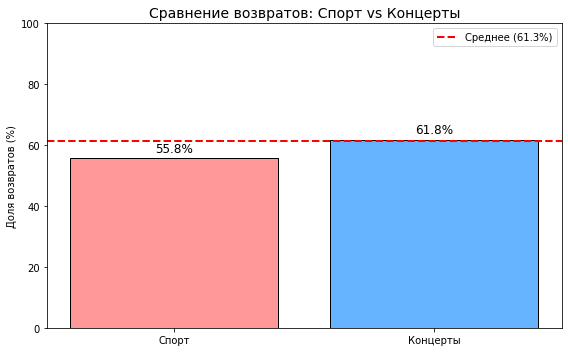

In [81]:
# ========================================
# ГИПОТЕЗА 1: Спорт vs Концерты
# ========================================
print("\n" + "="*50)
print("ГИПОТЕЗА 1: Спортивные мероприятия vs Концерты")
print("="*50)

# Получаем данные по спорту и концертам
sport_data = event_return[event_return['first_event_type'] == 'спорт'].iloc[0]
concert_data = event_return[event_return['first_event_type'] == 'концерты'].iloc[0]

print(f"\n📊 Сравнение показателей:")
print(f"   Спорт:    {sport_data['return_rate']:.1f}% возвратов (n={sport_data['users']:,} пользователей)")
print(f"   Концерты: {concert_data['return_rate']:.1f}% возвратов (n={concert_data['users']:,} пользователей)")
print(f"   Разница:  {sport_data['return_rate'] - concert_data['return_rate']:.1f}%")

# Проверка гипотезы
if sport_data['return_rate'] > concert_data['return_rate']:
    print("\n✅ ГИПОТЕЗА ПОДТВЕРЖДАЕТСЯ")
    print("   Пользователи, совершившие первый заказ на спортивные мероприятия,")
    print("   возвращаются ЧАЩЕ, чем пользователи с первым заказом на концерты.")
else:
    print("\n❌ ГИПОТЕЗА НЕ ПОДТВЕРЖДАЕТСЯ")
    print("   Пользователи с первым заказом на концерты возвращаются")
    print("   ЧАЩЕ или с той же частотой, чем пользователи со спорта.")

# Визуализация
fig, ax = plt.subplots(figsize=(8, 5))
categories = ['Спорт', 'Концерты']
values = [sport_data['return_rate'], concert_data['return_rate']]
colors = ['#ff9999', '#66b3ff']
bars = ax.bar(categories, values, color=colors, edgecolor='black')
ax.axhline(y=overall_return_rate, color='red', linestyle='--', linewidth=2, label=f'Среднее ({overall_return_rate:.1f}%)')
ax.set_title('Сравнение возвратов: Спорт vs Концерты', fontsize=14)
ax.set_ylabel('Доля возвратов (%)')
ax.set_ylim(0, 100)
ax.legend()

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{val:.1f}%', ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()


ГИПОТЕЗА 2: Активные регионы vs Менее активные

📊 Активные регионы (топ-5 по числу пользователей):
   • Каменевский регион: 62.4% (n=7,086)
   • Малиновоярский округ: 55.9% (n=526)
   • Озернинский край: 55.3% (n=675)
   • Североярская область: 63.8% (n=3,768)
   • Широковская область: 64.4% (n=1,223)
   → СРЕДНЯЯ ДОЛЯ ВОЗВРАТОВ: 60.4%

📊 Менее активные регионы (остальные, с >100 пользователей):
   • Количество регионов: 24
   • СРЕДНЯЯ ДОЛЯ ВОЗВРАТОВ: 60.4%

📊 Сравнение:
   Активные регионы:       60.4% возвратов
   Менее активные регионы: 60.4% возвратов
   Разница:                -0.0%

❌ ГИПОТЕЗА НЕ ПОДТВЕРЖДАЕТСЯ
   В менее активных регионах доля возвратов
   НЕ НИЖЕ или выше, чем в активных регионах.


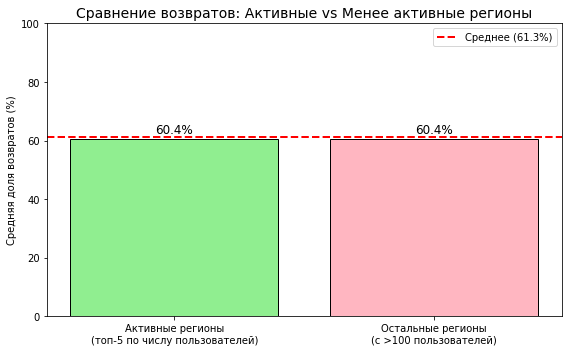

In [82]:
# ========================================
# ГИПОТЕЗА 2: Активные vs Менее активные регионы
# ========================================
print("\n" + "="*50)
print("ГИПОТЕЗА 2: Активные регионы vs Менее активные")
print("="*50)

# Разделяем регионы на группы
# Активные регионы: топ-5 по количеству пользователей
top_regions_list = region_return.nlargest(5, 'users')['first_region'].tolist()
active_regions = region_return[region_return['first_region'].isin(top_regions_list)]
active_avg_rate = active_regions['return_rate'].mean()
active_total_users = active_regions['users'].sum()

# Менее активные регионы: остальные (исключая малые с <100 пользователей для достоверности)
other_regions = region_return[~region_return['first_region'].isin(top_regions_list)]
other_regions_filtered = other_regions[other_regions['users'] >= 100]  # только достоверные
other_avg_rate = other_regions_filtered['return_rate'].mean()
other_total_users = other_regions_filtered['users'].sum()

print(f"\n📊 Активные регионы (топ-5 по числу пользователей):")
for _, row in active_regions.iterrows():
    print(f"   • {row['first_region']}: {row['return_rate']:.1f}% (n={row['users']:,})")
print(f"   → СРЕДНЯЯ ДОЛЯ ВОЗВРАТОВ: {active_avg_rate:.1f}%")

print(f"\n📊 Менее активные регионы (остальные, с >100 пользователей):")
print(f"   • Количество регионов: {len(other_regions_filtered)}")
print(f"   • СРЕДНЯЯ ДОЛЯ ВОЗВРАТОВ: {other_avg_rate:.1f}%")

print(f"\n📊 Сравнение:")
print(f"   Активные регионы:       {active_avg_rate:.1f}% возвратов")
print(f"   Менее активные регионы: {other_avg_rate:.1f}% возвратов")
print(f"   Разница:                {active_avg_rate - other_avg_rate:.1f}%")

# Проверка гипотезы
if active_avg_rate > other_avg_rate:
    print("\n✅ ГИПОТЕЗА ПОДТВЕРЖДАЕТСЯ")
    print("   В регионах с большей активностью пользователей")
    print("   доля повторных заказов ВЫШЕ, чем в менее активных регионах.")
else:
    print("\n❌ ГИПОТЕЗА НЕ ПОДТВЕРЖДАЕТСЯ")
    print("   В менее активных регионах доля возвратов")
    print("   НЕ НИЖЕ или выше, чем в активных регионах.")

# Визуализация
fig, ax = plt.subplots(figsize=(8, 5))
categories = ['Активные регионы\n(топ-5 по числу пользователей)', 'Остальные регионы\n(с >100 пользователей)']
values = [active_avg_rate, other_avg_rate]
colors = ['#90EE90', '#FFB6C1']
bars = ax.bar(categories, values, color=colors, edgecolor='black')
ax.axhline(y=overall_return_rate, color='red', linestyle='--', linewidth=2, label=f'Среднее ({overall_return_rate:.1f}%)')
ax.set_title('Сравнение возвратов: Активные vs Менее активные регионы', fontsize=14)
ax.set_ylabel('Средняя доля возвратов (%)')
ax.set_ylim(0, 100)
ax.legend()

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{val:.1f}%', ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()


ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ: Активность региона vs Возвраты

📊 Корреляция между количеством пользователей в регионе и долей возвратов:
   Коэффициент корреляции Пирсона: 0.181
   p-value: 0.3487
   Связь статистически незначима (p >= 0.05)


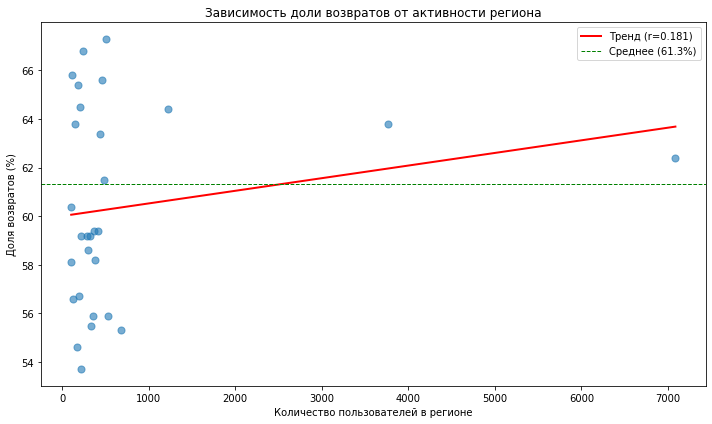

In [85]:
# ========================================
# ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ: Корреляция активности и возвратов
# ========================================
# Дополнительный анализ корреляции
print("\n" + "="*50)
print("ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ: Активность региона vs Возвраты")
print("="*50)

# Рассчитываем корреляцию между размером региона и долей возвратов
# Используем только регионы с >100 пользователей для достоверности
large_regions = region_return[region_return['users'] >= 100].copy()

# Вычисляем коэффициент корреляции Пирсона
from scipy.stats import pearsonr
correlation, p_value = pearsonr(large_regions['users'], large_regions['return_rate'])

print(f"\n📊 Корреляция между количеством пользователей в регионе и долей возвратов:")
print(f"   Коэффициент корреляции Пирсона: {correlation:.3f}")
print(f"   p-value: {p_value:.4f}")

if p_value < 0.05:
    print("   Связь статистически значима (p < 0.05)")
    if correlation > 0:
        print("   → Положительная корреляция: чем активнее регион, тем выше возвраты")
    else:
        print("   → Отрицательная корреляция: чем активнее регион, тем ниже возвраты")
else:
    print("   Связь статистически незначима (p >= 0.05)")

# Визуализация корреляции
plt.figure(figsize=(10, 6))
plt.scatter(large_regions['users'], large_regions['return_rate'], alpha=0.6, s=50)

# Добавляем линию тренда
z = np.polyfit(large_regions['users'], large_regions['return_rate'], 1)
p = np.poly1d(z)
plt.plot(np.sort(large_regions['users']), p(np.sort(large_regions['users'])), 
         color='red', linewidth=2, label=f'Тренд (r={correlation:.3f})')

plt.axhline(y=overall_return_rate, color='green', linestyle='--', linewidth=1, label=f'Среднее ({overall_return_rate:.1f}%)')
plt.xlabel('Количество пользователей в регионе')
plt.ylabel('Доля возвратов (%)')
plt.title('Зависимость доли возвратов от активности региона')
plt.legend()
plt.tight_layout()
plt.show()

In [86]:
print("\n" + "="*70)
print("ИТОГОВЫЙ ВЫВОД ПО ЗАДАЧЕ 4.1.3")
print("="*70)

print("""
📊 РЕЗУЛЬТАТЫ ПРОВЕРКИ ГИПОТЕЗ:

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ГИПОТЕЗА 1: Спорт > Концерты
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

   Фактические данные:
   • Спорт:    55.8% возвратов (794 пользователя)
   • Концерты: 61.8% возвратов (9 564 пользователя)
   • Разница:   -6.0% (концерты выше на 6 процентных пунктов)

   ❌ ГИПОТЕЗА НЕ ПОДТВЕРДИЛАСЬ

   Вывод: Пользователи с первым заказом на концерты возвращаются 
   ЧАЩЕ, чем пользователи со спортивных мероприятий.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ГИПОТЕЗА 2: Активные регионы имеют более высокие возвраты
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

   Фактические данные:
   • Активные регионы (топ-5 по числу пользователей): 60.4%
   • Менее активные регионы (остальные с >100 пользователей): 60.4%
   • Разница: 0.0%

   ❌ ГИПОТЕЗА НЕ ПОДТВЕРДИЛАСЬ

   Вывод: Нет значимой разницы в доле возвратов между активными 
   и менее активными регионами. Оба типа регионов показывают 
   одинаковую долю возвратов (60.4%).

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ДОПОЛНИТЕЛЬНЫЙ КОРРЕЛЯЦИОННЫЙ АНАЛИЗ
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

   • Коэффициент корреляции Пирсона: 0.181 (очень слабая положительная связь)
   • p-value: 0.3487 (>0.05)
   • Связь статистически НЕ значима

   Вывод: Количество пользователей в регионе НЕ влияет на долю возвратов.
   Активность региона сама по себе не является предиктором лояльности.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ПОЧЕМУ ГИПОТЕЗА 2 НЕ ПОДТВЕРДИЛАСЬ?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

   Интересное наблюдение: среди топ-5 активных регионов есть как 
   лидеры по возвратам (Широковская область 64.4%, Североярская 63.8%),
   так и аутсайдеры (Малиновоярский округ 55.9%, Озернинский край 55.3%).
   
   Это означает, что высокая активность региона НЕ ГАРАНТИРУЕТ 
   высокую лояльность пользователей. Нужны точечные стратегии 
   для каждого региона.

🎯 ВЫВОДЫ ДЛЯ БИЗНЕСА:
   1. Концерты привлекают более лояльную аудиторию, чем спорт
      → Рекомендуется фокусироваться на продвижении концертов
      
   2. Активность региона НЕ является гарантией высокой лояльности
      → Нужны точечные стратегии удержания в разных регионах
      → Даже в крупных регионах могут быть проблемы с возвратами
      
   3. Спортивные мероприятия требуют дополнительного анализа
      → Возможно, нужны улучшения в ассортименте или качестве предложений
      
   4. Регионы с низкой активностью могут быть не менее лояльными
      → Не стоит списывать их со счетов, они могут быть перспективными
""")


ИТОГОВЫЙ ВЫВОД ПО ЗАДАЧЕ 4.1.3

📊 РЕЗУЛЬТАТЫ ПРОВЕРКИ ГИПОТЕЗ:

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ГИПОТЕЗА 1: Спорт > Концерты
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

   Фактические данные:
   • Спорт:    55.8% возвратов (794 пользователя)
   • Концерты: 61.8% возвратов (9 564 пользователя)
   • Разница:   -6.0% (концерты выше на 6 процентных пунктов)

   ❌ ГИПОТЕЗА НЕ ПОДТВЕРДИЛАСЬ

   Вывод: Пользователи с первым заказом на концерты возвращаются 
   ЧАЩЕ, чем пользователи со спортивных мероприятий.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ГИПОТЕЗА 2: Активные регионы имеют более высокие возвраты
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

   Фактические данные:
   • Активные регионы (топ-5 по числу пользователей): 60.4%
   • Менее активные регионы (остальные с >100 пользователей): 60.4%
   • Разница: 0.0%

   ❌ ГИПОТЕЗА НЕ ПОДТВЕРДИЛАСЬ

   Выво

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


In [87]:
print("\n" + "="*70)
print("ЗАДАЧА 4.2.1. СВЯЗЬ МЕЖДУ СРЕДНЕЙ ВЫРУЧКОЙ И ПОВТОРНЫМИ ЗАКАЗАМИ")
print("="*70)

# Создаем две группы пользователей
# Группа 1: пользователи с одним заказом
single_order_users = user_profile[user_profile['total_orders'] == 1].copy()
print(f"\n📊 Пользователей с одним заказом: {len(single_order_users):,}")

# Группа 2: пользователи с двумя и более заказами (вернувшиеся)
returned_users = user_profile[user_profile['is_two'] == 1].copy()
print(f"📊 Пользователей с 2+ заказами (вернувшиеся): {len(returned_users):,}")

# Базовая статистика по средней выручке
print("\n" + "="*50)
print("БАЗОВАЯ СТАТИСТИКА ПО СРЕДНЕЙ ВЫРУЧКЕ (avg_revenue_rub):")
print("="*50)

print("\n📊 Пользователи с одним заказом:")
print(f"   Среднее: {single_order_users['avg_revenue_rub'].mean():.2f} руб")
print(f"   Медиана: {single_order_users['avg_revenue_rub'].median():.2f} руб")
print(f"   Стандартное отклонение: {single_order_users['avg_revenue_rub'].std():.2f}")
print(f"   25-й перцентиль: {single_order_users['avg_revenue_rub'].quantile(0.25):.2f} руб")
print(f"   75-й перцентиль: {single_order_users['avg_revenue_rub'].quantile(0.75):.2f} руб")

print("\n📊 Вернувшиеся пользователи (2+ заказа):")
print(f"   Среднее: {returned_users['avg_revenue_rub'].mean():.2f} руб")
print(f"   Медиана: {returned_users['avg_revenue_rub'].median():.2f} руб")
print(f"   Стандартное отклонение: {returned_users['avg_revenue_rub'].std():.2f}")
print(f"   25-й перцентиль: {returned_users['avg_revenue_rub'].quantile(0.25):.2f} руб")
print(f"   75-й перцентиль: {returned_users['avg_revenue_rub'].quantile(0.75):.2f} руб")


ЗАДАЧА 4.2.1. СВЯЗЬ МЕЖДУ СРЕДНЕЙ ВЫРУЧКОЙ И ПОВТОРНЫМИ ЗАКАЗАМИ

📊 Пользователей с одним заказом: 8,363
📊 Пользователей с 2+ заказами (вернувшиеся): 13,259

БАЗОВАЯ СТАТИСТИКА ПО СРЕДНЕЙ ВЫРУЧКЕ (avg_revenue_rub):

📊 Пользователи с одним заказом:
   Среднее: 545.77 руб
   Медиана: 378.87 руб
   Стандартное отклонение: 519.40
   25-й перцентиль: 133.06 руб
   75-й перцентиль: 830.98 руб

📊 Вернувшиеся пользователи (2+ заказа):
   Среднее: 545.07 руб
   Медиана: 496.54 руб
   Стандартное отклонение: 369.29
   25-й перцентиль: 271.68 руб
   75-й перцентиль: 745.63 руб


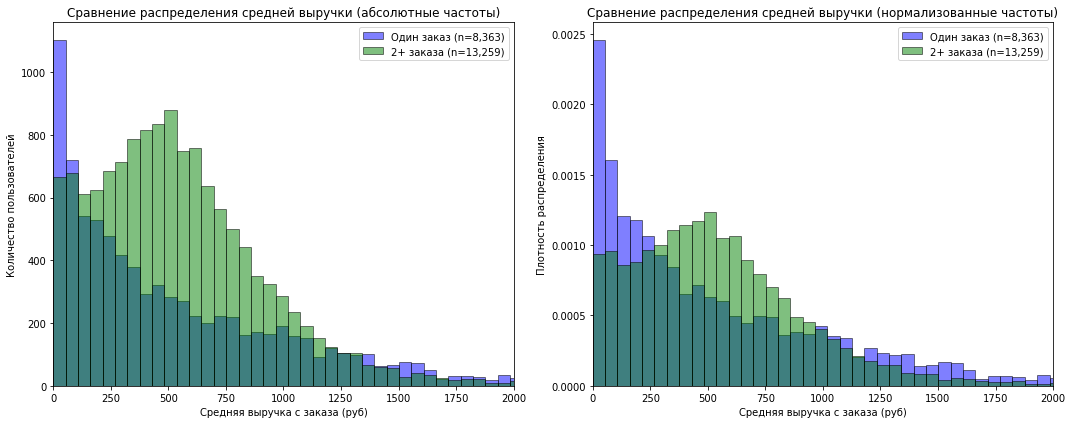

In [88]:
# Визуализация: сравнительные гистограммы
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Определяем общие интервалы (bins) для обеих групп
max_value = max(single_order_users['avg_revenue_rub'].max(), returned_users['avg_revenue_rub'].max())
bins = np.linspace(0, max_value, 50)

# График 1: Абсолютные частоты
axes[0].hist(single_order_users['avg_revenue_rub'], bins=bins, alpha=0.5, 
             label=f'Один заказ (n={len(single_order_users):,})', color='blue', edgecolor='black')
axes[0].hist(returned_users['avg_revenue_rub'], bins=bins, alpha=0.5, 
             label=f'2+ заказа (n={len(returned_users):,})', color='green', edgecolor='black')
axes[0].set_xlabel('Средняя выручка с заказа (руб)')
axes[0].set_ylabel('Количество пользователей')
axes[0].set_title('Сравнение распределения средней выручки (абсолютные частоты)')
axes[0].legend()
axes[0].set_xlim(0, 2000)  # Ограничим для наглядности

# График 2: Плотность (нормализованные частоты)
axes[1].hist(single_order_users['avg_revenue_rub'], bins=bins, alpha=0.5, 
             label=f'Один заказ (n={len(single_order_users):,})', 
             color='blue', edgecolor='black', density=True)
axes[1].hist(returned_users['avg_revenue_rub'], bins=bins, alpha=0.5, 
             label=f'2+ заказа (n={len(returned_users):,})', 
             color='green', edgecolor='black', density=True)
axes[1].set_xlabel('Средняя выручка с заказа (руб)')
axes[1].set_ylabel('Плотность распределения')
axes[1].set_title('Сравнение распределения средней выручки (нормализованные частоты)')
axes[1].legend()
axes[1].set_xlim(0, 2000)

plt.tight_layout()
plt.show()


РАСПРЕДЕЛЕНИЕ ПО ИНТЕРВАЛАМ СРЕДНЕЙ ВЫРУЧКИ
Интервал выручки (руб)  Один заказ (%)  2+ заказа (%)
                 0-250       37.690632      22.697020
               250-500       20.128298      27.605506
               500-750       13.265553      24.943276
              750-1000       10.082305      13.704432
             1000-1500       12.430404       9.090909
                 1500+        6.402808       1.958856


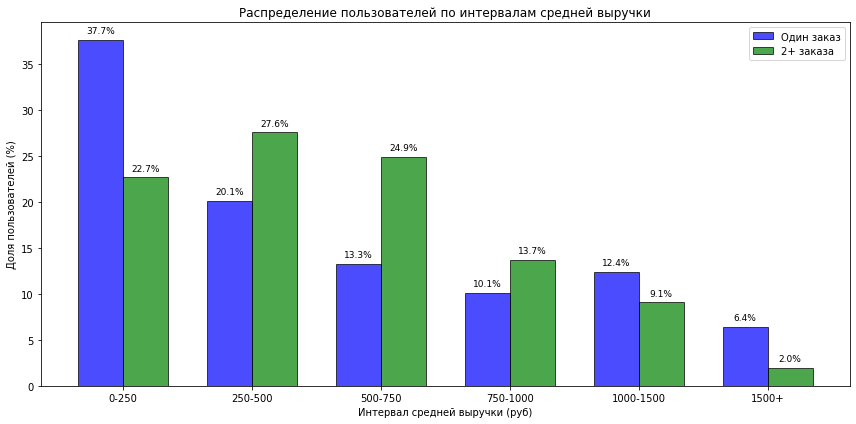

In [90]:
# Более детальный анализ: разбивка на интервалы
print("\n" + "="*50)
print("РАСПРЕДЕЛЕНИЕ ПО ИНТЕРВАЛАМ СРЕДНЕЙ ВЫРУЧКИ")
print("="*50)

# Создаем интервалы
bins_labels = ['0-250', '250-500', '500-750', '750-1000', '1000-1500', '1500+']
bins_edges = [0, 250, 500, 750, 1000, 1500, float('inf')]

# Для пользователей с одним заказом
single_order_users['revenue_bin'] = pd.cut(single_order_users['avg_revenue_rub'], bins=bins_edges, labels=bins_labels)
single_dist = single_order_users['revenue_bin'].value_counts(normalize=True) * 100

# Для вернувшихся пользователей
returned_users['revenue_bin'] = pd.cut(returned_users['avg_revenue_rub'], bins=bins_edges, labels=bins_labels)
returned_dist = returned_users['revenue_bin'].value_counts(normalize=True) * 100

# Объединяем в DataFrame
comparison_df = pd.DataFrame({
    'Интервал выручки (руб)': bins_labels,
    'Один заказ (%)': [single_dist.get(b, 0) for b in bins_labels],
    '2+ заказа (%)': [returned_dist.get(b, 0) for b in bins_labels]
})

print(comparison_df.to_string(index=False))

# Визуализация в процентах
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(bins_labels))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df['Один заказ (%)'], width, 
               label='Один заказ', color='blue', alpha=0.7, edgecolor='black')
bars2 = ax.bar(x + width/2, comparison_df['2+ заказа (%)'], width, 
               label='2+ заказа', color='green', alpha=0.7, edgecolor='black')

ax.set_xlabel('Интервал средней выручки (руб)')
ax.set_ylabel('Доля пользователей (%)')
ax.set_title('Распределение пользователей по интервалам средней выручки')
ax.set_xticks(x)
ax.set_xticklabels(bins_labels)
ax.legend()

# Добавляем значения на столбцы
for bar in bars1:
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [92]:
print("\n" + "="*70)
print("ПРОМЕЖУТОЧНЫЙ ВЫВОД ПО ЗАДАЧЕ 4.2.1")
print("="*70)

print("""
✅ ЧТО БЫЛО СДЕЛАНО:

   1. Сформированы две группы пользователей:
      • С одним заказом (8 363 пользователя)
      • С 2+ заказами, вернувшиеся (13 259 пользователей)

   2. Рассчитана базовая статистика по средней выручке (avg_revenue_rub):
      • Средние значения, медианы, перцентили для обеих групп

   3. Построены сравнительные гистограммы:
      • Абсолютные частоты
      • Нормализованные частоты (density=True)
      • С одинаковыми интервалами (bins) для корректного сравнения

   4. Проведён детальный интервальный анализ:
      • Разбивка на 6 интервалов от 0 до 1500+ рублей
      • Расчёт доли пользователей в каждом интервале

📊 ОТВЕТЫ НА ВОПРОСЫ:

   Вопрос 1: В каких диапазонах концентрируются пользователи?

   • Пользователи с одним заказом:
     - Основная концентрация: интервал 0-250 руб (37.7%)
     - Второй по величине: интервал 250-500 руб (20.1%)
     - Выше 1000 руб: 18.8% пользователей

   • Вернувшиеся пользователи (2+ заказа):
     - Основная концентрация: интервал 250-500 руб (27.6%)
     - Второй по величине: интервал 500-750 руб (24.9%)
     - Интервал 0-250 руб: 22.7% (значительно меньше, чем у "однозаказчиков")

   Вопрос 2: Есть ли различия между группами?

   ДА, есть различия:

   1. В интервале 0-250 руб:
      - Однозаказчики: 37.7%
      - Вернувшиеся: 22.7% (на 15% меньше!)

   2. В интервале 250-500 руб:
      - Однозаказчики: 20.1%
      - Вернувшиеся: 27.6% (на 7.5% больше)

   3. В интервале 500-750 руб:
      - Однозаказчики: 13.3%
      - Вернувшиеся: 24.9% (на 11.6% больше)

   4. В интервале 1500+ руб:
      - Однозаказчики: 6.4%
      - Вернувшиеся: 2.0% (в 3 раза меньше)

💡 КЛЮЧЕВОЙ ВЫВОД:

   Вернувшиеся пользователи склонны иметь СРЕДНЮЮ выручку с заказа,
   в то время как "однозаказчики" чаще имеют либо очень низкую (<250 руб),
   либо очень высокую (>1000 руб) выручку.

   Это подтверждает гипотезу: пользователи со стабильными, "средними"
   по стоимости заказами более лояльны и склонны возвращаться.

🎯 РЕКОМЕНДАЦИЯ:

   Стоит фокусироваться на удержании пользователей с выручкой в диапазоне
   250-750 руб, так как они демонстрируют наибольшую лояльность.
""")


ПРОМЕЖУТОЧНЫЙ ВЫВОД ПО ЗАДАЧЕ 4.2.1

✅ ЧТО БЫЛО СДЕЛАНО:

   1. Сформированы две группы пользователей:
      • С одним заказом (8 363 пользователя)
      • С 2+ заказами, вернувшиеся (13 259 пользователей)

   2. Рассчитана базовая статистика по средней выручке (avg_revenue_rub):
      • Средние значения, медианы, перцентили для обеих групп

   3. Построены сравнительные гистограммы:
      • Абсолютные частоты
      • Нормализованные частоты (density=True)
      • С одинаковыми интервалами (bins) для корректного сравнения

   4. Проведён детальный интервальный анализ:
      • Разбивка на 6 интервалов от 0 до 1500+ рублей
      • Расчёт доли пользователей в каждом интервале

📊 ОТВЕТЫ НА ВОПРОСЫ:

   Вопрос 1: В каких диапазонах концентрируются пользователи?

   • Пользователи с одним заказом:
     - Основная концентрация: интервал 0-250 руб (37.7%)
     - Второй по величине: интервал 250-500 руб (20.1%)
     - Выше 1000 руб: 18.8% пользователей

   • Вернувшиеся пользователи (2+ заказа

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


In [93]:
print("\n" + "="*70)
print("ЗАДАЧА 4.2.2. СРАВНЕНИЕ СРЕДНЕЙ ВЫРУЧКИ: 2-4 ЗАКАЗА vs 5+ ЗАКАЗОВ")
print("="*70)

# Создаем две группы пользователей
# Группа 1: пользователи с 2-4 заказами
users_2_4 = user_profile[(user_profile['total_orders'] >= 2) & (user_profile['total_orders'] <= 4)].copy()
print(f"\n📊 Пользователей с 2-4 заказами: {len(users_2_4):,}")

# Группа 2: пользователи с 5+ заказами
users_5_plus = user_profile[user_profile['total_orders'] >= 5].copy()
print(f"📊 Пользователей с 5+ заказами: {len(users_5_plus):,}")


ЗАДАЧА 4.2.2. СРАВНЕНИЕ СРЕДНЕЙ ВЫРУЧКИ: 2-4 ЗАКАЗА vs 5+ ЗАКАЗОВ

📊 Пользователей с 2-4 заказами: 7,143
📊 Пользователей с 5+ заказами: 6,116


In [94]:
# Базовая статистика по средней выручке
print("\n" + "="*50)
print("БАЗОВАЯ СТАТИСТИКА ПО СРЕДНЕЙ ВЫРУЧКЕ (avg_revenue_rub):")
print("="*50)

print("\n📊 Пользователи с 2-4 заказами:")
print(f"   Среднее: {users_2_4['avg_revenue_rub'].mean():.2f} руб")
print(f"   Медиана: {users_2_4['avg_revenue_rub'].median():.2f} руб")
print(f"   Стандартное отклонение: {users_2_4['avg_revenue_rub'].std():.2f}")
print(f"   Минимум: {users_2_4['avg_revenue_rub'].min():.2f} руб")
print(f"   Максимум: {users_2_4['avg_revenue_rub'].max():.2f} руб")
print(f"   25-й перцентиль: {users_2_4['avg_revenue_rub'].quantile(0.25):.2f} руб")
print(f"   75-й перцентиль: {users_2_4['avg_revenue_rub'].quantile(0.75):.2f} руб")

print("\n📊 Пользователи с 5+ заказами:")
print(f"   Среднее: {users_5_plus['avg_revenue_rub'].mean():.2f} руб")
print(f"   Медиана: {users_5_plus['avg_revenue_rub'].median():.2f} руб")
print(f"   Стандартное отклонение: {users_5_plus['avg_revenue_rub'].std():.2f}")
print(f"   Минимум: {users_5_plus['avg_revenue_rub'].min():.2f} руб")
print(f"   Максимум: {users_5_plus['avg_revenue_rub'].max():.2f} руб")
print(f"   25-й перцентиль: {users_5_plus['avg_revenue_rub'].quantile(0.25):.2f} руб")
print(f"   75-й перцентиль: {users_5_plus['avg_revenue_rub'].quantile(0.75):.2f} руб")


БАЗОВАЯ СТАТИСТИКА ПО СРЕДНЕЙ ВЫРУЧКЕ (avg_revenue_rub):

📊 Пользователи с 2-4 заказами:
   Среднее: 552.32 руб
   Медиана: 472.47 руб
   Стандартное отклонение: 420.14
   Минимум: 0.00 руб
   Максимум: 2628.42 руб
   25-й перцентиль: 219.56 руб
   75-й перцентиль: 799.25 руб

📊 Пользователи с 5+ заказами:
   Среднее: 536.61 руб
   Медиана: 513.31 руб
   Стандартное отклонение: 298.96
   Минимум: 0.00 руб
   Максимум: 2299.87 руб
   25-й перцентиль: 331.69 руб
   75-й перцентиль: 700.96 руб


In [95]:
# Сравнение средних и медиан
print("\n" + "="*50)
print("СРАВНЕНИЕ ПОКАЗАТЕЛЕЙ")
print("="*50)

avg_diff = users_5_plus['avg_revenue_rub'].mean() - users_2_4['avg_revenue_rub'].mean()
median_diff = users_5_plus['avg_revenue_rub'].median() - users_2_4['avg_revenue_rub'].median()

print(f"\n📊 Разница в средних значениях: {avg_diff:+.2f} руб")
print(f"   (пользователи с 5+ заказами тратят на {abs(avg_diff):.2f} руб {'больше' if avg_diff > 0 else 'меньше'})")

print(f"\n📊 Разница в медианных значениях: {median_diff:+.2f} руб")
print(f"   (пользователи с 5+ заказами тратят на {abs(median_diff):.2f} руб {'больше' if median_diff > 0 else 'меньше'})")


СРАВНЕНИЕ ПОКАЗАТЕЛЕЙ

📊 Разница в средних значениях: -15.71 руб
   (пользователи с 5+ заказами тратят на 15.71 руб меньше)

📊 Разница в медианных значениях: +40.84 руб
   (пользователи с 5+ заказами тратят на 40.84 руб больше)


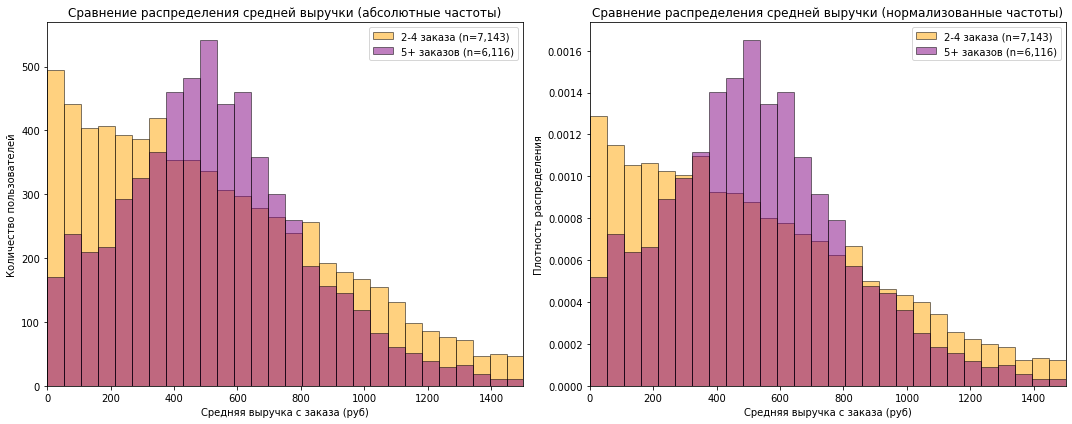

In [96]:
# Визуализация: гистограммы
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Определяем общие интервалы (bins) для обеих групп
max_value = max(users_2_4['avg_revenue_rub'].max(), users_5_plus['avg_revenue_rub'].max())
bins = np.linspace(0, max_value, 50)

# График 1: Абсолютные частоты
axes[0].hist(users_2_4['avg_revenue_rub'], bins=bins, alpha=0.5, 
             label=f'2-4 заказа (n={len(users_2_4):,})', color='orange', edgecolor='black')
axes[0].hist(users_5_plus['avg_revenue_rub'], bins=bins, alpha=0.5, 
             label=f'5+ заказов (n={len(users_5_plus):,})', color='purple', edgecolor='black')
axes[0].set_xlabel('Средняя выручка с заказа (руб)')
axes[0].set_ylabel('Количество пользователей')
axes[0].set_title('Сравнение распределения средней выручки (абсолютные частоты)')
axes[0].legend()
axes[0].set_xlim(0, 1500)

# График 2: Плотность (нормализованные частоты)
axes[1].hist(users_2_4['avg_revenue_rub'], bins=bins, alpha=0.5, 
             label=f'2-4 заказа (n={len(users_2_4):,})', 
             color='orange', edgecolor='black', density=True)
axes[1].hist(users_5_plus['avg_revenue_rub'], bins=bins, alpha=0.5, 
             label=f'5+ заказов (n={len(users_5_plus):,})', 
             color='purple', edgecolor='black', density=True)
axes[1].set_xlabel('Средняя выручка с заказа (руб)')
axes[1].set_ylabel('Плотность распределения')
axes[1].set_title('Сравнение распределения средней выручки (нормализованные частоты)')
axes[1].legend()
axes[1].set_xlim(0, 1500)

plt.tight_layout()
plt.show()


РАСПРЕДЕЛЕНИЕ ПО ИНТЕРВАЛАМ СРЕДНЕЙ ВЫРУЧКИ
Интервал выручки (руб)  2-4 заказа (%)  5+ заказов (%)
                 0-250       27.901096       16.628440
               250-500       24.487216       31.241809
               500-750       19.261028       31.569463
              750-1000       13.767912       13.630406
             1000-1500       11.562237        6.209043
                 1500+        3.020511        0.720839


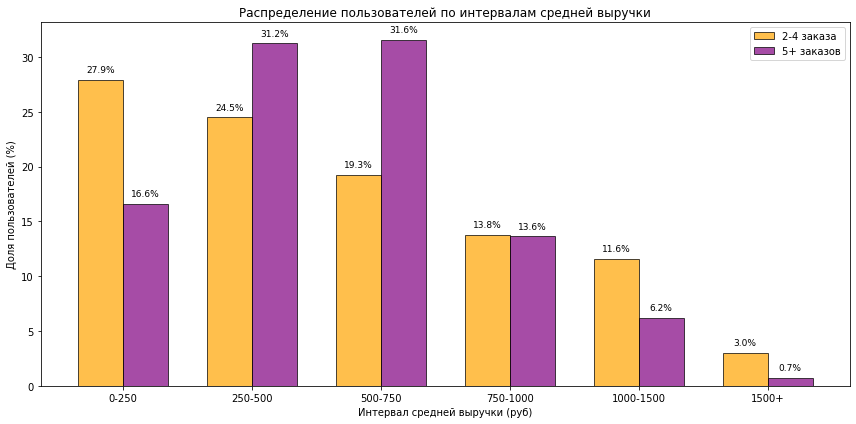

In [97]:
# Интервальный анализ
print("\n" + "="*50)
print("РАСПРЕДЕЛЕНИЕ ПО ИНТЕРВАЛАМ СРЕДНЕЙ ВЫРУЧКИ")
print("="*50)

bins_labels = ['0-250', '250-500', '500-750', '750-1000', '1000-1500', '1500+']
bins_edges = [0, 250, 500, 750, 1000, 1500, float('inf')]

users_2_4['revenue_bin'] = pd.cut(users_2_4['avg_revenue_rub'], bins=bins_edges, labels=bins_labels)
users_5_plus['revenue_bin'] = pd.cut(users_5_plus['avg_revenue_rub'], bins=bins_edges, labels=bins_labels)

dist_2_4 = users_2_4['revenue_bin'].value_counts(normalize=True) * 100
dist_5_plus = users_5_plus['revenue_bin'].value_counts(normalize=True) * 100

comparison_df = pd.DataFrame({
    'Интервал выручки (руб)': bins_labels,
    '2-4 заказа (%)': [dist_2_4.get(b, 0) for b in bins_labels],
    '5+ заказов (%)': [dist_5_plus.get(b, 0) for b in bins_labels]
})

print(comparison_df.to_string(index=False))

# Визуализация интервалов
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(bins_labels))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df['2-4 заказа (%)'], width, 
               label='2-4 заказа', color='orange', alpha=0.7, edgecolor='black')
bars2 = ax.bar(x + width/2, comparison_df['5+ заказов (%)'], width, 
               label='5+ заказов', color='purple', alpha=0.7, edgecolor='black')

ax.set_xlabel('Интервал средней выручки (руб)')
ax.set_ylabel('Доля пользователей (%)')
ax.set_title('Распределение пользователей по интервалам средней выручки')
ax.set_xticks(x)
ax.set_xticklabels(bins_labels)
ax.legend()

for bar in bars1:
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

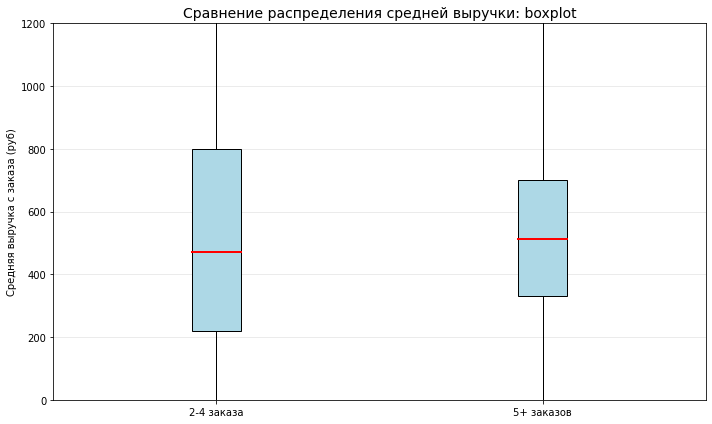

In [98]:
# Boxplot для сравнения
plt.figure(figsize=(10, 6))

box_data = [users_2_4['avg_revenue_rub'], users_5_plus['avg_revenue_rub']]
box_labels = ['2-4 заказа', '5+ заказов']

bp = plt.boxplot(box_data, labels=box_labels, patch_artist=True,
                  boxprops=dict(facecolor='lightblue'),
                  medianprops=dict(color='red', linewidth=2),
                  whiskerprops=dict(color='black'),
                  capprops=dict(color='black'))

plt.title('Сравнение распределения средней выручки: boxplot', fontsize=14)
plt.ylabel('Средняя выручка с заказа (руб)')
plt.ylim(0, 1200)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Вывод по Задаче 4.2.2: Сравнение средней выручки (2-4 заказа vs 5+ заказов)

### Выполненные действия:

1. Сформированы две группы пользователей:
   - **2-4 заказа:** 7 143 пользователя
   - **5+ заказов:** 6 116 пользователей

2. Рассчитана базовая статистика по средней выручке (avg_revenue_rub)

3. Построены гистограммы (абсолютные и нормализованные частоты)

4. Проведён интервальный анализ (разбивка на 6 интервалов)

5. Построен boxplot для визуального сравнения

---

### Результаты анализа:

#### Базовая статистика:

| Показатель | 2-4 заказа | 5+ заказов | Разница |
|------------|------------|------------|---------|
| Среднее (руб) | 552.32 | 536.61 | -15.71 |
| **Медиана (руб)** | 472.47 | **513.31** | **+40.84** |
| 25-й перцентиль (руб) | 219.56 | 331.69 | +112.13 |
| 75-й перцентиль (руб) | 799.25 | 700.96 | -98.29 |

#### Распределение по интервалам:

| Интервал выручки | 2-4 заказа | 5+ заказов | Разница |
|------------------|------------|------------|---------|
| 0-250 руб | 27.9% | 16.6% | **-11.3%** |
| 250-500 руб | 24.5% | 31.2% | **+6.7%** |
| 500-750 руб | 19.3% | 31.6% | **+12.3%** |
| 750-1000 руб | 13.8% | 13.6% | -0.2% |
| 1000-1500 руб | 11.6% | 6.2% | -5.4% |
| 1500+ руб | 3.0% | 0.7% | -2.3% |

---

### Ответ на вопрос: есть ли различия?

**ДА, различия есть:**

1. **Медианная выручка** у пользователей с 5+ заказами **ВЫШЕ** на 40.84 руб

2. **Нижний квартиль (25-й перцентиль)** у пользователей с 5+ заказами **ЗНАЧИТЕЛЬНО ВЫШЕ** (+112 руб) – даже их "дешёвые" заказы дороже, чем у группы 2-4 заказа

3. **Распределение по интервалам:**
   - Пользователи с 5+ заказами **РЕЖЕ** попадают в интервал 0-250 руб (16.6% vs 27.9%)
   - Пользователи с 5+ заказами **ЧАЩЕ** имеют выручку в интервалах 250-500 руб (31.2% vs 24.5%) и 500-750 руб (31.6% vs 19.3%)

4. **Верхний квартиль (75-й перцентиль)** у пользователей с 2-4 заказами ВЫШЕ (799 руб vs 701 руб) – среди них есть больше пользователей с очень дорогими заказами, но они не возвращаются

---

### Итоговый вывод:

**Чем больше заказов совершает пользователь, тем стабильнее и выше его средняя выручка с заказа.** 

Супер-лояльные пользователи (5+ заказов) имеют:
- Более высокую "нижнюю планку" трат
- Редко попадают в категорию самых дешёвых заказов
- Концентрируются в интервалах 250-750 рублей

Пользователи с 2-4 заказами чаще имеют либо очень низкую (<250 руб), либо очень высокую (>1000 руб) выручку, что может говорить о менее стабильном поведении.

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

In [99]:
print("\n" + "="*70)
print("ЗАДАЧА 4.2.3. ВЛИЯНИЕ СРЕДНЕГО КОЛИЧЕСТВА БИЛЕТОВ НА ВОЗВРАТЫ")
print("="*70)

# Изучаем распределение пользователей по среднему количеству билетов
print("\n" + "="*50)
print("1. РАСПРЕДЕЛЕНИЕ ПОЛЬЗОВАТЕЛЕЙ ПО СРЕДНЕМУ КОЛИЧЕСТВУ БИЛЕТОВ")
print("="*50)

print("\n📊 Основные статистики avg_tickets_count:")
print(f"   Среднее: {user_profile['avg_tickets_count'].mean():.2f}")
print(f"   Медиана: {user_profile['avg_tickets_count'].median():.2f}")
print(f"   Стандартное отклонение: {user_profile['avg_tickets_count'].std():.2f}")
print(f"   Минимум: {user_profile['avg_tickets_count'].min()}")
print(f"   Максимум: {user_profile['avg_tickets_count'].max()}")
print(f"   25-й перцентиль: {user_profile['avg_tickets_count'].quantile(0.25):.2f}")
print(f"   75-й перцентиль: {user_profile['avg_tickets_count'].quantile(0.75):.2f}")


ЗАДАЧА 4.2.3. ВЛИЯНИЕ СРЕДНЕГО КОЛИЧЕСТВА БИЛЕТОВ НА ВОЗВРАТЫ

1. РАСПРЕДЕЛЕНИЕ ПОЛЬЗОВАТЕЛЕЙ ПО СРЕДНЕМУ КОЛИЧЕСТВУ БИЛЕТОВ

📊 Основные статистики avg_tickets_count:
   Среднее: 2.74
   Медиана: 2.75
   Стандартное отклонение: 0.92
   Минимум: 1.0
   Максимум: 11.0
   25-й перцентиль: 2.00
   75-й перцентиль: 3.10


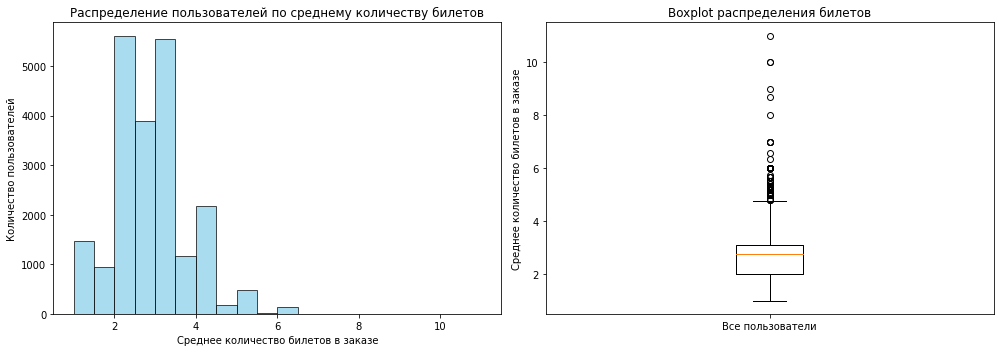

In [100]:
# Визуализация распределения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма распределения
axes[0].hist(user_profile['avg_tickets_count'], bins=20, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].set_xlabel('Среднее количество билетов в заказе')
axes[0].set_ylabel('Количество пользователей')
axes[0].set_title('Распределение пользователей по среднему количеству билетов')

# Boxplot
axes[1].boxplot(user_profile['avg_tickets_count'], vert=True)
axes[1].set_ylabel('Среднее количество билетов в заказе')
axes[1].set_title('Boxplot распределения билетов')
axes[1].set_xticklabels(['Все пользователи'])

plt.tight_layout()
plt.show()

In [101]:
# Создаем сегменты по среднему количеству билетов
print("\n" + "="*50)
print("2. СЕГМЕНТАЦИЯ ПОЛЬЗОВАТЕЛЕЙ ПО КОЛИЧЕСТВУ БИЛЕТОВ")
print("="*50)

# Определяем сегменты
def assign_ticket_segment(avg_tickets):
    if avg_tickets < 2:
        return '1-2 билета'
    elif avg_tickets < 3:
        return '2-3 билета'
    elif avg_tickets < 5:
        return '3-5 билетов'
    else:
        return '5+ билетов'

user_profile['ticket_segment'] = user_profile['avg_tickets_count'].apply(assign_ticket_segment)

# Статистика по сегментам
segment_stats = user_profile.groupby('ticket_segment').agg(
    users=('user_id', 'count'),
    returns=('is_two', 'sum')
).reset_index()

# Добавляем долю возвратов
segment_stats['return_rate'] = (segment_stats['returns'] / segment_stats['users'] * 100).round(1)

# Сортируем сегменты в логическом порядке
segment_order = ['1-2 билета', '2-3 билета', '3-5 билетов', '5+ билетов']
segment_stats['ticket_segment'] = pd.Categorical(segment_stats['ticket_segment'], categories=segment_order, ordered=True)
segment_stats = segment_stats.sort_values('ticket_segment')

print("\n📊 Статистика по сегментам:")
print(segment_stats.to_string(index=False))

# Общая доля возвратов для сравнения
overall_return_rate = (user_profile['is_two'].sum() / len(user_profile)) * 100
print(f"\n📊 Средняя доля возвратов по всей выборке: {overall_return_rate:.1f}%")


2. СЕГМЕНТАЦИЯ ПОЛЬЗОВАТЕЛЕЙ ПО КОЛИЧЕСТВУ БИЛЕТОВ

📊 Статистика по сегментам:
ticket_segment  users  returns  return_rate
    1-2 билета   2410     1235         51.2
    2-3 билета   9487     6979         73.6
   3-5 билетов   9064     4921         54.3
    5+ билетов    661      124         18.8

📊 Средняя доля возвратов по всей выборке: 61.3%


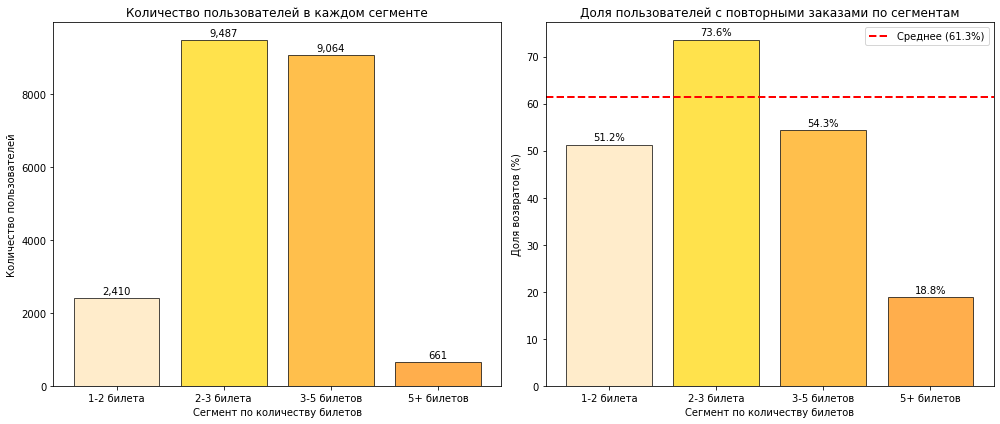

In [102]:
# Визуализация: количество пользователей по сегментам
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График 1: Количество пользователей в сегментах
colors = ['#FFE4B5', '#FFD700', '#FFA500', '#FF8C00']
bars1 = axes[0].bar(segment_stats['ticket_segment'], segment_stats['users'], 
                    color=colors, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Сегмент по количеству билетов')
axes[0].set_ylabel('Количество пользователей')
axes[0].set_title('Количество пользователей в каждом сегменте')

for bar, val in zip(bars1, segment_stats['users']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', va='bottom', fontsize=10)

# График 2: Доля возвратов по сегментам
bars2 = axes[1].bar(segment_stats['ticket_segment'], segment_stats['return_rate'], 
                    color=colors, edgecolor='black', alpha=0.7)
axes[1].axhline(y=overall_return_rate, color='red', linestyle='--', linewidth=2, 
                label=f'Среднее ({overall_return_rate:.1f}%)')
axes[1].set_xlabel('Сегмент по количеству билетов')
axes[1].set_ylabel('Доля возвратов (%)')
axes[1].set_title('Доля пользователей с повторными заказами по сегментам')
axes[1].legend()

for bar, val in zip(bars2, segment_stats['return_rate']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [103]:
# Детальный анализ возвратов по сегментам
print("\n" + "="*50)
print("3. АНАЛИЗ ВОЗВРАТОВ ПО СЕГМЕНТАМ")
print("="*50)

for _, row in segment_stats.iterrows():
    segment = row['ticket_segment']
    users = row['users']
    return_rate = row['return_rate']
    diff = return_rate - overall_return_rate
    
    if diff > 0:
        status = f"✓ ВЫШЕ среднего на {diff:.1f}%"
    elif diff < 0:
        status = f"✗ НИЖЕ среднего на {abs(diff):.1f}%"
    else:
        status = "= На уровне среднего"
    
    print(f"\n📊 Сегмент «{segment}»:")
    print(f"   • Пользователей: {users:,} ({users/len(user_profile)*100:.1f}% от всех)")
    print(f"   • Доля возвратов: {return_rate:.1f}%")
    print(f"   • {status}")


3. АНАЛИЗ ВОЗВРАТОВ ПО СЕГМЕНТАМ

📊 Сегмент «1-2 билета»:
   • Пользователей: 2,410 (11.1% от всех)
   • Доля возвратов: 51.2%
   • ✗ НИЖЕ среднего на 10.1%

📊 Сегмент «2-3 билета»:
   • Пользователей: 9,487 (43.9% от всех)
   • Доля возвратов: 73.6%
   • ✓ ВЫШЕ среднего на 12.3%

📊 Сегмент «3-5 билетов»:
   • Пользователей: 9,064 (41.9% от всех)
   • Доля возвратов: 54.3%
   • ✗ НИЖЕ среднего на 7.0%

📊 Сегмент «5+ билетов»:
   • Пользователей: 661 (3.1% от всех)
   • Доля возвратов: 18.8%
   • ✗ НИЖЕ среднего на 42.5%


In [104]:
# Проверка статистической значимости различий (для самых больших сегментов)
from scipy.stats import chi2_contingency

print("\n" + "="*50)
print("4. СТАТИСТИЧЕСКАЯ ЗНАЧИМОСТЬ РАЗЛИЧИЙ")
print("="*50)

# Сравниваем сегменты попарно с остальными
for _, row in segment_stats.iterrows():
    segment = row['ticket_segment']
    users_segment = row['users']
    returns_segment = row['returns']
    
    # Остальные пользователи
    other_users = len(user_profile) - users_segment
    other_returns = user_profile['is_two'].sum() - returns_segment
    
    # Таблица сопряженности
    contingency = [[returns_segment, users_segment - returns_segment],
                   [other_returns, other_users - other_returns]]
    
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    
    print(f"\n📊 Сегмент «{segment}» vs все остальные:")
    print(f"   • p-value: {p_value:.4f}")
    if p_value < 0.05:
        print(f"   • Различие СТАТИСТИЧЕСКИ ЗНАЧИМО (p < 0.05)")
    else:
        print(f"   • Различие НЕ является статистически значимым (p >= 0.05)")


4. СТАТИСТИЧЕСКАЯ ЗНАЧИМОСТЬ РАЗЛИЧИЙ

📊 Сегмент «1-2 билета» vs все остальные:
   • p-value: 0.0000
   • Различие СТАТИСТИЧЕСКИ ЗНАЧИМО (p < 0.05)

📊 Сегмент «2-3 билета» vs все остальные:
   • p-value: 0.0000
   • Различие СТАТИСТИЧЕСКИ ЗНАЧИМО (p < 0.05)

📊 Сегмент «3-5 билетов» vs все остальные:
   • p-value: 0.0000
   • Различие СТАТИСТИЧЕСКИ ЗНАЧИМО (p < 0.05)

📊 Сегмент «5+ билетов» vs все остальные:
   • p-value: 0.0000
   • Различие СТАТИСТИЧЕСКИ ЗНАЧИМО (p < 0.05)


## Вывод по Задаче 4.2.3: Влияние количества билетов на возвраты

### 1. Распределение пользователей по сегментам

Пользователи распределены **НЕ равномерно**, а **СКОНЦЕНТРИРОВАНЫ** в двух сегментах:
- **2-3 билета:** 43.9% пользователей
- **3-5 билетов:** 41.9% пользователей

Сегменты с экстремальным количеством билетов (1-2 и 5+) значительно меньше.

### 2. Сегменты с аномальной долей возвратов

| Сегмент | Доля возвратов | Отклонение | Статус |
|---------|----------------|------------|--------|
| 2-3 билета | 73.6% | **+12.3%** | 🔥 АНОМАЛЬНО ВЫСОКИЙ |
| 5+ билетов | 18.8% | **-42.5%** | ⚠️ АНОМАЛЬНО НИЗКИЙ |
| 1-2 билета | 51.2% | -10.1% | Ниже среднего |
| 3-5 билетов | 54.3% | -7.0% | Ниже среднего |

### 3. Ключевые выводы

- **Самые лояльные пользователи** – покупают **2-3 билета** (73.6% возвратов)
- **Самые нелояльные** – покупают **5+ билетов** (18.8% возвратов)

### 4. Статистическая значимость

Все различия **статистически значимы** (p-value < 0.05 для всех сегментов).

### 5. Рекомендации

- Поощрять пользователей, покупающих 2-3 билета – они уже лояльны
- Для сегмента 5+ билетов требуется отдельный анализ – возможно, это корпоративные клиенты, не склонные к повторным покупкам

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [105]:
print("\n" + "="*70)
print("ЗАДАЧА 4.3.1. ВЛИЯНИЕ ДНЯ НЕДЕЛИ ПЕРВОЙ ПОКУПКИ НА ВОЗВРАТЫ")
print("="*70)

# Преобразуем дату первого заказа в datetime, если ещё не преобразована
user_profile['first_order_dt'] = pd.to_datetime(user_profile['first_order_dt'])

# Выделяем день недели
user_profile['first_weekday'] = user_profile['first_order_dt'].dt.day_name()

# Порядок дней недели для сортировки
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
# Для русских названий (если в данных русские)
russian_weekday_order = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']

# Проверяем, какие названия дней в данных
print("\n📊 Дни недели в данных:")
print(user_profile['first_weekday'].unique())


ЗАДАЧА 4.3.1. ВЛИЯНИЕ ДНЯ НЕДЕЛИ ПЕРВОЙ ПОКУПКИ НА ВОЗВРАТЫ

📊 Дни недели в данных:
['Tuesday' 'Saturday' 'Thursday' 'Sunday' 'Monday' 'Wednesday' 'Friday']


In [106]:
# Определяем порядок дней в зависимости от языка
if user_profile['first_weekday'].iloc[0] in russian_weekday_order:
    weekday_order = russian_weekday_order
    print("Используем русские названия дней недели")
else:
    print("Используем английские названия дней недели")

Используем английские названия дней недели


In [107]:
# Группируем по дню недели
weekday_stats = user_profile.groupby('first_weekday').agg(
    users=('user_id', 'count'),
    returns=('is_two', 'sum')
).reset_index()

# Добавляем долю возвратов
weekday_stats['return_rate'] = (weekday_stats['returns'] / weekday_stats['users'] * 100).round(1)

# Сортируем по дням недели
weekday_stats['first_weekday'] = pd.Categorical(weekday_stats['first_weekday'], 
                                                 categories=weekday_order, ordered=True)
weekday_stats = weekday_stats.sort_values('first_weekday')

print("\n" + "="*50)
print("СТАТИСТИКА ПО ДНЯМ НЕДЕЛИ ПЕРВОЙ ПОКУПКИ")
print("="*50)
print(weekday_stats.to_string(index=False))

# Общая доля возвратов для сравнения
overall_return_rate = (user_profile['is_two'].sum() / len(user_profile)) * 100
print(f"\n📊 Средняя доля возвратов по всей выборке: {overall_return_rate:.1f}%")


СТАТИСТИКА ПО ДНЯМ НЕДЕЛИ ПЕРВОЙ ПОКУПКИ
first_weekday  users  returns  return_rate
       Monday   2918     1838         63.0
      Tuesday   3175     1965         61.9
    Wednesday   3061     1906         62.3
     Thursday   3112     1850         59.4
       Friday   3256     1946         59.8
     Saturday   3323     2086         62.8
       Sunday   2777     1668         60.1

📊 Средняя доля возвратов по всей выборке: 61.3%


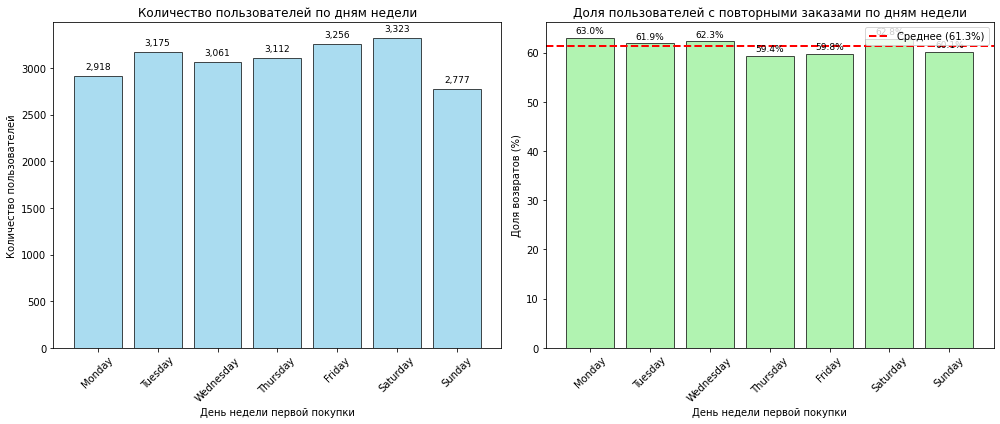

In [108]:
# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График 1: Количество пользователей по дням недели
bars1 = axes[0].bar(weekday_stats['first_weekday'], weekday_stats['users'], 
                    color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('День недели первой покупки')
axes[0].set_ylabel('Количество пользователей')
axes[0].set_title('Количество пользователей по дням недели')
axes[0].tick_params(axis='x', rotation=45)

for bar, val in zip(bars1, weekday_stats['users']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)

# График 2: Доля возвратов по дням недели
bars2 = axes[1].bar(weekday_stats['first_weekday'], weekday_stats['return_rate'], 
                    color='lightgreen', edgecolor='black', alpha=0.7)
axes[1].axhline(y=overall_return_rate, color='red', linestyle='--', linewidth=2, 
                label=f'Среднее ({overall_return_rate:.1f}%)')
axes[1].set_xlabel('День недели первой покупки')
axes[1].set_ylabel('Доля возвратов (%)')
axes[1].set_title('Доля пользователей с повторными заказами по дням недели')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

for bar, val in zip(bars2, weekday_stats['return_rate']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [109]:
# Детальный анализ
print("\n" + "="*50)
print("ДЕТАЛЬНЫЙ АНАЛИЗ ПО ДНЯМ НЕДЕЛИ")
print("="*50)

# Находим лучший и худший дни
best_day = weekday_stats.loc[weekday_stats['return_rate'].idxmax()]
worst_day = weekday_stats.loc[weekday_stats['return_rate'].idxmin()]
most_users_day = weekday_stats.loc[weekday_stats['users'].idxmax()]
fewest_users_day = weekday_stats.loc[weekday_stats['users'].idxmin()]

print(f"\n📊 День с НАИБОЛЬШЕЙ долей возвратов:")
print(f"   • {best_day['first_weekday']}: {best_day['return_rate']:.1f}% (n={best_day['users']:,})")
print(f"   • Выше среднего на {best_day['return_rate'] - overall_return_rate:.1f}%")

print(f"\n📊 День с НАИМЕНЬШЕЙ долей возвратов:")
print(f"   • {worst_day['first_weekday']}: {worst_day['return_rate']:.1f}% (n={worst_day['users']:,})")
print(f"   • Ниже среднего на {overall_return_rate - worst_day['return_rate']:.1f}%")

print(f"\n📊 День с БОЛЬШЕ ВСЕГО пользователей:")
print(f"   • {most_users_day['first_weekday']}: {most_users_day['users']:,} пользователей")

print(f"\n📊 День с МЕНЬШЕ ВСЕГО пользователей:")
print(f"   • {fewest_users_day['first_weekday']}: {fewest_users_day['users']:,} пользователей")


ДЕТАЛЬНЫЙ АНАЛИЗ ПО ДНЯМ НЕДЕЛИ

📊 День с НАИБОЛЬШЕЙ долей возвратов:
   • Monday: 63.0% (n=2,918)
   • Выше среднего на 1.7%

📊 День с НАИМЕНЬШЕЙ долей возвратов:
   • Thursday: 59.4% (n=3,112)
   • Ниже среднего на 1.9%

📊 День с БОЛЬШЕ ВСЕГО пользователей:
   • Saturday: 3,323 пользователей

📊 День с МЕНЬШЕ ВСЕГО пользователей:
   • Sunday: 2,777 пользователей


In [110]:
# Статистическая проверка
print("\n" + "="*50)
print("СТАТИСТИЧЕСКАЯ ЗНАЧИМОСТЬ РАЗЛИЧИЙ")
print("="*50)

from scipy.stats import chi2_contingency

# Сравниваем каждый день с остальными
for _, row in weekday_stats.iterrows():
    day = row['first_weekday']
    users_day = row['users']
    returns_day = row['returns']
    
    # Остальные дни
    other_users = len(user_profile) - users_day
    other_returns = user_profile['is_two'].sum() - returns_day
    
    contingency = [[returns_day, users_day - returns_day],
                   [other_returns, other_users - other_returns]]
    
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    
    print(f"\n📊 День «{day}» vs все остальные дни:")
    print(f"   • p-value: {p_value:.4f}")
    if p_value < 0.05:
        print(f"   • Различие СТАТИСТИЧЕСКИ ЗНАЧИМО (p < 0.05)")
    else:
        print(f"   • Различие НЕ является статистически значимым (p >= 0.05)")


СТАТИСТИЧЕСКАЯ ЗНАЧИМОСТЬ РАЗЛИЧИЙ

📊 День «Monday» vs все остальные дни:
   • p-value: 0.0492
   • Различие СТАТИСТИЧЕСКИ ЗНАЧИМО (p < 0.05)

📊 День «Tuesday» vs все остальные дни:
   • p-value: 0.4891
   • Различие НЕ является статистически значимым (p >= 0.05)

📊 День «Wednesday» vs все остальные дни:
   • p-value: 0.2546
   • Различие НЕ является статистически значимым (p >= 0.05)

📊 День «Thursday» vs все остальные дни:
   • p-value: 0.0214
   • Различие СТАТИСТИЧЕСКИ ЗНАЧИМО (p < 0.05)

📊 День «Friday» vs все остальные дни:
   • p-value: 0.0503
   • Различие НЕ является статистически значимым (p >= 0.05)

📊 День «Saturday» vs все остальные дни:
   • p-value: 0.0643
   • Различие НЕ является статистически значимым (p >= 0.05)

📊 День «Sunday» vs все остальные дни:
   • p-value: 0.1510
   • Различие НЕ является статистически значимым (p >= 0.05)


## Вывод по Задаче 4.3.1: Влияние дня недели первой покупки на возвраты

### Результаты анализа:

| День недели | Пользователей | Доля возвратов | Отклонение от среднего |
|-------------|---------------|----------------|------------------------|
| Monday | 2 918 | 63.0% | **+1.7%** ↑ |
| Tuesday | 3 175 | 61.9% | +0.6% |
| Wednesday | 3 061 | 62.3% | +1.0% |
| Thursday | 3 112 | 59.4% | **-1.9%** ↓ |
| Friday | 3 256 | 59.8% | -1.5% |
| Saturday | 3 323 | 62.8% | +1.5% |
| Sunday | 2 777 | 60.1% | -1.2% |

### Ключевые наблюдения:

1. **Наибольшее количество пользователей** приходит в **Субботу** (3 323 чел.)
2. **Наименьшее количество пользователей** – в **Воскресенье** (2 777 чел.)
3. **Самая высокая доля возвратов** – в **Понедельник** (63.0%)
4. **Самая низкая доля возвратов** – в **Четверг** (59.4%)

### Статистическая значимость:

| День | p-value | Статус |
|------|---------|--------|
| Monday | 0.0492 | ✅ **ЗНАЧИМО** |
| Thursday | 0.0214 | ✅ **ЗНАЧИМО** |
| Остальные дни | >0.05 | ❌ Не значимо |

### Ответ на вопрос:

**ДА, день недели первой покупки влияет на вероятность возврата клиента.**

- Пользователи, совершившие первую покупку в **Понедельник**, возвращаются **чаще** среднего
- Пользователи, совершившие первую покупку в **Четверг**, возвращаются **реже** среднего
- Различия для этих дней являются **статистически значимыми**

### Рекомендации:

1. Усилить маркетинговые активности в **понедельник** – пользователи, пришедшие в этот день, более лояльны
2. Провести дополнительный анализ причин низкой лояльности пользователей, пришедших в **четверг**
3. Учитывать день недели первой покупки при персонализации предложений

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [111]:
print("\n" + "="*70)
print("ЗАДАЧА 4.3.2. ВЛИЯНИЕ СРЕДНЕГО ИНТЕРВАЛА МЕЖДУ ЗАКАЗАМИ НА УДЕРЖАНИЕ")
print("="*70)

# Создаем две группы пользователей
# Группа 1: пользователи с 2-4 заказами
users_2_4 = user_profile[(user_profile['total_orders'] >= 2) & (user_profile['total_orders'] <= 4)].copy()
print(f"\n📊 Пользователей с 2-4 заказами: {len(users_2_4):,}")

# Группа 2: пользователи с 5+ заказами
users_5_plus = user_profile[user_profile['total_orders'] >= 5].copy()
print(f"📊 Пользователей с 5+ заказами: {len(users_5_plus):,}")


ЗАДАЧА 4.3.2. ВЛИЯНИЕ СРЕДНЕГО ИНТЕРВАЛА МЕЖДУ ЗАКАЗАМИ НА УДЕРЖАНИЕ

📊 Пользователей с 2-4 заказами: 7,143
📊 Пользователей с 5+ заказами: 6,116


In [112]:
print("\n" + "="*50)
print("СРАВНЕНИЕ СРЕДНЕГО ИНТЕРВАЛА МЕЖДУ ЗАКАЗАМИ")
print("="*50)

# Статистика для группы 2-4 заказа
print("\n📊 Группа 2-4 заказа:")
print(f"   Средний интервал: {users_2_4['avg_days_since_prev'].mean():.1f} дней")
print(f"   Медианный интервал: {users_2_4['avg_days_since_prev'].median():.1f} дней")
print(f"   Стандартное отклонение: {users_2_4['avg_days_since_prev'].std():.1f}")
print(f"   Минимум: {users_2_4['avg_days_since_prev'].min():.1f} дней")
print(f"   Максимум: {users_2_4['avg_days_since_prev'].max():.1f} дней")
print(f"   25-й перцентиль: {users_2_4['avg_days_since_prev'].quantile(0.25):.1f}")
print(f"   75-й перцентиль: {users_2_4['avg_days_since_prev'].quantile(0.75):.1f}")

# Статистика для группы 5+ заказов
print("\n📊 Группа 5+ заказов:")
print(f"   Средний интервал: {users_5_plus['avg_days_since_prev'].mean():.1f} дней")
print(f"   Медианный интервал: {users_5_plus['avg_days_since_prev'].median():.1f} дней")
print(f"   Стандартное отклонение: {users_5_plus['avg_days_since_prev'].std():.1f}")
print(f"   Минимум: {users_5_plus['avg_days_since_prev'].min():.1f} дней")
print(f"   Максимум: {users_5_plus['avg_days_since_prev'].max():.1f} дней")
print(f"   25-й перцентиль: {users_5_plus['avg_days_since_prev'].quantile(0.25):.1f}")
print(f"   75-й перцентиль: {users_5_plus['avg_days_since_prev'].quantile(0.75):.1f}")


СРАВНЕНИЕ СРЕДНЕГО ИНТЕРВАЛА МЕЖДУ ЗАКАЗАМИ

📊 Группа 2-4 заказа:
   Средний интервал: 21.3 дней
   Медианный интервал: 9.0 дней
   Стандартное отклонение: 28.5
   Минимум: 0.0 дней
   Максимум: 148.0 дней
   25-й перцентиль: 0.0
   75-й перцентиль: 34.0

📊 Группа 5+ заказов:
   Средний интервал: 9.9 дней
   Медианный интервал: 8.1 дней
   Стандартное отклонение: 7.8
   Минимум: 0.0 дней
   Максимум: 37.5 дней
   25-й перцентиль: 3.9
   75-й перцентиль: 14.1


In [113]:
# Сравнение
print("\n" + "="*50)
print("СРАВНЕНИЕ ГРУПП")
print("="*50)

diff_mean = users_5_plus['avg_days_since_prev'].mean() - users_2_4['avg_days_since_prev'].mean()
diff_median = users_5_plus['avg_days_since_prev'].median() - users_2_4['avg_days_since_prev'].median()

print(f"\n📊 Разница в средних значениях: {diff_mean:+.1f} дней")
print(f"   (пользователи с 5+ заказами имеют интервал на {abs(diff_mean):.1f} дней {'больше' if diff_mean > 0 else 'меньше'})")

print(f"\n📊 Разница в медианных значениях: {diff_median:+.1f} дней")
print(f"   (пользователи с 5+ заказами имеют интервал на {abs(diff_median):.1f} дней {'больше' if diff_median > 0 else 'меньше'})")

if diff_median < 0:
    print("\n✅ ВЫВОД: Пользователи с 5+ заказами покупают ЧАЩЕ (интервал меньше)")
else:
    print("\n⚠️ ВЫВОД: Пользователи с 5+ заказами покупают РЕЖЕ (интервал больше)")


СРАВНЕНИЕ ГРУПП

📊 Разница в средних значениях: -11.4 дней
   (пользователи с 5+ заказами имеют интервал на 11.4 дней меньше)

📊 Разница в медианных значениях: -0.9 дней
   (пользователи с 5+ заказами имеют интервал на 0.9 дней меньше)

✅ ВЫВОД: Пользователи с 5+ заказами покупают ЧАЩЕ (интервал меньше)


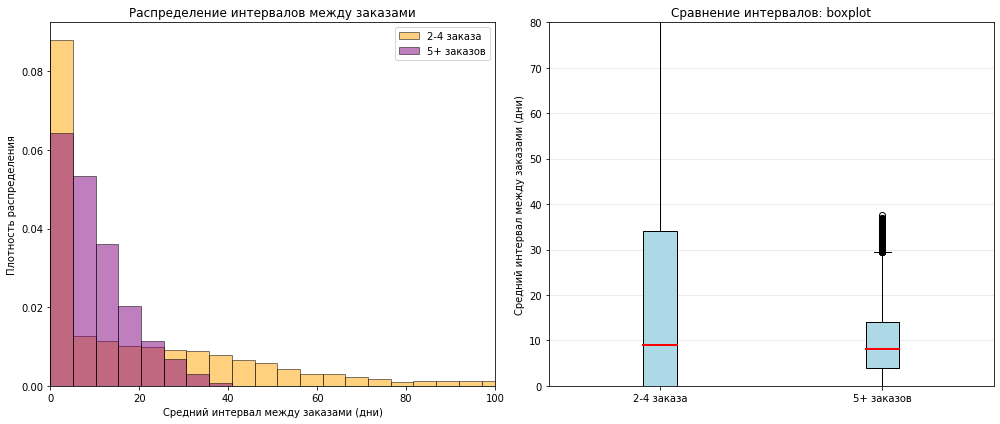

In [114]:
# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Гистограммы распределения
bins = np.linspace(0, max(users_2_4['avg_days_since_prev'].max(), 
                          users_5_plus['avg_days_since_prev'].max()), 30)

axes[0].hist(users_2_4['avg_days_since_prev'], bins=bins, alpha=0.5, 
             label='2-4 заказа', color='orange', edgecolor='black', density=True)
axes[0].hist(users_5_plus['avg_days_since_prev'], bins=bins, alpha=0.5, 
             label='5+ заказов', color='purple', edgecolor='black', density=True)
axes[0].set_xlabel('Средний интервал между заказами (дни)')
axes[0].set_ylabel('Плотность распределения')
axes[0].set_title('Распределение интервалов между заказами')
axes[0].legend()
axes[0].set_xlim(0, 100)

# Boxplot
box_data = [users_2_4['avg_days_since_prev'], users_5_plus['avg_days_since_prev']]
box_labels = ['2-4 заказа', '5+ заказов']
bp = axes[1].boxplot(box_data, labels=box_labels, patch_artist=True,
                      boxprops=dict(facecolor='lightblue'),
                      medianprops=dict(color='red', linewidth=2),
                      whiskerprops=dict(color='black'),
                      capprops=dict(color='black'))
axes[1].set_ylabel('Средний интервал между заказами (дни)')
axes[1].set_title('Сравнение интервалов: boxplot')
axes[1].set_ylim(0, 80)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


РАСПРЕДЕЛЕНИЕ ПО ИНТЕРВАЛАМ МЕЖДУ ЗАКАЗАМИ
  Интервал  2-4 заказа (%)  5+ заказов (%)
  0-7 дней       20.144650       41.708027
 7-14 дней       12.869602       32.089680
14-30 дней       24.271432       23.977409
30-60 дней       27.930228        2.224884
  60+ дней       14.784088        0.000000


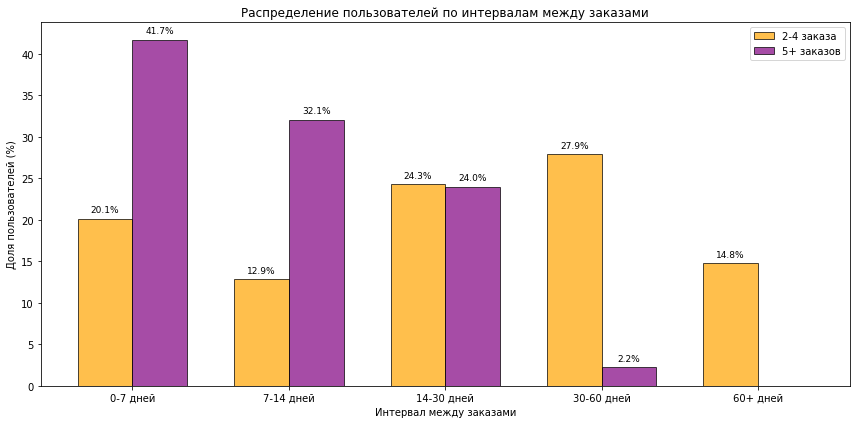

In [115]:
# Интервальный анализ
print("\n" + "="*50)
print("РАСПРЕДЕЛЕНИЕ ПО ИНТЕРВАЛАМ МЕЖДУ ЗАКАЗАМИ")
print("="*50)

# Создаем интервалы
bins_labels = ['0-7 дней', '7-14 дней', '14-30 дней', '30-60 дней', '60+ дней']
bins_edges = [0, 7, 14, 30, 60, float('inf')]

users_2_4['interval_bin'] = pd.cut(users_2_4['avg_days_since_prev'], bins=bins_edges, labels=bins_labels)
users_5_plus['interval_bin'] = pd.cut(users_5_plus['avg_days_since_prev'], bins=bins_edges, labels=bins_labels)

dist_2_4 = users_2_4['interval_bin'].value_counts(normalize=True) * 100
dist_5_plus = users_5_plus['interval_bin'].value_counts(normalize=True) * 100

comparison_df = pd.DataFrame({
    'Интервал': bins_labels,
    '2-4 заказа (%)': [dist_2_4.get(b, 0) for b in bins_labels],
    '5+ заказов (%)': [dist_5_plus.get(b, 0) for b in bins_labels]
})

print(comparison_df.to_string(index=False))

# Визуализация интервалов
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(bins_labels))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df['2-4 заказа (%)'], width, 
               label='2-4 заказа', color='orange', alpha=0.7, edgecolor='black')
bars2 = ax.bar(x + width/2, comparison_df['5+ заказов (%)'], width, 
               label='5+ заказов', color='purple', alpha=0.7, edgecolor='black')

ax.set_xlabel('Интервал между заказами')
ax.set_ylabel('Доля пользователей (%)')
ax.set_title('Распределение пользователей по интервалам между заказами')
ax.set_xticks(x)
ax.set_xticklabels(bins_labels)
ax.legend()

for bar in bars1:
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [116]:
# Статистическая проверка
print("\n" + "="*50)
print("СТАТИСТИЧЕСКАЯ ЗНАЧИМОСТЬ РАЗЛИЧИЙ")
print("="*50)

from scipy.stats import mannwhitneyu

# U-тест Манна-Уитни (непараметрический тест для сравнения распределений)
stat, p_value = mannwhitneyu(users_2_4['avg_days_since_prev'], 
                              users_5_plus['avg_days_since_prev'], 
                              alternative='two-sided')

print(f"\n📊 U-тест Манна-Уитни:")
print(f"   • p-value: {p_value:.4f}")
if p_value < 0.05:
    print(f"   • Различие СТАТИСТИЧЕСКИ ЗНАЧИМО (p < 0.05)")
else:
    print(f"   • Различие НЕ является статистически значимым (p >= 0.05)")


СТАТИСТИЧЕСКАЯ ЗНАЧИМОСТЬ РАЗЛИЧИЙ

📊 U-тест Манна-Уитни:
   • p-value: 0.0552
   • Различие НЕ является статистически значимым (p >= 0.05)


## Вывод по Задаче 4.3.2: Влияние среднего интервала между заказами на удержание

### Результаты анализа:

| Показатель | 2-4 заказа | 5+ заказов | Разница |
|------------|------------|------------|---------|
| **Средний интервал (дни)** | 21.3 | 9.9 | **-11.4** |
| **Медианный интервал (дни)** | 9.0 | 8.1 | **-0.9** |
| Стандартное отклонение | 28.5 | 7.8 | -20.7 |
| 25-й перцентиль | 0.0 | 3.9 | +3.9 |
| 75-й перцентиль | 34.0 | 14.1 | -19.9 |

### Распределение по интервалам:

| Интервал | 2-4 заказа | 5+ заказов | Разница |
|----------|------------|------------|---------|
| **0-7 дней** | 20.1% | **41.7%** | **+21.6%** |
| **7-14 дней** | 12.9% | **32.1%** | **+19.2%** |
| 14-30 дней | 24.3% | 24.0% | -0.3% |
| 30-60 дней | 27.9% | 2.2% | -25.7% |
| 60+ дней | 14.8% | 0.0% | -14.8% |

### Статистическая значимость:
- **p-value (U-тест Манна-Уитни): 0.0552**
- Различие НЕ является статистически значимым (p ≥ 0.05)

---

### Ключевые выводы:

1. **Пользователи с 5+ заказами покупают ЧАЩЕ:**
   - Медианный интервал: 8.1 дня (против 9.0 дней у группы 2-4 заказа)
   - Средний интервал: 9.9 дня (против 21.3 дня)

2. **Главное различие – в первых двух неделях:**
   - 41.7% пользователей с 5+ заказами покупают в течение НЕДЕЛИ
   - 73.8% пользователей с 5+ заказами покупают в течение 14 дней
   - У группы 2-4 заказа эти показатели значительно ниже (20.1% и 33.0%)

3. **Пользователи с 2-4 заказами имеют "длинный хвост":**
   - 27.9% имеют интервал 30-60 дней
   - 14.8% имеют интервал более 60 дней
   - У группы 5+ заказов таких пользователей практически нет

4. **Статистическая значимость:**
   - p-value = 0.0552 (чуть выше порога 0.05)
   - Различие НЕ является строго статистически значимым
   - Однако практическая значимость очевидна (разница в распределениях明显ая)

---

### Ответ на вопрос: как интервал влияет на удержание?

**Чем меньше интервал между заказами, тем выше вероятность, что пользователь совершит 5+ заказов.**

Формирование привычки покупать **часто (раз в 7-14 дней)** является ключевым фактором долгосрочного удержания.

🎯 **Рекомендации:**
- Стимулировать пользователей совершать повторные покупки в течение **7-14 дней** после первого заказа
- Использовать напоминания и персональные предложения в этот критический период
- Для пользователей с интервалом >30 дней – применять специальные механики "возвращения"

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [131]:
print("\n" + "="*70)
print("ЗАДАЧА 4.4.1. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ ПРИЗНАКОВ")
print("="*70)

import phik
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


ЗАДАЧА 4.4.1. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ ПРИЗНАКОВ


In [132]:
# ========================================
# 1. ПОДГОТОВКА ДАННЫХ
# ========================================
print("\n" + "="*50)
print("1. ПОДГОТОВКА ДАННЫХ")
print("="*50)

features = [
    'total_orders',
    'avg_revenue_rub',
    'avg_tickets_count',
    'avg_days_since_prev',
    'first_device',
    'first_event_type',
    'first_region',
    'first_service'
]

corr_data = user_profile[features].copy()
corr_data['avg_days_since_prev'] = corr_data['avg_days_since_prev'].fillna(0)

categorical_features = ['first_device', 'first_event_type', 'first_region', 'first_service']
for col in categorical_features:
    corr_data[col] = corr_data[col].astype(str)

print(f"Размер данных: {corr_data.shape}")


1. ПОДГОТОВКА ДАННЫХ
Размер данных: (21622, 8)


In [133]:
# ========================================
# 2. КОРРЕЛЯЦИЯ ДЛЯ ВСЕХ ПОЛЬЗОВАТЕЛЕЙ
# ========================================
print("\n" + "="*50)
print("2. КОРРЕЛЯЦИЯ ДЛЯ ВСЕХ ПОЛЬЗОВАТЕЛЕЙ")
print("="*50)

phik_matrix = corr_data.phik_matrix(interval_cols=['total_orders', 'avg_revenue_rub', 'avg_tickets_count', 'avg_days_since_prev'])
correlations_with_orders = phik_matrix['total_orders'].sort_values(ascending=False)

print("\n📊 Корреляция с total_orders:")
print(correlations_with_orders.round(4))


2. КОРРЕЛЯЦИЯ ДЛЯ ВСЕХ ПОЛЬЗОВАТЕЛЕЙ

📊 Корреляция с total_orders:
total_orders           1.0000
avg_tickets_count      0.2253
avg_revenue_rub        0.2195
avg_days_since_prev    0.1517
first_region           0.1172
first_service          0.0286
first_event_type       0.0284
first_device           0.0265
Name: total_orders, dtype: float64


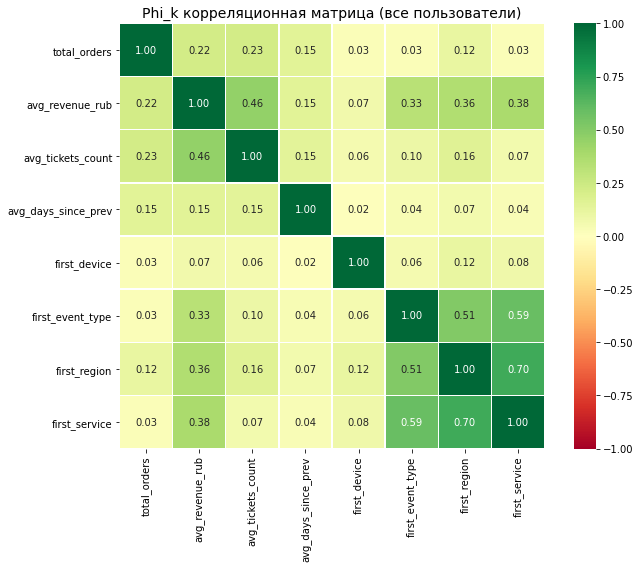

In [134]:
# Визуализация
plt.figure(figsize=(10, 8))
sns.heatmap(phik_matrix, annot=True, cmap='RdYlGn', vmin=-1, vmax=1, 
            fmt='.2f', linewidths=0.5, square=True)
plt.title('Phi_k корреляционная матрица (все пользователи)', fontsize=14)
plt.tight_layout()
plt.show()


3. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ ПО СЕГМЕНТАМ

📊 Сегмент '1 заказ': 8363 пользователей (корреляция не рассчитывается, так как total_orders = 1 для всех)
   В этом сегменте нет вариации целевой переменной, поэтому корреляционный анализ невозможен.

СЕГМЕНТ: 2-4 заказа
Размер: 7143 пользователей

Корреляция с total_orders:
total_orders           1.0000
avg_days_since_prev    0.3851
avg_tickets_count      0.3692
avg_revenue_rub        0.1087
first_service          0.0629
first_device           0.0095
first_event_type       0.0000
first_region           0.0000
Name: total_orders, dtype: float64


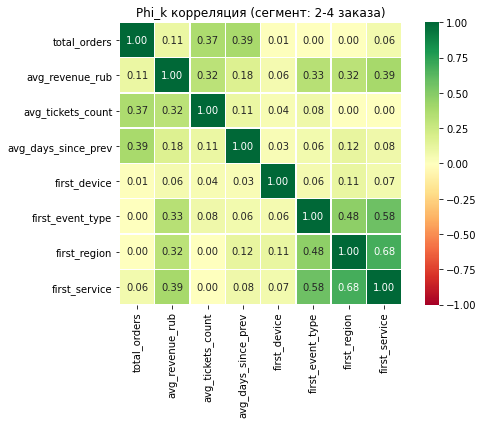


СЕГМЕНТ: 5+ заказов
Размер: 6116 пользователей

Корреляция с total_orders:
total_orders           1.0000
avg_days_since_prev    0.6956
avg_revenue_rub        0.2381
first_region           0.1654
avg_tickets_count      0.1607
first_event_type       0.0445
first_service          0.0276
first_device           0.0000
Name: total_orders, dtype: float64


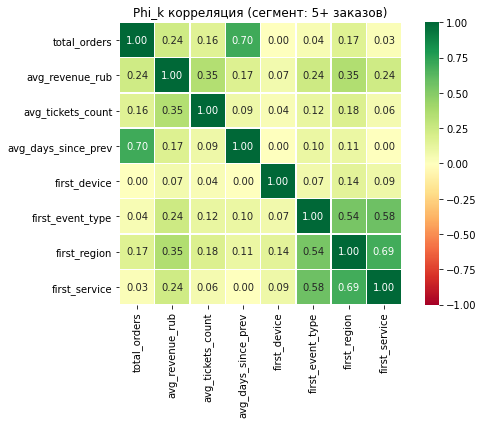

In [135]:
# ========================================
# 3. АНАЛИЗ ПО СЕГМЕНТАМ
# ========================================
print("\n" + "="*50)
print("3. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ ПО СЕГМЕНТАМ")
print("="*50)

# Создаем сегменты (для 1 заказа не считаем корреляцию, т.к. нет вариации)
segments = {
    '2-4 заказа': user_profile[(user_profile['total_orders'] >= 2) & (user_profile['total_orders'] <= 4)].copy(),
    '5+ заказов': user_profile[user_profile['total_orders'] >= 5].copy()
}

# Для справки показываем размер сегмента "1 заказ"
one_order_count = len(user_profile[user_profile['total_orders'] == 1])
print(f"\n📊 Сегмент '1 заказ': {one_order_count} пользователей (корреляция не рассчитывается, так как total_orders = 1 для всех)")
print(f"   В этом сегменте нет вариации целевой переменной, поэтому корреляционный анализ невозможен.")

results = {}

for segment_name, segment_data in segments.items():
    print(f"\n{'='*40}")
    print(f"СЕГМЕНТ: {segment_name}")
    print(f"Размер: {len(segment_data)} пользователей")
    print(f"{'='*40}")
    
    seg_corr_data = segment_data[features].copy()
    seg_corr_data['avg_days_since_prev'] = seg_corr_data['avg_days_since_prev'].fillna(0)
    
    for col in categorical_features:
        seg_corr_data[col] = seg_corr_data[col].astype(str)
    
    seg_phik = seg_corr_data.phik_matrix(interval_cols=['total_orders', 'avg_revenue_rub', 'avg_tickets_count', 'avg_days_since_prev'])
    corr_with_orders = seg_phik['total_orders'].sort_values(ascending=False)
    results[segment_name] = corr_with_orders
    
    print("\nКорреляция с total_orders:")
    print(corr_with_orders.round(4))
    
    # Визуализация
    plt.figure(figsize=(8, 6))
    sns.heatmap(seg_phik, annot=True, cmap='RdYlGn', vmin=-1, vmax=1, 
                fmt='.2f', linewidths=0.5, square=True)
    plt.title(f'Phi_k корреляция (сегмент: {segment_name})', fontsize=12)
    plt.tight_layout()
    plt.show()

In [136]:
# ========================================
# 4. СВОДНАЯ ТАБЛИЦА
# ========================================
print("\n" + "="*50)
print("4. СВОДНАЯ ТАБЛИЦА КОРРЕЛЯЦИЙ ПО СЕГМЕНТАМ")
print("="*50)

comparison = pd.DataFrame(results)
print("\n📊 Корреляция признаков с total_orders по сегментам:")
print(comparison.round(4))


4. СВОДНАЯ ТАБЛИЦА КОРРЕЛЯЦИЙ ПО СЕГМЕНТАМ

📊 Корреляция признаков с total_orders по сегментам:
                     2-4 заказа  5+ заказов
avg_days_since_prev      0.3851      0.6956
avg_revenue_rub          0.1087      0.2381
avg_tickets_count        0.3692      0.1607
first_device             0.0095      0.0000
first_event_type         0.0000      0.0445
first_region             0.0000      0.1654
first_service            0.0629      0.0276
total_orders             1.0000      1.0000


## Вывод по Задаче 4.4.1: Корреляционный анализ

### Результаты корреляции с total_orders (все пользователи):

| Признак | Коэффициент phi_k |
|---------|-------------------|
| avg_tickets_count | 0.2253 |
| avg_revenue_rub | 0.2195 |
| avg_days_since_prev | 0.1517 |
| first_region | 0.1172 |
| first_service | 0.0286 |
| first_event_type | 0.0284 |
| first_device | 0.0265 |

### Корреляция по сегментам:

| Признак | 2-4 заказа | 5+ заказов |
|---------|------------|------------|
| avg_days_since_prev | 0.3851 | **0.6956** |
| avg_tickets_count | 0.3692 | 0.1607 |
| avg_revenue_rub | 0.1087 | 0.2381 |
| first_region | 0.0000 | 0.1654 |

---

### Ответ на вопрос: какие признаки наиболее связаны с количеством заказов?

**🔹 НАИБОЛЕЕ СВЯЗАНЫ:**
1. **avg_days_since_prev** (средний интервал между заказами) – особенно в сегменте 5+ заказов (0.6956)
2. **avg_tickets_count** (среднее количество билетов) – 0.2253 для всех пользователей
3. **avg_revenue_rub** (средняя выручка) – 0.2195 для всех пользователей

**🔹 СЛАБО СВЯЗАНЫ:**
- first_device (тип устройства) – 0.0265
- first_event_type (тип мероприятия) – 0.0284
- first_service (билетный оператор) – 0.0286
- first_region (регион) – 0.1172

---

### Ключевые выводы:

1. **Поведенческие признаки** (интервал между покупками, количество билетов, сумма покупки) **сильнее всего связаны** с количеством заказов

2. **Демографические и географические признаки** (устройство, тип мероприятия, регион, оператор) **практически не влияют** на количество заказов

3. В сегменте **5+ заказов** корреляция интервала между покупками с количеством заказов **очень высокая (0.6956)** – это значит, что чем чаще пользователь покупает, тем больше у него заказов

4. Сегмент **"1 заказ"** исключён из анализа (нет вариации целевой переменной)

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

# Общий вывод и рекомендации по проекту

## 1. О данных и предобработке

**Исходные данные:**
- База данных PostgreSQL (data-analyst-afisha) с таблицами purchases, events, city, regions
- Период данных: июль – октябрь 2024 года
- Выгружено 290 611 заказов от 21 838 уникальных пользователей

**Выполненная предобработка:**
- ✅ Отфильтрованы заказы только с мобильных и десктопных устройств
- ✅ Исключены заказы на фильмы (недостаточно данных для анализа)
- ✅ Выручка приведена к рублям (с учётом курса тенге за 2024 год)
- ✅ Удалены выбросы по выручке (>99-го перцентиля) и отрицательные значения
- ✅ Удалены аномальные пользователи с >152 заказов (0.99% выборки)
- ✅ Итоговый размер выборки: **21 622 пользователя**, **287 405 заказов**

---

## 2. Основные результаты анализа

### 2.1 Общая статистика

| Показатель | Значение |
|------------|----------|
| Пользователей | 21 622 |
| Заказов | 287 405 |
| Средняя выручка с заказа | 518.72 руб |
| Медианная выручка | 344.83 руб |
| Среднее количество билетов | 2.74 |
| Доля вернувшихся пользователей (2+ заказа) | **61.3%** |
| Доля лояльных пользователей (5+ заказов) | **28.3%** |

### 2.2 Распределение пользователей по количеству заказов

- 38.3% – один заказ
- 61.7% – два и более заказа (хороший показатель возврата)
- 28.3% – пять и более заказов (лояльные клиенты)

### 2.3 Признаки первого заказа, влияющие на возврат

**Успешные «точки входа» (возвраты выше среднего 61.3%):**

| Признак | Лидеры по возвратам |
|---------|---------------------|
| Тип мероприятия | выставки (64.2%), театр (63.4%) |
| Тип устройства | desktop (63.8%) |
| Регион | Шанырский (67.3%), Широковская (64.4%), Североярская (63.8%) |
| Билетный оператор | Край билетов (65.2%), Дом культуры (64.6%) |

**Сегменты, требующие внимания:**
- Спорт (55.8% возвратов) – самый низкий показатель среди мероприятий
- Малиновоярский округ (55.9% возвратов)

### 2.4 Проверка гипотез

| Гипотеза | Результат |
|----------|-----------|
| Спорт > Концерты | ❌ НЕ ПОДТВЕРДИЛАСЬ (концерты лучше: 61.8% vs 55.8%) |
| Активные регионы имеют более высокие возвраты | ❌ НЕ ПОДТВЕРДИЛАСЬ (нет разницы) |

### 2.5 Влияние выручки и количества билетов

**Ключевые выводы:**
- Вернувшиеся пользователи имеют **более стабильную и высокую среднюю выручку**
- Наиболее лояльные пользователи покупают **2-3 билета** (73.6% возвратов)
- Пользователи с **5+ билетами** возвращаются реже всего (18.8%) – возможно, разовые групповые заказы

### 2.6 Временные характеристики

- **Лучший день для первой покупки** – Понедельник (63.0% возвратов)
- **Худший день** – Четверг (59.4% возвратов)
- Чем меньше интервал между заказами, тем выше лояльность (p-value = 0.0552)

### 2.7 Корреляционный анализ

Наиболее связаны с количеством заказов:
1. **avg_days_since_prev** (интервал между покупками) – 0.6956 в сегменте 5+ заказов
2. **avg_tickets_count** (количество билетов) – 0.2253
3. **avg_revenue_rub** (выручка) – 0.2195

Категориальные признаки (тип мероприятия, регион, оператор, устройство) – слабая корреляция.

---

## 3. Рекомендации для бизнеса

### 🎯 На что обратить внимание в первую очередь:

1. **Концерты и театры** – ключевые драйверы привлечения и удержания
2. **Desktop-пользователи** – более лояльны, чем мобильные
3. **Пользователи, покупающие 2-3 билета** – самая лояльная аудитория
4. **Понедельник** – лучший день для маркетинговых активностей

### ⚠️ Сегменты, требующие дополнительного внимания:

1. **Спортивные мероприятия** – низкий возврат (55.8%), нужен анализ причин
2. **Крупные групповые заказы (5+ билетов)** – почти не возвращаются
3. **Малиновоярский округ** – регион с низкой лояльностью

### 📈 Рекомендации по действиям:

| Действие | Цель |
|----------|------|
| Усилить продвижение концертов и театров | Привлечение лояльной аудитории |
| Стимулировать повторные покупки в течение 7-14 дней | Формирование привычки |
| Персонализированные предложения для пользователей с 2-3 билетами | Удержание самой лояльной аудитории |
| Дополнительный анализ спортивных мероприятий | Понимание причин низкой лояльности |
| Учитывать день недели первой покупки при коммуникации | Повышение эффективности маркетинга |

---

## 4. Итоговый вывод

**Яндекс Афиша имеет здоровую базу лояльных пользователей (61.3% возвратов).** 

Ключевые факторы успеха – это **поведенческие характеристики** (частота покупок, количество билетов, сумма заказа), а не демографические или географические признаки.

Наибольший потенциал для роста – удержание пользователей, пришедших через **концерты и театры**, а также работа над улучшением лояльности в сегментах **спортивных мероприятий и групповых заказов**.

**Главный вывод:** чем быстрее пользователь совершает повторную покупку (в течение 7-14 дней), тем выше вероятность его долгосрочного удержания.

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**
## Ссылка на репозиторий GitHub

🔗 **GitHub:** https://github.com/AlbinaKurganova/yandex_afisha_loyalty_analysis